# Figure 1A

In [3]:
import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
import napari
from cellpose import models
from cellpose.utils import stitch3D

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
colormap = cu.label_colormap(num_colors=1025)

# Load in example image to show slices
# name = "ExpBSc2_TL_ITD1_20x_260513_F08"
name = "20260519_CARE_TL_F11_cropped"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
# frame = 16
frame = 45
# channel = 2 #crc channel
channel = 0
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}.ims"))
print(cropped.shape)
cropped = cropped[frame, channel] 
print(cropped.shape)
# segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_segmented.tif"))[frame, :]
# print(segmentation.shape)


# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\20260511 CARE BSc\Train Low segmenter\models\low_input"
#     )
# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_high_quality_model"
#     )
model = models.CellposeModel(
        gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model"
    )

cp = []
for z in range(cropped.shape[0]):
    print(f"Running cellpose on z-slice {z}...")
    masks, _, _ = model.eval(cropped[z],
                diameter=None,
                normalize=True,
                flow_threshold=0.4,
                resample=True,
                do_3D=False,
                progress=None,
                )
    cp.append(masks)
cp = np.stack(cp, axis=0)
cp = stitch3D(cp)
tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
# print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 2)
tifffile.imwrite(os.path.join(input_directory, f"{name}_nuclogic_segmented_frame_{frame}.tif"), nuclogic.astype(np.uint16))
# nuclogic2 = stitch_3d(nuclogic, cropped)
cellpose4, _, _ = model.eval(cropped,
            diameter=None,
            normalize=True,
            flow3D_smooth=0,
            resample=True,
            do_3D=True,
            progress=None,
            z_axis=0
            )
tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_3D_frame_{frame}.tif"), cellpose4.astype(np.uint16))

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)
# viewer.add_image(cropped[:, y_half, x_half], contrast_limits=contrast, scale=scale)
# viewer.add_labels(cellpose4[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=0.9)
# viewer.add_labels(nuclogic[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=0.9)
viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_labels(cp, scale=scale, iso_gradient_mode="smooth", visible=False)
viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False, colormap=colormap)
viewer.add_labels(cellpose4, scale=scale, iso_gradient_mode="smooth", visible=False, colormap=colormap)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.grid.enabled = True
viewer.camera.zoom   = 2.5

napari.run()
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# viewer.screenshot(path=os.path.join(output_directory, "Fig_1A.png"), size=(2160, 3840), canvas_only=True, scale = 1)

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\20260519_CARE_TL_F11_cropped.ims 

(46, 2, 82, 471, 455)
Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\20260519_CARE_TL_F11_cropped.ims 

(82, 471, 455)


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 2, time 45, channel 1. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:134: UserWarning: HistogramMin value is not present for resolution 2, time 45, channel 1.
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)


Running cellpose on z-slice 0...
Running cellpose on z-slice 1...
Running cellpose on z-slice 2...
Running cellpose on z-slice 3...
Running cellpose on z-slice 4...
Running cellpose on z-slice 5...
Running cellpose on z-slice 6...
Running cellpose on z-slice 7...
Running cellpose on z-slice 8...
Running cellpose on z-slice 9...
Running cellpose on z-slice 10...
Running cellpose on z-slice 11...
Running cellpose on z-slice 12...
Running cellpose on z-slice 13...
Running cellpose on z-slice 14...
Running cellpose on z-slice 15...
Running cellpose on z-slice 16...
Running cellpose on z-slice 17...
Running cellpose on z-slice 18...
Running cellpose on z-slice 19...
Running cellpose on z-slice 20...
Running cellpose on z-slice 21...
Running cellpose on z-slice 22...
Running cellpose on z-slice 23...
Running cellpose on z-slice 24...
Running cellpose on z-slice 25...
Running cellpose on z-slice 26...
Running cellpose on z-slice 27...
Running cellpose on z-slice 28...
Running cellpose on z-sl

100%|██████████| 81/81 [00:00<00:00, 227.23it/s]


Starting 3D stitching process...
Created 9043 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 1643 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 258 breaks.
    Iteration 2: Made 105 breaks.
    Iteration 3: Made 57 breaks.
    Iteration 4: Made 11 breaks.
    Iteration 5: Made 1 breaks.
Finding touching cell pairs...
Found 2082 pairs of touching cells.
Splitted 665 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 56 small cells, and removed 252 cells without suitable neighbors.
Final stitched mask has 1767 cells.
slice(0, 235, None) slice(0, 455, None)


Figure 2

In [3]:
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)
viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
viewer.add_labels(cellpose4, scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=0.9)

slice(0, 147, None) slice(0, 290, None)


<Labels layer 'cellpose4' at 0x1d39a8e9e90>

In [56]:
# Figure 2A

import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
import scipy.ndimage

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
from utils.expand_mask import expand_mask_3d

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)

# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 3)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)

selected_mask_cp = cp == 167  # show only the mask for cell 174
selected_mask_cp = np.where(selected_mask_cp, cp, 0)  # create a masked image where only the selected cell is visible
# cropped_masked = expand_mask_3d(selected_mask_cp, dilation_size_um = 2, voxel_size=scale)  # dilate the mask to make it more visible
# cropped_masked = np.where(cropped_masked, cropped, 0)  # create a masked image where only the selected cell is visible
selected_ids_nuclogic = [166, 336]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible
target_z = np.where(selected_mask_nuclogic)[0].min() + 5
nuclogic_display = nuclogic.copy()
# replace both cell IDs only in that single slice
nuclogic_display[target_z][np.isin(nuclogic_display[target_z], [166, 336])] = 166


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (83.24123779650657, 96.3297331771258, 59.20690029145916)
viewer.camera.angles = (180, 0.6526549938471702, 0.413991687612314)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "2A_black.png"), canvas_only=True, scale = 2)

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Created 2095 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 45 breaks.
    Iteration 2: Made 20 breaks.
    Iteration 3: Made 4 breaks.
Finding touching cell pairs...
Found 314 pairs of touching cells.
Splitted 124 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 14 small cells, and removed 14 cells without suitable neighbors.
Final stitched mask has 352 cells.
slice(0, 147, None) slice(0, 290, None)


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


array([[[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       ...,

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0

In [2]:
# print the most bottom nonzero slice of the selected mask to check if the bottom part of the cell is still visible
print("Most bottom nonzero slice of the selected mask:")
print(np.where(selected_mask_nuclogic)[0].min())

Most bottom nonzero slice of the selected mask:
28


In [57]:
# Figure 2A_bottom
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "2A_bottom.png"), canvas_only=True, scale = 3)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [2]:
# Figure 2b final
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)

selected_ids_nuclogic = [166, 343]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
# selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible

viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
nuclogic2 = stitch_3d(nuclogic, cropped, breaking_threshold = 2)
viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(selected_mask_nuclogic, scale=scale, colormap={0: "", 166: "magenta", 343: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "2B_final.png"), canvas_only=True, scale = 3)

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2213 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 364 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 2.3714285714285714, 0.8465608465608466, 0.8779213238496153, 0.9096137152777779, 1.0520833333333335, 0.8469757866875796, 0.8603703703703703, 0]
  Intensity break scores: [0, 0.9282447968593451, 1.0870938958260137, 1.217307202571666, 0.996838532179134, 0.8590281509355322, 0.9518647819844411, 1.1132058805582201, 0]
  Line break scores (up): [0.         0.         1.15613345 3.80633368 2.32554158 0.21497982
 0.41075812 0.19655939 0.0941902 ]
  Line distances (up): [0.57806672 1.15613345 0.57806672 3.80633368 4.70905905 5.3968046
 6.49530828 7.79037133 9.17962459]
  Line break scores (down): [0.         1.16928662 1.79121567 0.94175093 0.13594289 

array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [2]:
# Figure synthetic data
# Code to create synthetic data for testing the stitching algorithm
from skimage.draw import ellipsoid
import napari
import os
from scipy.ndimage import zoom, gaussian_filter
import numpy as np
from scipy.ndimage import binary_dilation


def make_cell(radius_Z, radius_Y, radius_X, intensity=255):
    """Create a binary ellipsoidal cell"""
    cell = ellipsoid(radius_Z, radius_Y, radius_X)
    cell = cell.astype(np.uint16) * intensity
    return cell


def paste_cell(volume, mask, cell, position, label):
    cz, cy, cx = position.astype(int)
    dz, dy, dx = cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(volume.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(volume.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(volume.shape[2], cx + hx + 1)

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    if subcell.size == 0:
        return False

    volume[z0:z1, y0:y1, x0:x1] = np.maximum(volume[z0:z1, y0:y1, x0:x1], subcell)
    mask[z0:z1, y0:y1, x0:x1][subcell > 0] = label
    return True

from scipy.ndimage import affine_transform


def _rotation_matrix(from_vec, to_vec):
    a = from_vec / (np.linalg.norm(from_vec) + 1e-8)
    b = to_vec / (np.linalg.norm(to_vec) + 1e-8)
    v = np.cross(a, b)
    c = np.dot(a, b)
    if np.isclose(c, 1.0):
        return np.eye(3)
    if np.isclose(c, -1.0):
        # 180° flip around any perpendicular axis
        perp = np.array([1.0, 0.0, 0.0])
        if np.allclose(a, perp):
            perp = np.array([0.0, 1.0, 0.0])
        v = perp - a * np.dot(perp, a)
        v /= np.linalg.norm(v)
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        return np.eye(3) + 2 * vx @ vx
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / (np.linalg.norm(v) ** 2 + 1e-8))


def orient_cell(cell, direction_vec):
    base = np.array([1.0, 0.0, 0.0])  # +z axis in (z, y, x) ordering
    pad = int(max(cell.shape) * 0.75)
    padded = np.pad(
        cell,
        ((pad, pad), (pad, pad), (pad, pad)),
        mode="constant",
        constant_values=0,
    )
    R = _rotation_matrix(base, direction_vec)
    center = (np.array(padded.shape) - 1) / 2
    matrix = R.T
    offset = center - matrix @ center
    rotated = affine_transform(
        padded,
        matrix=matrix,
        offset=offset,
        order=1,
        mode="constant",
        cval=0,
    )
    return rotated.astype(cell.dtype)


def can_place(mask, cell, position, min_gap=4):
    dilated_cell = binary_dilation(cell > 0, iterations=min_gap)
    cz, cy, cx = position.astype(int)
    dz, dy, dx = dilated_cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(mask.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(mask.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(mask.shape[2], cx + hx + 1)

    if z0 >= z1 or y0 >= y1 or x0 >= x1:
        return False

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = dilated_cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    return np.all(mask[z0:z1, y0:y1, x0:x1][subcell > 0] == 0)

def generate_synthetic_organoid(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):
    volume = np.zeros(vol_shape, dtype=np.uint16)
    mask = np.zeros_like(volume)

    center = np.array(vol_shape) // 2

    for cell_idx in range(number_of_cells):
        # create a binomial distrubution around the radii with the arms reaching the randomness value
        rand_radius_X = int(radius_X + np.random.uniform(-randomness, randomness) * radius_X)
        rand_radius_Y = int(radius_Y + np.random.uniform(-randomness, randomness) * radius_Y)
        rand_radius_Z = int(radius_Z + np.random.uniform(-randomness, randomness) * radius_Z)
        cell = make_cell(rand_radius_Z, rand_radius_Y, rand_radius_X, intensity=255)

        placed = False
        for attempt in range(max_attempts):
            # get a random position at distance of organoid_size/2 from center
            u = np.random.uniform(-1, 1)  # cos(theta)
            phi = np.random.uniform(0, 2 * np.pi)
            theta = np.arccos(u)
            r = organoid_size / 2 # controls how far from center the cells are placed
            pos_z = int(center[0] + r * u)
            sin_theta = np.sqrt(1 - u * u)
            pos_y = int(center[1] + r * sin_theta * np.cos(phi))
            pos_x = int(center[2] + r * sin_theta * np.sin(phi))
            position = np.array([pos_z, pos_y, pos_x])

            # place the cell in the volume at the random position
            direction = center - position  # point toward organoid center
            oriented_cell = orient_cell(cell, direction)

            if not can_place(mask, oriented_cell, position):
                continue

            paste_success = paste_cell(volume, mask, oriented_cell, position, label=cell_idx + 1)
            if paste_success:
                placed = True
                print(
                    f"Cell {cell_idx+1}: position=({pos_z}, {pos_y}, {pos_x}), radii=({rand_radius_Z}, {rand_radius_Y}, {rand_radius_X})"
                )
                break

        if not placed:
            print(f"Cell {cell_idx}: skipped after {max_attempts} attempts")

    return volume, mask

seed = 1
np.random.seed(seed)
rng = np.random.default_rng(seed)

def generate_synthetic_data(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):

    synthetic_organoid, synthetic_mask = generate_synthetic_organoid(number_of_cells = number_of_cells, max_attempts = max_attempts, radius_X = radius_X, radius_Y = radius_Y, radius_Z = radius_Z, randomness = randomness, vol_shape = vol_shape, organoid_size = organoid_size)
    rescale = ((synthetic_organoid.shape[0] / (2.5 / 0.64) / synthetic_organoid.shape[0]), 1.0, 1.0)
    synthetic_organoid = zoom(synthetic_organoid, zoom=rescale, order=1)
    mask = zoom(synthetic_mask, zoom=rescale, order=0)
    output_directory = r"C:\Users\6331823\Local SSD\Fake_data"

    unique_labels = np.unique(mask)
    unique_labels = unique_labels[unique_labels > 0]

    brightness_volume = np.zeros_like(synthetic_organoid, dtype=np.float32)

    for lbl in unique_labels:
        cell_voxels = mask == lbl
        cell_mean = np.clip(rng.normal(150, 30), 50, 300)
        cell_noise = rng.normal(loc=cell_mean, scale=5, size=cell_voxels.sum())
        lo = max(150, cell_mean - 10)
        hi = min(250, cell_mean + 10)
        brightness_volume[cell_voxels] = np.clip(cell_noise, lo, hi)

    brightness_volume = brightness_volume.astype(np.uint16)


    # # create noise and PSF
    # gaussian_volume = gaussian_filter(
    #     brightness_volume.astype(np.float32), sigma=(1.6, 0.6, 0.6)
    # )
    # treat the per-cell brightness as photon counts (so Poisson SNR is meaningful)
    signal_photons = brightness_volume.astype(np.float32)

    # --- PSF (optics) : anisotropic, effective = diffraction floor + tissue scatter ---
    # em, NA, n = 0.680, 1.0, 1.33                 # 638 ex -> ~680 em far-red, water immersion
    # vox = np.array([2.5, 0.64, 0.64])            # (z, y, x) um after the zoom
    # fwhm = np.array([1.4 * n * em / NA**2, 0.51 * em / NA, 0.51 * em / NA])
    # sigma_diffraction = fwhm / 2.355 / vox       # ~sub-voxel at this sampling
    # sigma_eff = np.maximum(sigma_diffraction, [2, 0.7, 0.7])   # your values, as scatter floor
    blurred = np.empty_like(signal_photons)
    nz = signal_photons.shape[0]
    for z in range(nz):
        depth_frac = (z / nz)**0.5                      # 0 = bottom (near objective), 1 = deep
        sz = 1 + 1.6 * depth_frac              # axial blur grows with depth
        sxy = 0.5 + 0.5 * depth_frac             # lateral blur grows with depth
        # blur a small Z-window around slice z so axial smear is captured
        z0, z1 = max(0, z-4), min(nz, z+5)
        blurred[z] = gaussian_filter(signal_photons[z0:z1], sigma=(sz, sxy, sxy))[z-z0]

    # --- depth-dependent signal loss (absorption/scattering deeper in the organoid) ---
    depth = np.linspace(0.0, 1.0, blurred.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
    top, bottom = 1, 0.01
    sqrt_part = top - (top - bottom) * np.sqrt(depth)
    d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
    sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
    factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
    z_profile = (sqrt_part * factor)[:, None, None]
    photons = blurred * z_profile + 3.0          # + small autofluorescence/stray-light background

    # --- NOISE at the detector (this is the part the Gaussian was missing) ---
    detected = rng.poisson(photons).astype(np.float32)   # shot noise (signal-dependent)
    detected += rng.normal(0, 1.5, detected.shape)       # sCMOS read noise ~1-2 e-
    realistic_volume = np.clip(detected + 100.0, 0, 65535).astype(np.uint16)  # +camera offset

    return realistic_volume, mask

# print(realistic_volume.sum())
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid.tif"), realistic_volume)
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid_gt.tif"), mask.astype(np.uint16))

In [48]:
# generate modified GT with Z blur in mind
import os
import numpy as np
import tifffile
from scipy.ndimage import gaussian_filter, find_objects

synthetic_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"
n_organoids = 20
level = 1/np.e**2  # fraction of each nucleus's own blurred peak that defines its extent 


def depth_dependent_blur(volume, z_start=0, nz_total=None):
    """The synthetic PSF: axial and lateral blur that grow with depth.

    Identical to the loop used on the synthetic signal. z_start / nz_total let a
    crop be blurred with the sigmas of its global depth.
    """
    volume = volume.astype(np.float32)
    nz = volume.shape[0]
    nz_total = nz if nz_total is None else nz_total
    out = np.empty_like(volume)
    for z in range(nz):
        depth_frac = ((z_start + z) / nz_total) ** 0.5
        sz = 1 + 1.6 * depth_frac
        sxy = 0.5 + 0.5 * depth_frac
        z0, z1 = max(0, z - 4), min(nz, z + 5)
        out[z] = gaussian_filter(volume[z0:z1], sigma=(sz, sxy, sxy))[z - z0]
    return out


def depth_attenuation(nz):
    """The synthetic depth-dependent signal loss, one factor per z-slice."""
    depth = np.linspace(0.0, 1.0, nz, dtype=np.float32)
    top, bottom = 1, 0.01
    sqrt_part = top - (top - bottom) * np.sqrt(depth)
    d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15
    sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))
    factor = (1.0 + boost) - (boost + deep_drop) * sigmoid
    return sqrt_part * factor


def realistic_gt(mask, level=0.5, margin=8):
    """Ground truth passed through the same optics as the synthetic signal.

    Each nucleus is blurred with the depth-dependent PSF and attenuated with depth,
    then kept where it reaches `level` of its own peak, so per-cell brightness does
    not matter. Where two nuclei overlap, the stronger normalised response wins.
    Noise and background are left out: they are random/additive, not shape-changing.
    The blur reaches at most 4 slices axially and ~4 px laterally, so `margin`
    covers it and the crop-wise result equals blurring the full volume.
    """
    nz = mask.shape[0]
    attenuation = depth_attenuation(nz)
    out = np.zeros_like(mask)
    best = np.zeros(mask.shape, np.float32)
    for label, sl in enumerate(find_objects(mask), start=1):
        if sl is None:
            continue
        crop = tuple(
            slice(max(0, s.start - margin), min(n, s.stop + margin))
            for s, n in zip(sl, mask.shape)
        )
        cell = (mask[crop] == label).astype(np.float32)
        response = depth_dependent_blur(cell, z_start=crop[0].start, nz_total=nz)
        response *= attenuation[crop[0]][:, None, None]
        peak = response.max()
        if peak <= 0:
            continue
        score = response / peak
        region_best = best[crop]
        take = (score >= level) & (score > region_best)
        region_best[take] = score[take]
        out[crop][take] = label
    return out


tag = f"organoid_gt_l{int(round(level * 100)):03d}"   # e.g. organoid_gt_l050 for level 0.5
for i in range(n_organoids):
    src = os.path.join(synthetic_directory, f"synthetic_organoid_gt_{i}", f"synthetic_organoid_gt_{i}.tif")
    gt = tifffile.imread(src)
    new = realistic_gt(gt, level=level)

    out_dir = os.path.join(synthetic_directory, f"synthetic_{tag}_{i}")
    os.makedirs(out_dir, exist_ok=True)
    tifffile.imwrite(
        os.path.join(out_dir, f"synthetic_{tag}_{i}.tif"),
        new.astype(np.uint16),
        compression="zlib",
        compressionargs={"level": 8},
    )
    print(f"{i}: {np.count_nonzero(gt):,} -> {np.count_nonzero(new):,} voxels")


0: 248,407 -> 729,657 voxels
1: 245,220 -> 716,992 voxels
2: 247,683 -> 731,293 voxels
3: 244,204 -> 710,887 voxels
4: 249,538 -> 725,035 voxels
5: 245,286 -> 714,547 voxels
6: 249,457 -> 721,713 voxels
7: 247,174 -> 716,847 voxels
8: 251,077 -> 732,076 voxels
9: 250,618 -> 731,854 voxels
10: 249,174 -> 728,099 voxels
11: 249,539 -> 729,665 voxels
12: 249,841 -> 731,873 voxels
13: 246,926 -> 714,655 voxels
14: 246,687 -> 720,977 voxels
15: 246,418 -> 720,070 voxels
16: 249,368 -> 728,159 voxels
17: 247,490 -> 719,847 voxels
18: 244,463 -> 716,762 voxels
19: 251,033 -> 735,990 voxels


(61, 378, 490)


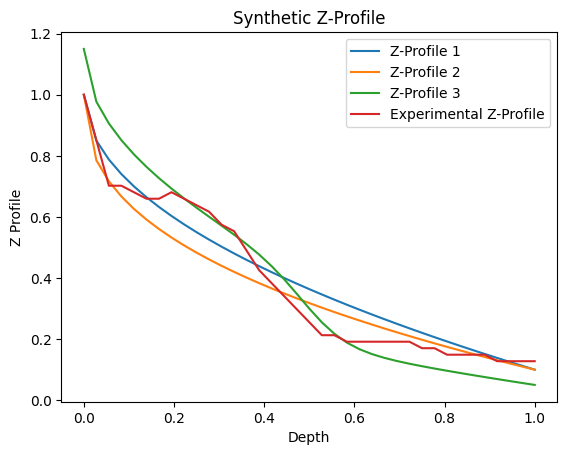

In [170]:
import matplotlib.pyplot as plt
from imaris_ims_file_reader.ims import ims
import tifffile

name = "E-133_S-16_O-1.tif"
input_directory = r"D:\Data Hussein raw\E-133_S-16_O-1"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = tifffile.imread(os.path.join(input_directory, f"{name}"))[14,:,0]
print(cropped.shape)
intensities = []
for z in range(cropped.shape[0]):
    intensities.append(np.percentile(cropped[z], 99))
# remove all values before max of intensities
intensities = intensities[np.argmax(intensities):]

depth = np.linspace(0.0, 1.0, len(intensities), dtype=np.float32)   # 0 = top, 1 = deepest
top, bottom = 1, 0.1
z_profile1 = (top - (top - bottom) * depth**0.5)[:, None, None]
z_profile2 = (top - (top - bottom) * depth**0.4)[:, None, None]

# 1) gentle sqrt falloff (your current curve)
sqrt_part = top - (top - bottom) * np.sqrt(depth)

# 2) sigmoid: slight lift before the knee, bigger drop after
d0, k, deep_drop, boost = 0.5, 20.0, 0.5, 0.15   # +boost = how much higher before the knee
sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
z_profile3 = (sqrt_part * factor)[:, None, None]

plt.plot(depth, z_profile1[:, 0, 0], label="Z-Profile 1")
plt.plot(depth, z_profile2[:, 0, 0], label="Z-Profile 2")
plt.plot(depth, z_profile3[:, 0, 0], label="Z-Profile 3")
plt.plot(depth, np.array(intensities) / np.max(intensities), label="Experimental Z-Profile")
plt.xlabel("Depth")
plt.ylabel("Z Profile")
plt.title("Synthetic Z-Profile")
plt.legend()
plt.show()

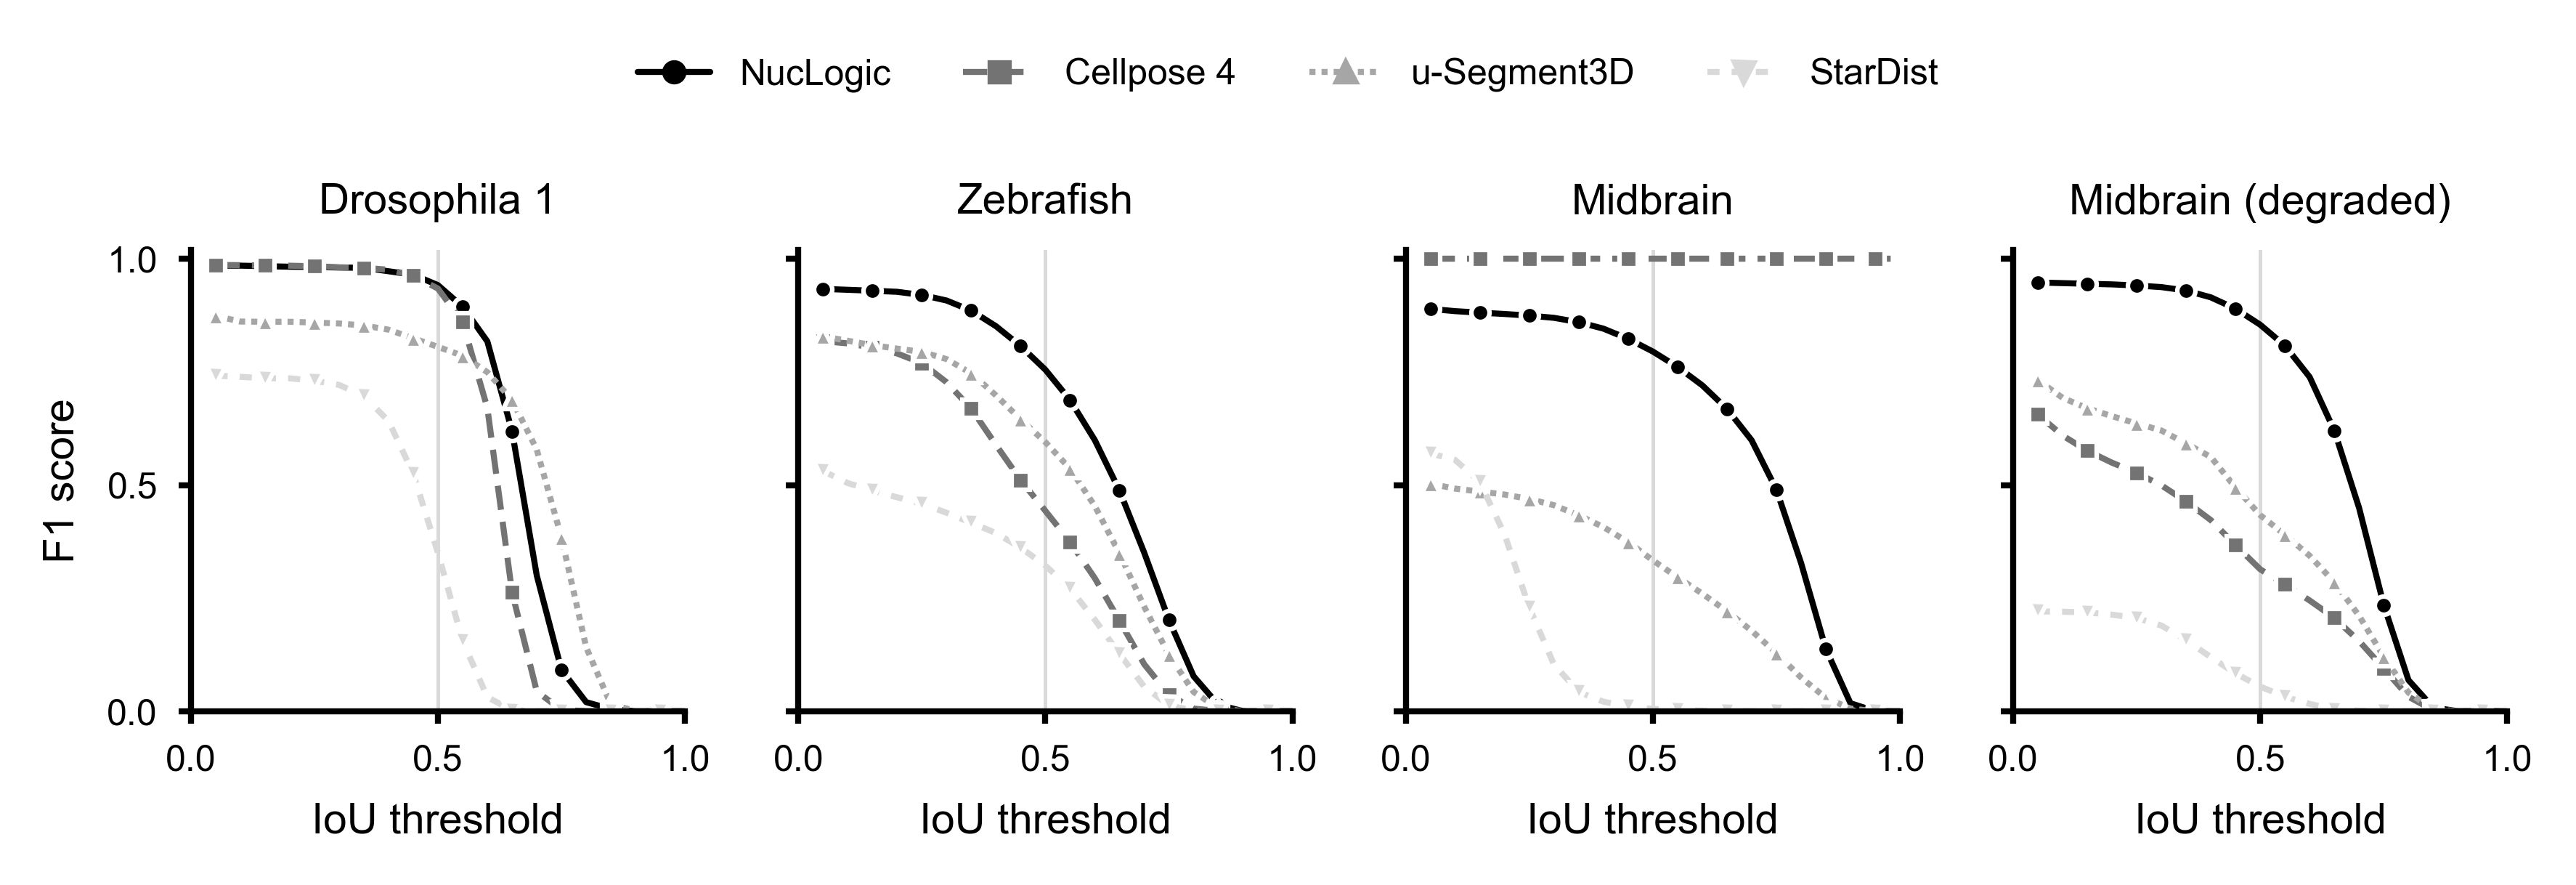

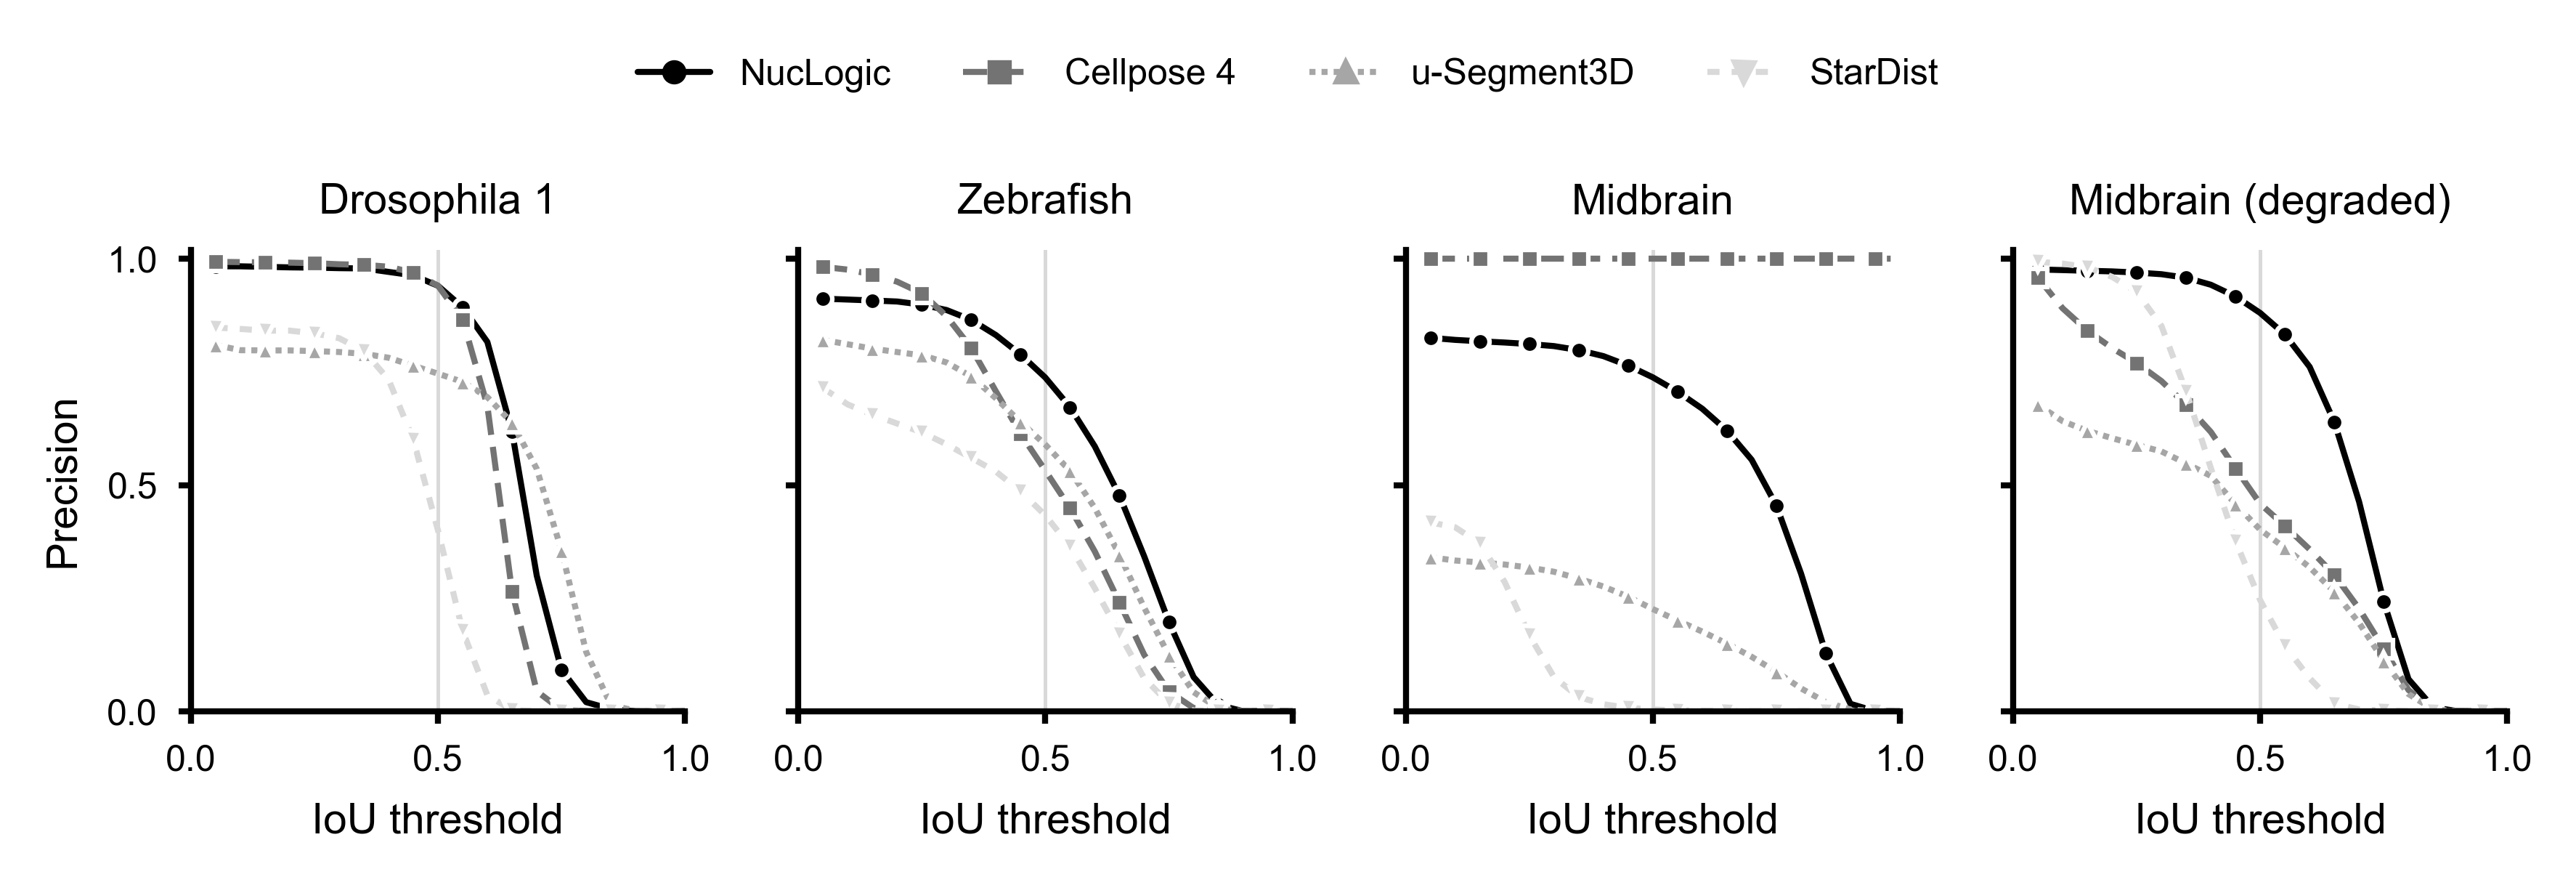

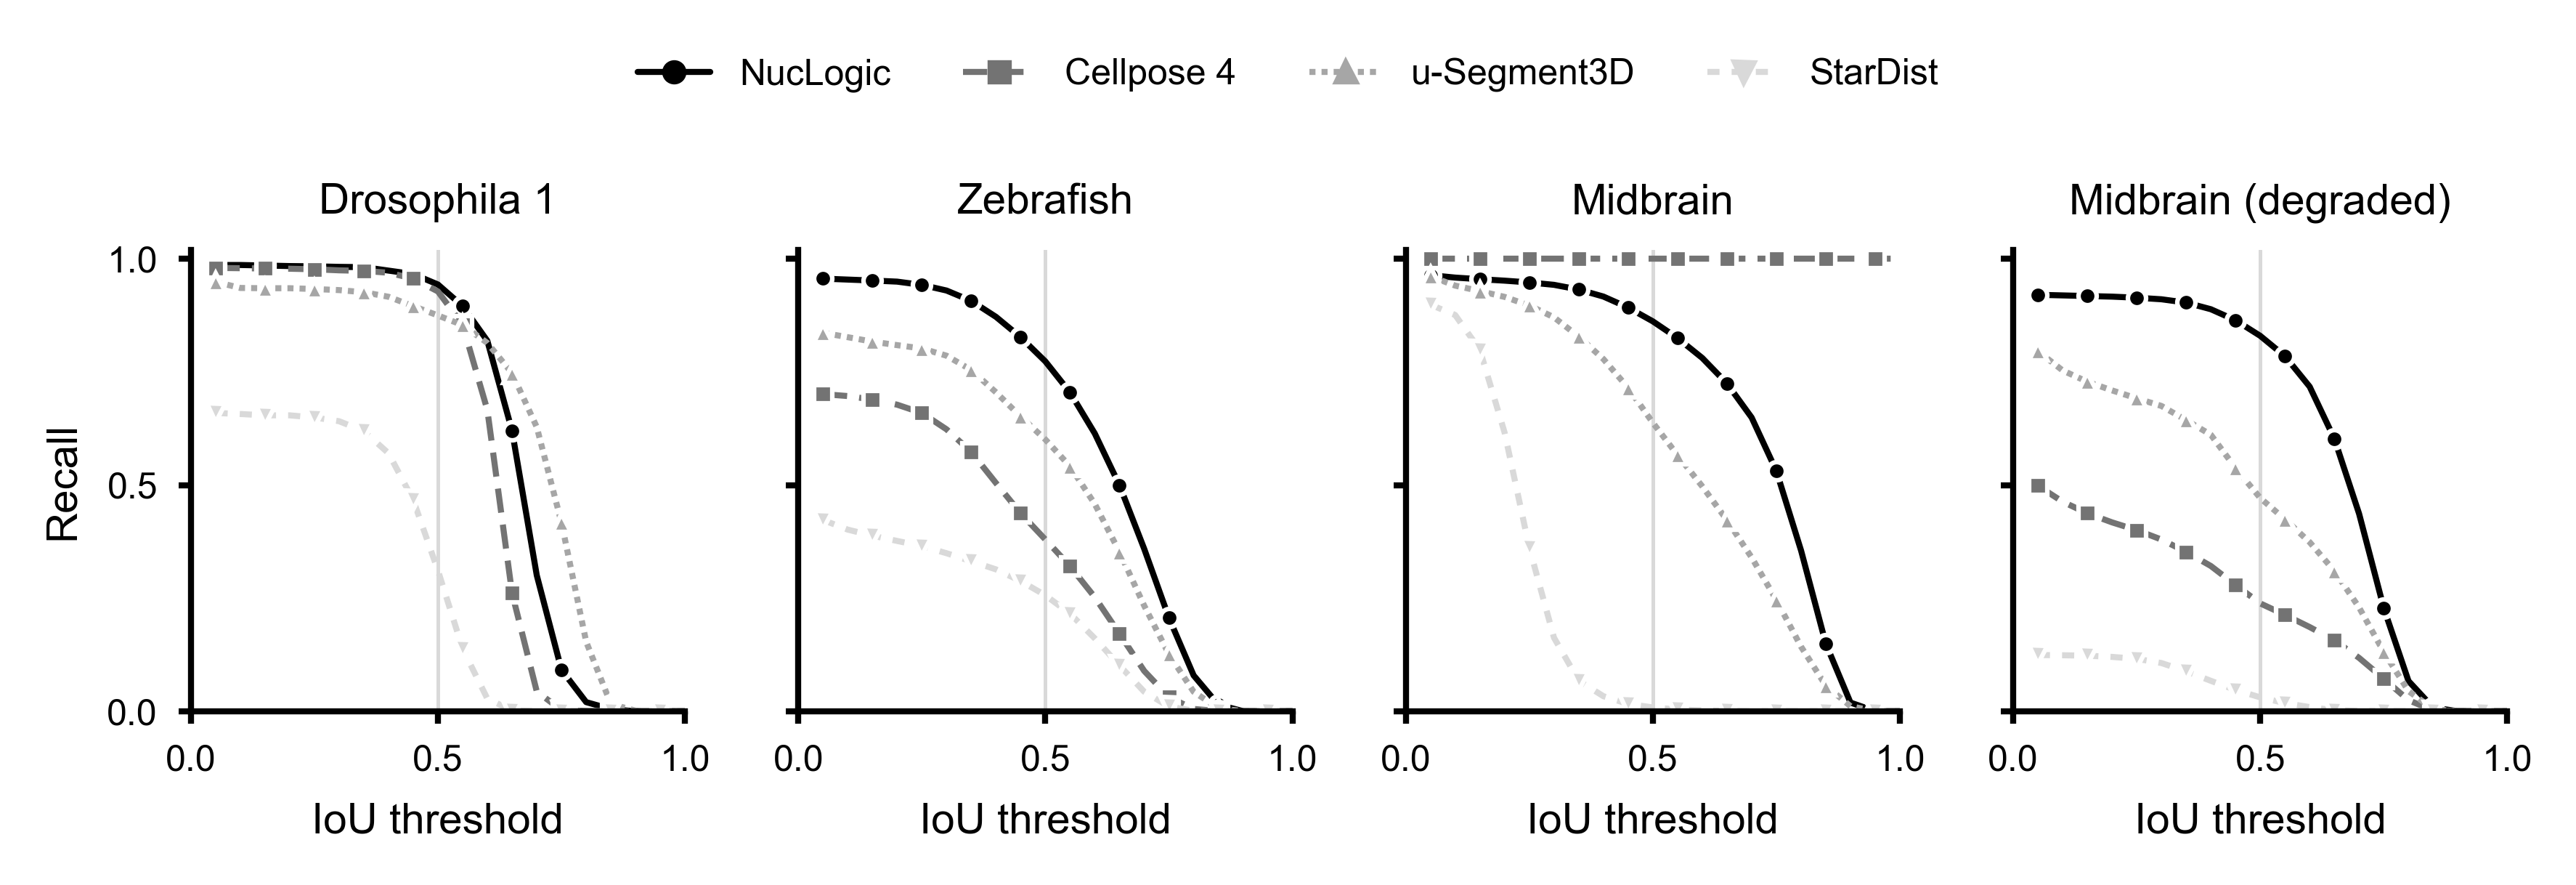

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(output_directory, "benchmark_hungarian_iou_sweep.tsv"), sep="\t")

# The three main methods, in legend order, with the display names used in the other figures.
method_names = {"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "usegment": "u-Segment3D", "stardist": "StarDist"}
methods = list(method_names.values())
results = results[results["method"].isin(method_names)].copy()
results["method"] = results["method"].map(method_names)

# Shade, line style and marker all carry identity, so the figure survives grayscale print.
method_styles = {
    "NucLogic":    {"color": "black",   "dashes": "",     "marker": "o"},
    "Cellpose 4":  {"color": "#737373", "dashes": (4, 2), "marker": "s"},
    "u-Segment3D": {"color": "#a6a6a6", "dashes": (1, 1), "marker": "^"},
    "StarDist":    {"color": "#d9d9d9", "dashes": (2, 2), "marker": "v"},
}

sample_titles = {
    "Drosophila_1": "Drosophila 1",
    # "Drosophila_2": "Drosophila 2",
    "Zebrafish_1": "Zebrafish",
    "40x WIS zstack DAPI midbrain": "Midbrain",
    "40x WIS zstack DAPI midbrain_degraded": "Midbrain (degraded)",
}
samples = list(dict.fromkeys(results["sample"]))  # keep the order the benchmark ran in
samples = [s for s in samples if s in sample_titles]  # filter out any extra samples that may have been added to the CSV

metrics = {"f1": "F1 score", "precision": "Precision", "recall": "Recall"}

sns.set_theme(context="paper", style="ticks", rc={
    "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
    "xtick.color": "black", "ytick.color": "black", "axes.edgecolor": "black",
})

# Built from the styles rather than read off a panel, so a method missing from one
# sample (e.g. a skipped file) still appears in the legend.
legend_handles = [
    Line2D([0], [0], color=s["color"], marker=s["marker"], markersize=3, linewidth=1,
           dashes=s["dashes"] or (None, None), label=m)
    for m, s in method_styles.items()
]

for metric, label in metrics.items():
    fig, axes = plt.subplots(
        1, len(samples),
        figsize=(1.5 * len(samples), 1.8),
        dpi=600,
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes[0]

    for ax, sample in zip(axes, samples):
        sns.lineplot(
            data=results[results["sample"] == sample].sort_values("iou_threshold"),
            x="iou_threshold",
            y=metric,
            hue="method",
            style="method",
            hue_order=methods,
            style_order=methods,
            palette={m: s["color"] for m, s in method_styles.items()},
            dashes={m: s["dashes"] for m, s in method_styles.items()},
            markers={m: s["marker"] for m, s in method_styles.items()},
            markersize=3,
            markevery=2,
            linewidth=1,
            errorbar=None,
            legend=False,
            ax=ax,
        )
        # Reference line at the conventional reporting threshold.
        ax.axvline(0.5, color="#d9d9d9", linewidth=0.6, zorder=0)

        ax.set_title(sample_titles.get(sample, sample), fontsize=7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([0, 0.5, 1])
        ax.set_xlabel("IoU threshold", fontsize=7)
        ax.set_ylabel("")
        ax.tick_params(labelsize=6, length=2)
        sns.despine(ax=ax)

    axes[0].set_ylabel(label, fontsize=7)
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=len(methods),
        frameon=False,
        fontsize=6,
    )
    fig.tight_layout()

    for ext in ("png", "svg"):
        fig.savefig(
            os.path.join(output_directory, f"benchmark_iou_sweep_{metric}.{ext}"),
            bbox_inches="tight",
        )
    plt.show()


In [16]:
import numpy as np
from skimage.measure import regionprops

def centroid_accuracy(gt, pred_mask):
    gt = np.asarray(gt)
    pred_mask = np.asarray(pred_mask)
    if gt.shape != pred_mask.shape:
        raise ValueError("Masks must share shape")

    gt_props = regionprops(gt)
    hit_pred_labels = set()
    predicted_labels = np.array([])
    tp = fn = merged_cells = 0

    fn_list = []
    for prop in gt_props:
        centroid = np.rint(prop.centroid).astype(int)
        centroid = tuple(np.clip(centroid, 0, np.array(gt.shape) - 1))
        pred_label = pred_mask[centroid]
        predicted_labels = np.append(predicted_labels, pred_label)
        if pred_label > 0:
            if pred_label in hit_pred_labels:
                # This predicted label has already been matched to a ground truth cell
                fn += 1
                merged_cells += 1
            else:
                tp += 1
                hit_pred_labels.add(int(pred_label))
        else:
            fn += 1
            fn_list.append(int(prop.label))


    pred_labels = set(np.unique(pred_mask))
    pred_labels.discard(0)
    fp = len(pred_labels - hit_pred_labels)
    fp_list = list(pred_labels - hit_pred_labels)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0

    gt_binary = gt > 0
    pred_binary = pred_mask > 0
    intersection = np.count_nonzero(gt_binary & pred_binary)
    dice = (
        (2 * intersection) / (gt_binary.sum() + pred_binary.sum())
        if (gt_binary.sum() + pred_binary.sum())
        else 0.0
    )

    return {
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
        "merged_cells": merged_cells,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "voxel_dice": dice,
        "tp_list": list(hit_pred_labels),
        "fp_list": fp_list,
        "fn_list": fn_list,
    }

In [30]:
import segment3D.usegment3d as uSegment3D
import segment3D.parameters as uSegment3D_params

def usegment_stitch(mask):
    """Stitch a stack of 2D XY label masks into a 3D segmentation (no XZ/YZ needed)."""
    labels_xy = np.squeeze(mask).astype(np.int32)

    p = uSegment3D_params.get_2D_to_3D_aggregation_params()
    p['indirect_method']['dtform_method']       = 'edt'   # pure numpy -> no dask cluster / no hang
    # p['postprocess_binary']['binary_fill_holes'] = True
    p['postprocess_binary']['binary_closing']    = 0     # bridge small z-gaps from signal loss
    p['gradient_descent']['do_mp']               = False  # keep gradient descent single-process too
    p['connected_component']['thresh_factor'] = 1   # default 0 -> raise it. Higher threshold on the
                                                  # point-density map => touching centroids separate
    p['connected_component']['smooth_sigma']  = 0   # default 1 -> lower it. Less density smoothing =>
                                                  # adjacent peaks stay distinct instead of fusing

    segmentation3D, (probability3D, gradients3D) = uSegment3D.aggregate_2D_to_3D_segmentation_indirect_method(
        segmentations=[labels_xy, [], []],
        img_xy_shape=labels_xy.shape,
        precomputed_binary=None,
        params=p, savefolder=None, basename=None)
    return segmentation3D

In [ ]:
from pathlib import Path
import os
import sys
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
from utils.stitch_3d import stitch_3d
import importlib
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.load_model import load_model
from utils.stitch_3d import stitch_3d
from cellpose import models
from time import time
import tifffile
import numpy as np
import pandas as pd


output_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"
model = load_model(r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model")

results = []
for i in range(20):
    # realistic_volume, gt = generate_synthetic_data(number_of_cells = 300, max_attempts = 250, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (420,420,420), organoid_size = 380)
    # print(f"generated {len(np.unique(gt)) - 1} cells in the synthetic organoid")
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"), realistic_volume, compression="zlib",
    #     compressionargs={"level": 8})
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"), gt.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    gt = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"))
    realistic_volume = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"))

    # time_start = time()
    # segmented_2d = segment(realistic_volume, model)
    # time_2d_seg_end = time() 
    # nuclogic_cellpose_time = time_2d_seg_end - time_start

    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_2d_{i}.tif"), segmented_2d.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    segmented_2d = tifffile.imread(os.path.join(output_directory, f"synthetic_segmented_2d_{i}.tif"))
    nuclogic = stitch_3d(segmented_2d, realistic_volume, breaking_threshold = 6, scale=(2.5, 0.64, 0.64))
    time_nuclogic_stitch_end = time()
    # nuclogic_stitch_time = time_nuclogic_stitch_end - time_2d_seg_end
    tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_nuclogic_{i}.tif"), nuclogic.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})

        
    # usegment_start = time()
    # usegment = usegment_stitch(segmented_2d)
    # usegment_end = time()
    # usegment_stitch_time = usegment_end - usegment_start
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_usegment_{i}.tif"), usegment.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    
    # cp4,_,_ = model.eval(
    #                 realistic_volume,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0
    #             )
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_cp4_{i}.tif"), cp4.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    # time2 = time()
    # cp4 = tifffile.imread(os.path.join(output_directory, f"synthetic_segmented_cp4_{i}.tif"))
    # np.set_printoptions(suppress=True, precision=4)
    # print(f"Real mask {len(np.unique(gt))-1},NucLogic {len(np.unique(nuclogic))-1}, Cellpose 4 {len(np.unique(cp4))-1}")
    # nuclogic_time = time_nuclogic_stitch_end - time_start
    # cp4_time = time2 - time_nuclogic_stitch_end
    # print(f"NucLogic time: {nuclogic_time:.2f}s, Cellpose 4 time: {cp4_time:.2f}s")
    nuclogic_results = centroid_accuracy(gt, nuclogic)
    # cp4_results = centroid_accuracy(gt, cp4)
    # useg_results = centroid_accuracy(gt, usegment)
    print(f"NucLogic centroid accuracy: {nuclogic_results['f1']:.4f}")
    # print(f"Cellpose 4 centroid accuracy: {cp4_results['f1']:.4f}")
    # print(f"USegment3D centroid accuracy: {useg_results['f1']:.4f}")

    print(f"Nuclogic f1 {nuclogic_results['f1']:.4f}, Cellpose 4 f1 {cp4_results['f1']:.4f}, USegment3D f1 {useg_results['f1']:.4f}")

    # results_df = pd.DataFrame(
    # {
    #     "method": ["nuclogic", "cellpose4", "usegment3d"],
    #     "f1": [nuclogic_results["f1"], cp4_results["f1"], useg_results["f1"]],
    #     "precision": [nuclogic_results["precision"], cp4_results["precision"], useg_results["precision"]],
    #     "recall": [nuclogic_results["recall"], cp4_results["recall"], useg_results["recall"]],
    #     "actual_cells": [len(np.unique(gt)) - 1, len(np.unique(gt)) - 1, len(np.unique(gt)) - 1],
    #     "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1, len(np.unique(usegment)) - 1],
    #     "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"], useg_results["true_positives"]],
    #     "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"], useg_results["false_positives"]],
    #     "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"], useg_results["false_negatives"]],
    #     "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"], useg_results["merged_cells"]],
    #     "total_time": [nuclogic_time, cp4_time, usegment_stitch_time+nuclogic_cellpose_time],
    #     "nuclogic_2d_time": [nuclogic_cellpose_time, 0, nuclogic_cellpose_time],
    #     "stitching_time": [nuclogic_stitch_time, 0, usegment_stitch_time],
    # }
    # )
    results_df = pd.DataFrame(
        {
            "method": ["nuclogic"],
            "f1": [nuclogic_results["f1"]],
            "precision": [nuclogic_results["precision"]],
            "recall": [nuclogic_results["recall"]],
            "actual_cells": [len(np.unique(gt)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1],
            "true_positives": [nuclogic_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"]],
        }
        )
    name = f"synthetic_organoid_{i}"
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

results_df.to_csv(os.path.join(output_directory, "synthetic_results_nuc.tsv"), sep="\t", index=False)


Using CUDA for processing.
loaded custom model: 2d_low_quality_model
Starting 3D stitching process...
Created 2979 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 288 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 32 breaks.
    Iteration 2: Made 15 breaks.
    Iteration 3: Made 3 breaks.
Finding touching cell pairs...
Found 97 pairs of touching cells.
Splitted 66 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 5 small cells, and removed 22 cells without suitable neighbors.
Final stitched mask has 311 cells.
NucLogic centroid accuracy: 0.9755
Nuclogic f1 0.9755, Cellpose 4 f1 0.9630, USegment3D f1 0.9282
Starting 3D stitching process...
Created 2974 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 285 cells formed.
Starting iterative breaking of cells
    Iteration 1: 

In [4]:
import ssl

_orig = ssl.SSLContext.load_default_certs
def _safe(self, purpose=ssl.Purpose.SERVER_AUTH):
    try: _orig(self, purpose)
    except ssl.SSLError: pass
ssl.SSLContext.load_default_certs = _safe

In [ ]:
import skimage.io as skio 
import pylab as plt 
import numpy as np 
import scipy.ndimage as ndimage
import skimage.segmentation as sksegmentation 
import os 
import skimage.exposure as skexposure
import segment3D.parameters as uSegment3D_params # this is useful to call default parameters, and keep track of parameter changes and for saving parameters.  
import segment3D.gpu as uSegment3D_gpu
import segment3D.usegment3d as uSegment3D
import segment3D.filters as uSegment3D_filters 
import segment3D.file_io as uSegment3D_fio

def usegment3D(image, model="nuclei", scale=(2.5, 0.64, 0.64)):
    preprocess_params = uSegment3D_params.get_preprocess_params()
    px_res = scale[1]/scale[0] 
    factor = 0.5 # to resonate with approx 30 diameter in cellpose
    preprocess_params['factor'] = factor # istropic scaling factor 
    preprocess_params['voxel_res'] = [1./px_res, 1., 1.] # scale up 
    img_preprocess = uSegment3D.preprocess_imgs(image, params=preprocess_params)
    img_preprocess = np.squeeze(img_preprocess)
    # img_preprocess = ndimage.median_filter(img_preprocess, size=3)

    cellpose_segment_params = uSegment3D_params.get_Cellpose_autotune_params()
    cellpose_segment_params['cellpose_modelname'] = model 
        
    """
    If the below auto-inferred diameter is picking up noise and being too small, we can increase the default ksize, alternatively we can add median_filter.
    """
    cellpose_segment_params['ksize'] = 15
    cellpose_segment_params['best_diam'] = 20

    # invert model
    cellpose_segment_params['model_invert'] = False # new cellpose seems to prefer no model inversion? for membrane markers.
    cellpose_segment_params['use_edge'] = True # for autofinding best slice. 
    print(f"GPU: {cellpose_segment_params['gpu']}")
    if len(img_preprocess.shape) == 3:
        # this expects a multichannel input image and in the format (M,N,L,channels) i.e. channels last.
        img_preprocess = img_preprocess[...,None] # we generate an artificial channel
    #### 1. running for xy orientation. If the savefolder and basename are specified, the output will be saved as .pkl and .mat files 
    img_segment_2D_xy_diams, img_segment_3D_xy_probs, img_segment_2D_xy_flows, img_segment_2D_xy_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
                                                                                                                                            view='xy', 
                                                                                                                                            params=cellpose_segment_params, 
                                                                                                                                            basename=None, savefolder=None)
    # #### 2. running for xz orientation 
    # img_segment_2D_xz_diams, img_segment_3D_xz_probs, img_segment_2D_xz_flows, img_segment_2D_xz_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
    #                                                                                                                                         view='xz', 
    #                                                                                                                                         params=cellpose_segment_params, 
    #                                                                                                                                         basename=None, savefolder=None)

    # #### 3. running for yz orientation 
    # img_segment_2D_yz_diams, img_segment_3D_yz_probs, img_segment_2D_yz_flows, img_segment_2D_yz_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
    #                                                                                                                                         view='yz', 
    #                                                                                                                                         params=cellpose_segment_params, 
    #                                                                                                                                         basename=None, savefolder=None)



    # =============================================================================
    #     3. We can now use the predicted probabilies and flows directly to aggregate a 3D consensus segmentation (Direct Method)
    # =============================================================================

    aggregation_params = uSegment3D_params.get_2D_to_3D_aggregation_params()

    # make sure that we say we are using Cellpose probability predictions which needs to be normalized. If not using Cellpose predicted masks, then set this to be False. We assume this has been appropriately normalized to 0-1
    aggregation_params['combine_cell_probs']['cellpose_prob_mask'] = True 

    # add some temporal decay 
    aggregation_params['gradient_descent']['gradient_decay'] = 0.05 # increase this to alleviate splitting of elongated/branching structures with cellpose gradients or decrease towards 0.0 to encourage splitting. 
    aggregation_params['postprocess_binary']['binary_fill_holes'] = True # we want the base segmentations to have holes filled


    # probs and gradients should be supplied in the order of [xy, xz, yz]. if one or more do not exist use [] e.g. [xy, [], []]
    segmentation3D, (probability3D, gradients3D) = uSegment3D.aggregate_2D_to_3D_segmentation_direct_method(probs=[img_segment_3D_xy_probs,
                                                                                                                    [],
                                                                                                                    []], 
                                                                                                            gradients=[img_segment_2D_xy_flows,
                                                                                                                        [],
                                                                                                                        []], 
                                                                                                            params=aggregation_params,
                                                                                                            savefolder=None,
                                                                                                            basename=None)
    
    postprocess_segment_params = uSegment3D_params.get_postprocess_segmentation_params()
    postprocess_segment_params['flow_consistency']['flow_threshold'] = 0.85 # we can adjust the threshold if needed
    segmentation3D_filt, flow_consistency_intermediates = uSegment3D.postprocess_3D_cell_segmentation(segmentation3D,
                                                                                                      aggregation_params=aggregation_params,
                                                                                                      postprocess_params=postprocess_segment_params,
                                                                                                      cell_gradients=gradients3D,
                                                                                                      savefolder=None,
                                                                                                      basename=None)
    return segmentation3D_filt


In [3]:
# try stardist

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize

output_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for i in range(20):
    # realistic_volume, gt = generate_synthetic_data(number_of_cells = 300, max_attempts = 150, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (420,420,420), organoid_size = 380)
    realistic_volume = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"))
    gt = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"))
    time_start = time()
    img = normalize(realistic_volume, 1,99.8, axis=axis_norm)
    stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    time_end = time()
    star_time = time_end - time_start
    tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_stardist_{i}.tif"), stardist.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results['f1']:.4f}")

    print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

    results_df = pd.DataFrame(
    {
        "method": ["stardist"],
        "f1": [stardist_results["f1"]],
        "precision": [stardist_results["precision"]],
        "recall": [stardist_results["recall"]],
        "actual_cells": [len(np.unique(gt)) - 1],
        "predicted_cells": [len(np.unique(stardist)) - 1],
        "true_positives": [stardist_results["true_positives"]],
        "false_positives": [stardist_results["false_positives"]],
        "false_negatives": [stardist_results["false_negatives"]],
        "merged_cells": [stardist_results["merged_cells"]],
        "total_time": [star_time],
        "nuclogic_2d_time": [0],
        "stitching_time": [0],
    }
    )
    name = f"synthetic_organoid_{i}"
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.


100%|██████████| 32/32 [00:09<00:00,  3.41it/s]


stardist time: 11.08s
StarDist3D centroid accuracy: 0.5795
StarDist3D f1 0.5795


100%|██████████| 32/32 [00:08<00:00,  3.64it/s]


stardist time: 9.90s
StarDist3D centroid accuracy: 0.5536
StarDist3D f1 0.5536


...

stardist time: 10.10s
StarDist3D centroid accuracy: 0.5471
StarDist3D f1 0.5471


100%|██████████| 32/32 [00:09<00:00,  3.55it/s]


stardist time: 10.21s
StarDist3D centroid accuracy: 0.5751
StarDist3D f1 0.5751


100%|██████████| 32/32 [00:09<00:00,  3.53it/s]


stardist time: 10.19s
StarDist3D centroid accuracy: 0.5758
StarDist3D f1 0.5758


<>:104: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:104: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\6331823\AppData\Local\Temp\ipykernel_32908\1774222272.py:104: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if text is not "ns":


Removing y-tick labels for axis 1
Removing y-tick labels for axis 2


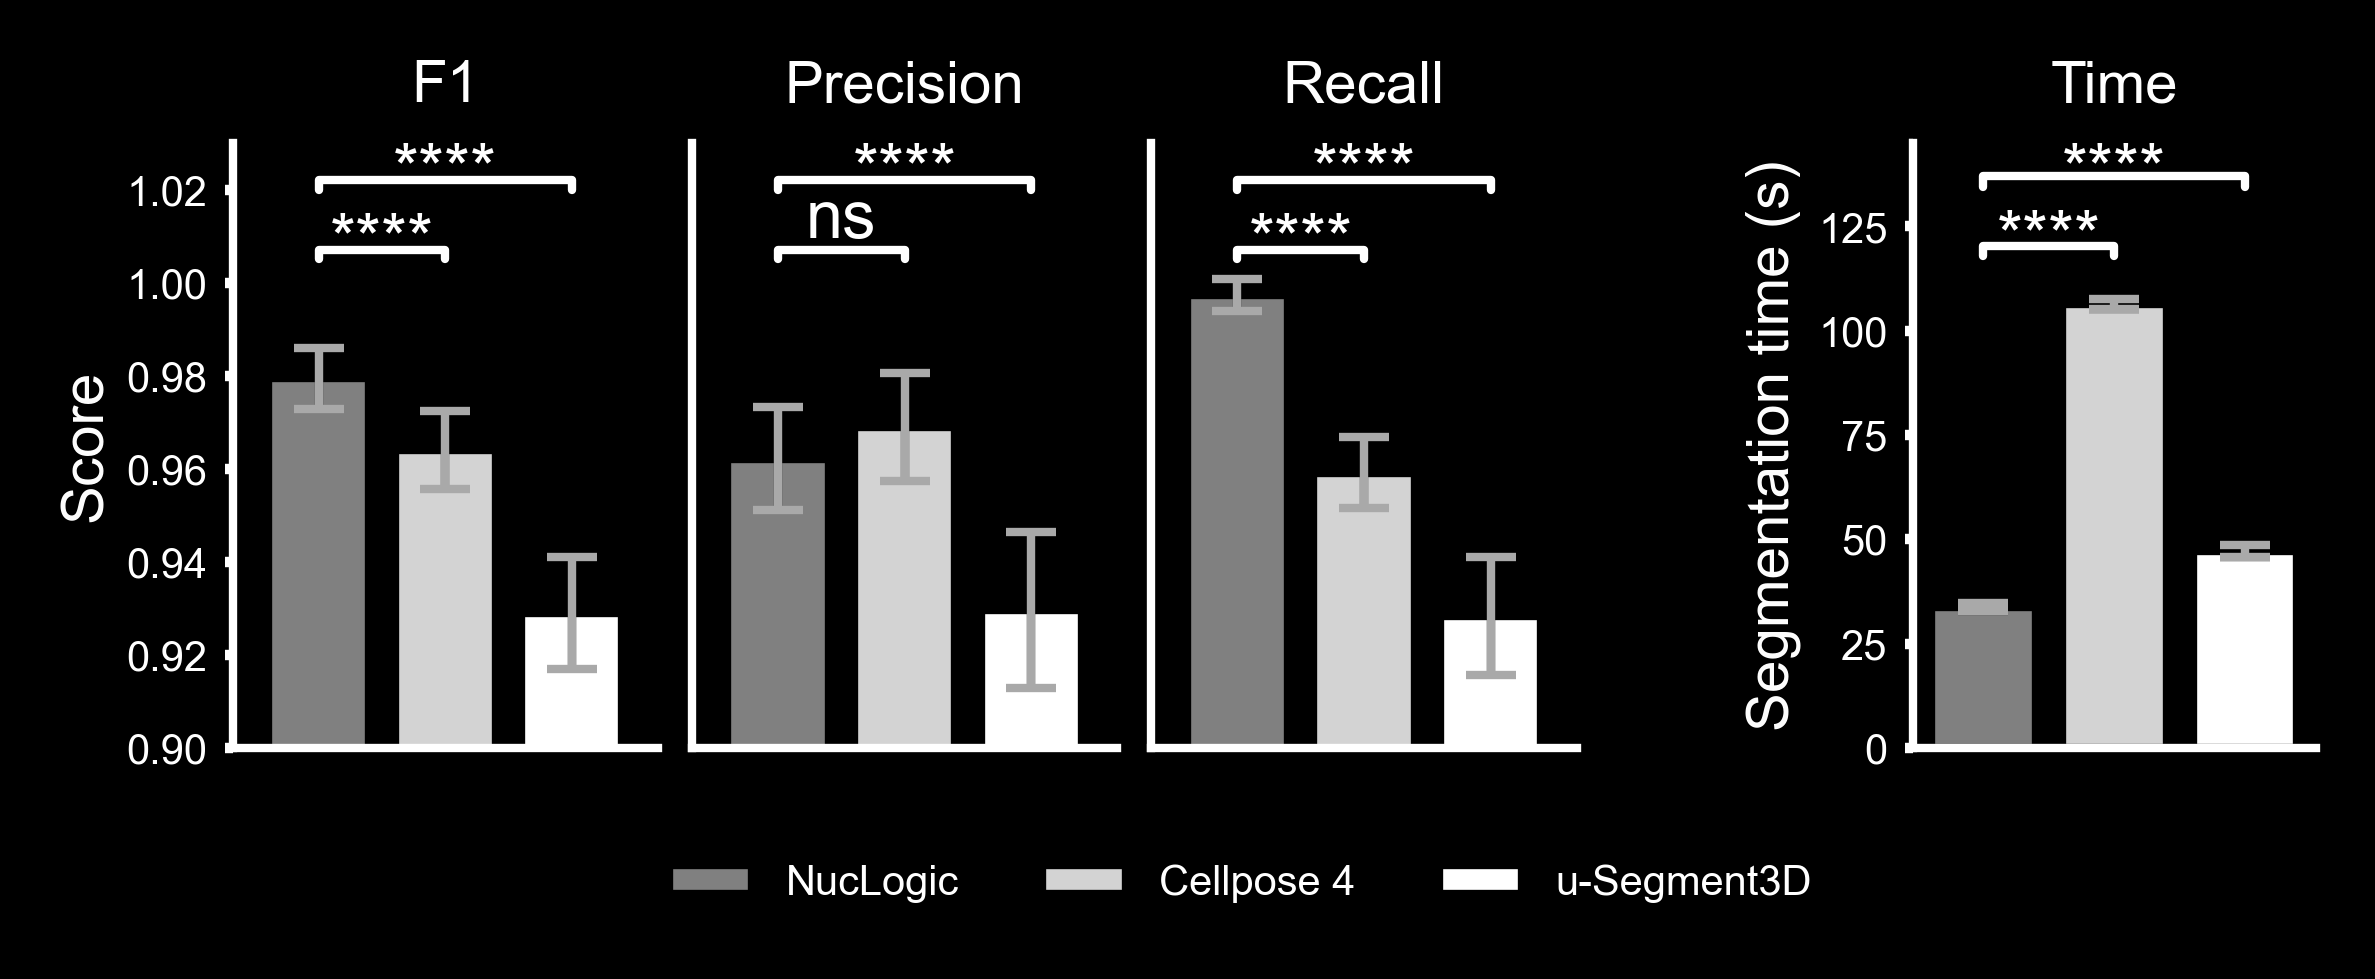

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_ind
from matplotlib.patches import Patch
import os
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "synthetic_results_new.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
score_metrics = ["f1", "precision", "recall"]
time_metric = "total_time"
sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
    },
)
sns.set_theme(
    style="dark",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "ytick.labelsize": 5,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "legend.frameon": False,
        "text.color":       "white",   # generic text (annotations, legend)
        "axes.labelcolor":  "white",   # x/y axis labels
        "axes.titlecolor":  "white",   # titles
        "xtick.color":      "white",   # x tick MARKS + numbers
        "ytick.color":      "white",   # y tick MARKS + numbers
        "axes.edgecolor":   "white",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        # tick lengths (major long, minor short)
        "xtick.major.size": 1,
        "ytick.major.size": 1,
        "xtick.minor.size": 0.5,
        "ytick.minor.size": 0.5,
        "xtick.minor.width": 1,
        "ytick.minor.width": 1,
        # show minor ticks by default
        "ytick.minor.visible": True,
        "xtick.minor.visible": False,   # your x is categorical (pointplot), leave off
        "figure.facecolor":  "black",
        "axes.facecolor":    "black",
        "savefig.facecolor": "black",
        "savefig.edgecolor": "black",
    },
)
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)
cols = score_metrics + [time_metric]            
agg = results.groupby("method")[cols].agg(["mean", "std"])

method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
legend_handles = [
    Patch(facecolor=method_colors[m], edgecolor="black", label=m)
    for m in methods
]

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
def add_bracket(ax, x1, x2, y, text, dh=0.03, barh=0.01):
    ax.plot([x1, x1, x2, x2], [y, y + barh*y, y + barh*y, y], color="white", lw=1)
    if text is not "ns":
        ax.text((x1 + x2) / 2, y + barh - dh*y, text, ha="center", va="bottom", fontsize=8)
    else:
        ax.text((x1 + x2) / 2, y + barh, text, ha="center", va="bottom", fontsize=8)

fig = plt.figure(figsize=(5.6*0.8, 2*0.8), dpi=600)
outer = fig.add_gridspec(1, 3, width_ratios=[3.0, 0.75, 0.9], wspace=0.0)

left = outer[0].subgridspec(1, 3, wspace=0.08)
axes = [fig.add_subplot(left[0, i]) for i in range(3)]

spacer = fig.add_subplot(outer[1])
spacer.axis("off")

time_ax = fig.add_subplot(outer[2])
axes.append(time_ax)

# --- 3 score bars on the LEFT axis ---
for i, metric in enumerate(score_metrics):
    means = [agg.loc[m, (metric, "mean")] for m in methods]
    sds   = [agg.loc[m, (metric, "std")]  for m in methods]

    # perform t test to check if the difference between the two methods is significant
    p_cp4 = ttest_ind(
        results[results["method"] == "NucLogic"][metric],
        results[results["method"] == "Cellpose 4"][metric],
        equal_var=False,
    ).pvalue

    p_useg = ttest_ind(
            results[results["method"] == "NucLogic"][metric],
            results[results["method"] == "u-Segment3D"][metric],
            equal_var=False,
    ).pvalue
    reject, p_adj, _, _ = multipletests([p_cp4, p_useg], alpha=0.05, method="holm")
    p_cp4_adj, p_useg_adj = p_adj
    fillcolor = [method_colors[m] for m in methods]
    axes[i].bar(methods, means, yerr=sds, linewidth=1,
           label=metric.capitalize(), color=fillcolor, edgecolor="black")
    

    max_height = 1.005
    add_bracket(axes[i], 0, 1, max_height, significance_text(p_cp4_adj), dh=0.005, barh=0.002)
    add_bracket(axes[i], 0, 2, max_height + 0.015, significance_text(p_useg_adj), dh=0.005, barh=0.002)
        
    axes[i].set_ylim(0.9, 1.03)
    axes[i].set_ylabel("")
    axes[i].set_title(metric.capitalize(), pad=5)
    axes[i].errorbar(x=methods, y=means, yerr=sds, fmt='none', color="darkgray", capsize=3)
    axes[i].margins(x=0.1)

    if i != 0:
        print(f"Removing y-tick labels for axis {i}")
        axes[i].set_yticklabels("")
        # axes[i].tick_params(left=True, bottom=False)
    else:
        axes[i].set_ylabel("Score")
        axes[i].tick_params(left=True, bottom=False)


# --- cosmetics ---
for ax in axes:
    ax.tick_params(axis="x", labelbottom=False, bottom=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

time_ax.set_ylabel("Segmentation time (s)", labelpad=2) #can adjust labelpad
time_ax.yaxis.set_label_position("left")
time_ax.yaxis.tick_left()
time_ax.tick_params(left=True, labelleft=True, right=False, labelright=False)
means = [agg.loc[m, (time_metric, "mean")] for m in methods]
sds   = [agg.loc[m, (time_metric, "std")]  for m in methods]
p_cp4 = ttest_ind(
    results[results["method"] == "NucLogic"][metric],
    results[results["method"] == "Cellpose 4"][metric],
    equal_var=False,
).pvalue

p_useg = ttest_ind(
        results[results["method"] == "NucLogic"][metric],
        results[results["method"] == "u-Segment3D"][metric],
        equal_var=False,
).pvalue
reject, p_adj, _, _ = multipletests([p_cp4, p_useg], alpha=0.05, method="holm")
p_cp4_adj, p_useg_adj = p_adj
# print(f"T-test for {time_metric}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
fillcolor = [method_colors[m] for m in methods]
axes[3].bar(methods, means, yerr=sds, linewidth=1, capsize=3,
        label=metric.capitalize(), color=fillcolor, edgecolor="black")
axes[3].errorbar(x=methods, y=means, yerr=sds, fmt='none', color="darkgray", capsize=3, )
max_height = 118
add_bracket(axes[3], 0, 1, max_height, significance_text(p_cp4_adj), barh=0.02)
add_bracket(axes[3], 0, 2, max_height*1.14, significance_text(p_useg_adj), barh=0.02)

axes[3].set_ylim(0, 145)
axes[3].set_title("Time", pad=5)

fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.05))
fig.subplots_adjust(bottom=0.25)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "synthetic_results_scores_all_black.png"), dpi=600, bbox_inches="tight")
plt.show()

Figure 2D

In [28]:
import napari
import sys
import os
from napari.utils.colormaps import colormap_utils as cu
import tifffile
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.centroid_accuracy import centroid_accuracy

colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: "#65ae45", 2: 'cyan', 3: 'magenta'}

def color_mask(mask, gt):
    results = centroid_accuracy(gt, mask)
    tp_list = results["tp_list"]
    print(f"True positives: {len(tp_list)}")
    fp_list = results["fp_list"]
    fn_list = results["fn_list"]
    # mask-based classes (tp=1, fp=2)
    lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
    lut[np.asarray(tp_list, dtype=int)] = 1
    lut[np.asarray(fp_list, dtype=int)] = 2
    colored = lut[mask]

    # fn comes from gt, painted on top
    fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
    fn_lut[np.asarray(fn_list, dtype=int)] = 3
    colored[fn_lut[gt] == 3] = 3
    return colored

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"

organoid_number = 3
realistic_volume = tifffile.imread(os.path.join(input_directory,f"synthetic_organoid_{organoid_number}", f"synthetic_organoid_{organoid_number}.tif"))
gt = tifffile.imread(os.path.join(input_directory, f"synthetic_organoid_gt_{organoid_number}", f"synthetic_organoid_gt_{organoid_number}.tif"))
nuclogic = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_nuclogic_{organoid_number}",f"synthetic_segmented_nuclogic_{organoid_number}.tif"))
nuclogic = color_mask(nuclogic, gt)
cp4 = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_cp4_{organoid_number}",f"synthetic_segmented_cp4_{organoid_number}.tif"))
cp4 = color_mask(cp4, gt)
usegment = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_usegment_{organoid_number}",f"synthetic_segmented_usegment_{organoid_number}.tif"))
usegment = color_mask(usegment, gt)
viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)

y_half = slice(0, realistic_volume.shape[1] // 2)
x_half = slice(0, realistic_volume.shape[2])

contrast = (np.median(realistic_volume) * 0.8, np.percentile(realistic_volume, 99.98))
# viewer.add_image(realistic_volume[:, y_half, x_half], scale = scale, contrast_limits = contrast, colormap="Greys")
viewer.add_image(realistic_volume[:, y_half, x_half], scale = scale, contrast_limits = contrast)
# viewer.add_labels(gt[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(cp4[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(usegment[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "synthetic_data_colored_black.png"), canvas_only=True, scale = 4)

# add top slice
# set ndisplay to 2d
viewer = napari.Viewer(ndisplay=2)
# viewer.add_image(realistic_volume, scale = scale, contrast_limits = (100, 115), colormap="Greys")
viewer.add_image(realistic_volume, scale = scale, contrast_limits = (100, 115))
viewer.add_labels(nuclogic, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(cp4, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(usegment, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
# viewer.reset_view()
# set z slice to top
viewer.dims.set_point(0, realistic_volume.shape[0] - 1)
viewer.dims.current_step = (101, 0, 0)
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'
napari.run()

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
viewer.screenshot(path=os.path.join(output_directory, "synthetic_data_slice_black.png"), canvas_only=True, scale = 2)


True positives: 300
True positives: 286
True positives: 277


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\na

array([[[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       ...,

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0

Test on drosophila

In [36]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

scale = (1, 1, 1)

# model = load_model(r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1\model\drosophila")
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    input_directory = os.path.join(base_directory, name)

    image = tifffile.imread(os.path.join(input_directory, "data.tif"))

    # start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented_seg4.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented.tif"))
    # segmentation_time = time.time() - start_time


    # start_stitch_time = time.time()
    # nuclogic = stitch_3d(
    #     mask,
    #     image,
    #     image_type_1="wt",
    #     breaking_threshold=6,
    #     scale=scale
    # )
    # end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    # nuclogic_stitch_time = end_time - start_stitch_time
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_seg4.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    # nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    # print(f"centroid accuracy: {nuclogic_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    # )

    # print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    # print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    # print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")

    usegment_start = time.time()
    usegment = usegment_stitch(mask)
    usegment_end = time.time()
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_usegment.tif"),
        usegment,
        compression="zlib",
        compressionargs={"level": 8},
    )
    # usegment_results = (centroid_accuracy(ground_truth, usegment))
    # print(f"centroid accuracy: {usegment_results}")
    # print(usegment_end - usegment_start)

    # start_cp4 = time.time()
    # cp4,_,_ = model.eval(
    #                 image,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 invert=False,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0
    #             )
    # end_cp4 = time.time()
    # cp4_time = end_cp4 - start_cp4

    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_cp4.tif"),
    #     cp4,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # cp4_results = (centroid_accuracy(ground_truth, cp4))
    # print(f"centroid accuracy: {cp4_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    # )
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    # print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # # save results of centroid accuracy and amount of cells to a tsv file

#     results_df = pd.DataFrame(
#         {
#             "method": ["nuclogic", "cellpose4"],
#             "f1": [nuclogic_results["f1"], cp4_results["f1"]],
#             "precision": [nuclogic_results["precision"], cp4_results["precision"]],
#             "recall": [nuclogic_results["recall"], cp4_results["recall"]],
#             "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
#             "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
#             "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
#             "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
#             "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
#             "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
#             "total_time": [nuclogic_time, cp4_time],
#             "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
#             "stitching_time": [nuclogic_stitch_time, 0],
#         }
#     )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "zebrafish_results_seg4.tsv"), sep="\t", index=False)

Automatric binary thresholding:  0.6


100%|██████████| 200/200 [01:20<00:00,  2.48it/s]


Automatric binary thresholding:  0.6


100%|██████████| 200/200 [00:43<00:00,  4.60it/s]


In [26]:
import os
import numpy as np
import pandas as pd
import tifffile
from cellpose.metrics import average_precision

names = ["Drosophila_1", "Drosophila_2", "Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
iou_threshold = 0.6

# Existing 3D segmentations per method, relative to each sample folder.
methods = {
    "nuclogic": "3d_segmented_nuclogic_trained.tif",
    "cellpose4": "3d_segmented_cp4.tif",
}

results = []
for name in names:
    input_directory = os.path.join(base_directory, name)
    ground_truth = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))
    actual_cells = len(np.unique(ground_truth)) - 1

    for method, filename in methods.items():
        prediction = tifffile.imread(os.path.join(input_directory, filename))
        if prediction.shape != ground_truth.shape:
            raise ValueError(f"{name}/{method}: shape {prediction.shape} != GT {ground_truth.shape}")

        # Optimal one-to-one matching on IoU (Hungarian algorithm); a matched pair
        # is a true positive only if its IoU reaches the threshold.
        _, tp, fp, fn = average_precision(ground_truth, prediction, threshold=[iou_threshold])
        tp, fp, fn = int(tp.ravel()[0]), int(fp.ravel()[0]), int(fn.ravel()[0])

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0

        results.append({
            "sample": name,
            "method": method,
            "iou_threshold": iou_threshold,
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "true_positives": tp,
            "false_positives": fp,
            "false_negatives": fn,
            "actual_cells": actual_cells,
            "predicted_cells": len(np.unique(prediction)) - 1,
        })
        print(f"{name} {method}: F1={f1:.3f}  P={precision:.3f}  R={recall:.3f}  (TP={tp}, FP={fp}, FN={fn})")

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(output_directory, f"drosophila_hungarian_iou{iou_threshold}_results.tsv"), sep="\t", index=False)


Drosophila_1 nuclogic: F1=0.818  P=0.816  R=0.819  (TP=1387, FP=312, FN=307)
Drosophila_1 cellpose4: F1=0.670  P=0.675  R=0.666  (TP=1128, FP=543, FN=566)
Drosophila_2 nuclogic: F1=0.703  P=0.696  R=0.710  (TP=348, FP=152, FN=142)
Drosophila_2 cellpose4: F1=0.486  P=0.485  R=0.488  (TP=239, FP=254, FN=251)
Zebrafish_1 nuclogic: F1=0.599  P=0.586  R=0.614  (TP=7854, FP=5560, FN=4939)
Zebrafish_1 cellpose4: F1=0.270  P=0.279  R=0.261  (TP=3341, FP=8651, FN=9452)


Mean Z height for Drosophila_1: 8.99
Mean Y size for Drosophila_1: 36.41


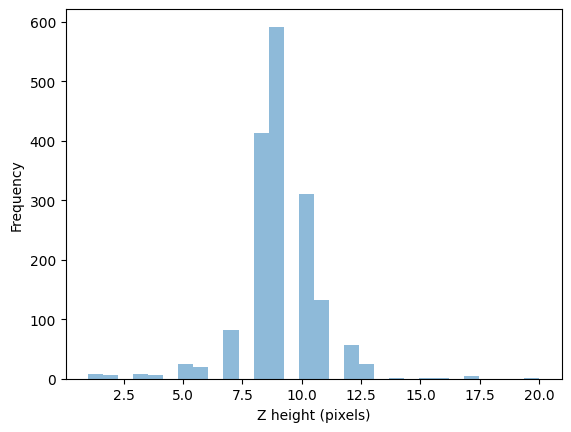

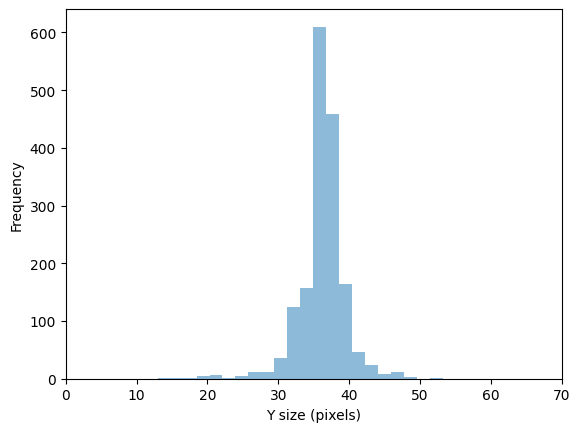

Mean Z height for Drosophila_2: 11.29
Mean Y size for Drosophila_2: 41.68


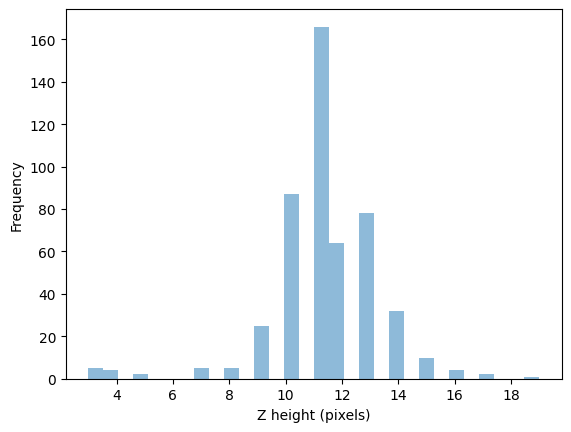

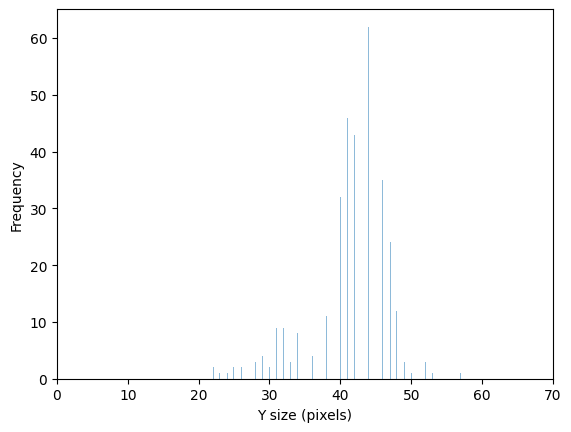

In [22]:
names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

scale = (1, 1, 1)

# model = load_model(r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1\model\drosophila")
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    input_directory = os.path.join(base_directory, name)

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    # get the mean Z height of the ground truth cells
    results_z = []
    results_y = []
    for region in regionprops(ground_truth):
        z_heights = region.bbox[3] - region.bbox[0]
        y_size = region.bbox[4] - region.bbox[1]
        results_z.append(z_heights)
        results_y.append(y_size)
    mean_z_height = np.mean(results_z)
    mean_y_size = np.mean(results_y)
    print(f"Mean Z height for {name}: {mean_z_height:.2f}")
    print(f"Mean Y size for {name}: {mean_y_size:.2f}")

    plt.hist(results_z, bins=30, alpha=0.5, label="Z height")
    plt.ylabel("Frequency")
    plt.xlabel("Z height (pixels)")
    plt.show()
    plt.hist(results_y, bins=300, alpha=0.5, label="Y size")
    plt.ylabel("Frequency")
    plt.xlabel("Y size (pixels)")
    plt.xlim(0, 70)
    plt.show()

In [5]:
# drosophila stardist
# try stardist

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize

names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for name in names:
    input_directory = os.path.join(base_directory, name)
    image = tifffile.imread(os.path.join(input_directory, "data.tif"))
    gt = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))    
    # time_start = time()
    # img = normalize(image, 1,99.8, axis=axis_norm)
    # stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    # time_end = time()
    # star_time = time_end - time_start
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_stardist_{name}.tif"), stardist.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    stardist = tifffile.imread(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"))
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results}")

#     print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

#     results_df = pd.DataFrame(
#     {
#         "method": ["stardist"],
#         "f1": [stardist_results["f1"]],
#         "precision": [stardist_results["precision"]],
#         "recall": [stardist_results["recall"]],
#         "actual_cells": [len(np.unique(gt)) - 1],
#         "predicted_cells": [len(np.unique(stardist)) - 1],
#         "true_positives": [stardist_results["true_positives"]],
#         "false_positives": [stardist_results["false_positives"]],
#         "false_negatives": [stardist_results["false_negatives"]],
#         "merged_cells": [stardist_results["merged_cells"]],
#         "total_time": [star_time],
#         "nuclogic_2d_time": [0],
#         "stitching_time": [0],
#     }
#     )
#     name = f"synthetic_organoid_{i}"
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
stardist time: 236.04s
StarDist3D centroid accuracy: {'true_positives': 1104, 'false_negatives': 590, 'false_positives': 213, 'merged_cells': 2, 'precision': 0.8382687927107062, 'recall': 0.6517119244391971, 'f1': 0.7333111922949187, 'voxel_dice': 0.50332259495602, 'tp_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 34, 35, 37, 38, 39, 40, 41, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 56, 57, 60, 63, 64, 65, 66, 67, 68, 69, 70, 73, 74, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 1

In [ ]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)

names = ["Drosophila_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))
viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (0, 180, 90)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "drosophila_data.png"), canvas_only=True, scale = 2.2)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (109.09719441054212, 99.90710855199106, 302.3227946123624)
viewer.camera.zoom   = 11.503409054721994
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "drosophila_zoomed.png"), canvas_only=True, scale = 2)

NameError: name 'os' is not defined

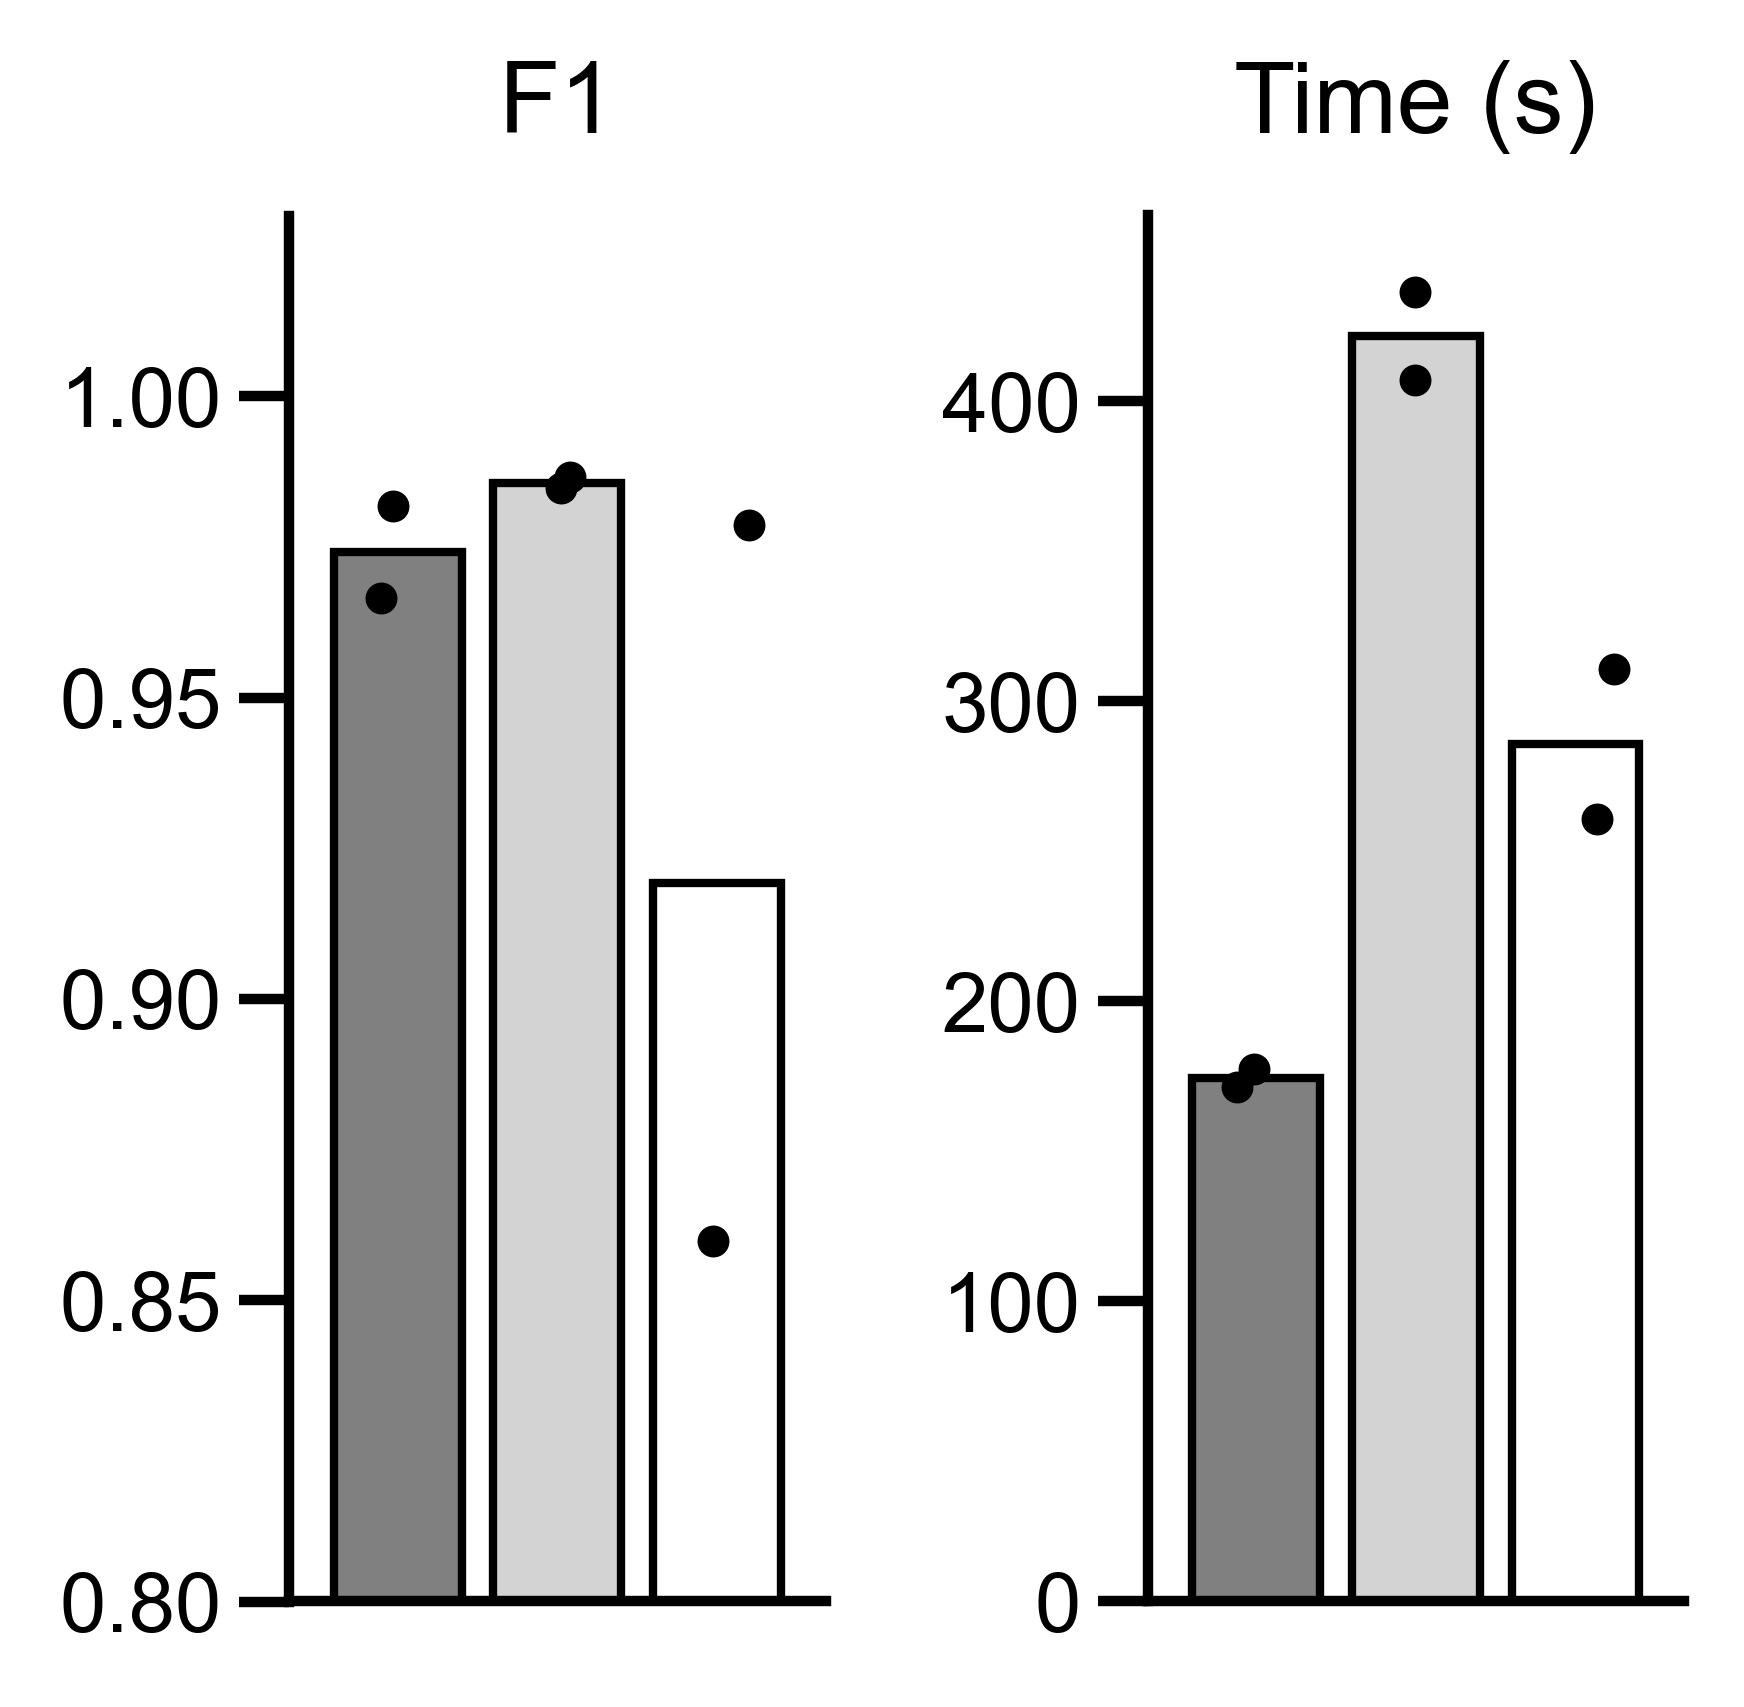

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "drosophila_results.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)                    
agg = results.groupby("method")[metrics].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, axes = plt.subplots(
    figsize=(3, 3),
    dpi=600,
    ncols=2,
    gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
)


for i, metric in enumerate(metrics):
        means = [agg.loc[m, (metric, "mean")] for m in methods]
        sds   = [agg.loc[m, (metric, "std")]  for m in methods]
        axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
        # axes[i].errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=4)
        for j, method in enumerate(methods):
                vals = results.loc[results["method"] == method, metric].to_numpy()
                jitter = np.random.normal(loc=0, scale=0.1, size=len(vals))
                axes[i].scatter(
                        np.full(len(vals), x[j]) + jitter,
                        vals,
                        color="black",
                        s=8,
                        zorder=3,
                )

        axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        axes[i].set_xticklabels("", size=8)
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)

        axes[i].tick_params(left=True, bottom=False) 
        axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
        axes[i].margins(x=0.1)
        axes[i].set_ylabel("")
        axes[i].tick_params(axis="y", labelsize=10)

        nuclogic_values = results[results["method"] == "NucLogic"][metric]
        cellpose_values = results[results["method"] == "Cellpose 4"][metric]
        usegment_values = results[results["method"] == "u-Segment3D"][metric]
        star_values = results[results["method"] == "StarDist"][metric]
     
        if i == 0:
                axes[i].set_title("F1", pad=10)
                axes[i].set_ylim(0.8, 1.03)
        else:
                axes[i].set_title("Time (s)", pad=10)
                axes[i].set_ylim(0, 462)



figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "drosophila_results_full.eps"), dpi=600, bbox_inches="tight")
plt.show()

Zebrafish

In [35]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

# names = ["Drosophila_1", "Drosophila_2"]
names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

model = load_model(
    r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish"
)
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    if name == "Zebrafish_1":
        scale = (2.5, 0.43, 0.43)

    input_directory = os.path.join(base_directory, name)

    # image = tifffile.imread(os.path.join(input_directory, "data.tif"))

    # start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented_trained.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented.tif"))
    # segmentation_time = time.time() - start_time


    # start_stitch_time = time.time()
    # nuclogic = stitch_3d(
    #     mask,
    #     image,
    #     image_type_1="wt",
    #     breaking_threshold=6,
    #     scale=scale
    # )
    # end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    # nuclogic_stitch_time = end_time - start_stitch_time
    # print(f"Stitching completed in {nuclogic_stitch_time:.2f} seconds.")
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    # nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"))

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    # nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    # print(f"centroid accuracy: {nuclogic_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    # )

    # print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    # print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    # print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")

    print("Running u-Segment3D...")
    # usegment_start = time.time()
    usegment = usegment_stitch(mask)
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_usegment.tif"),
        usegment,
        compression="zlib",
        compressionargs={"level": 8},
    )
    # usegment_end = time.time()
    # usegment_time = usegment_end - usegment_start
    # usegment_results = (centroid_accuracy(ground_truth, usegment))
    # print(f"centroid accuracy: {usegment_results}")
    # print(f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(usegment)) - 1}")
    # print(f"u-Segment3D completed in {usegment_time:.2f} seconds.")

#     start_cp4 = time.time()
#     cp4,_,_ = model.eval(
#                     image,
#                     diameter=None,
#                     normalize=True,
#                     flow3D_smooth=0.4,
#                     invert=False,
#                     resample=True,
#                     do_3D=True,
#                     z_axis=0,
#                     min_size=150,
#                 )
#     end_cp4 = time.time()
#     cp4_time = end_cp4 - start_cp4

#     tifffile.imwrite(
#         os.path.join(input_directory, "3d_segmented_cp4_trained.tif"),
#         cp4,
#         compression="zlib",
#         compressionargs={"level": 8},
#     )

#     cp4_results = (centroid_accuracy(ground_truth, cp4))
#     print(f"centroid accuracy: {cp4_results}")
#     print(
#         f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
#     )
#     print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
#     print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

#     # save results of centroid accuracy and amount of cells to a tsv file

#     results_df = pd.DataFrame(
#         {
#             "method": ["nuclogic", "cellpose4"],
#             "f1": [nuclogic_results["f1"], cp4_results["f1"]],
#             "precision": [nuclogic_results["precision"], cp4_results["precision"]],
#             "recall": [nuclogic_results["recall"], cp4_results["recall"]],
#             "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
#             "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
#             "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
#             "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
#             "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
#             "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
#             "total_time": [nuclogic_time, cp4_time],
#             "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
#             "stitching_time": [nuclogic_stitch_time, 0],
#         }
#     )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "zebrafish_results_trained.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: zebrafish
Running u-Segment3D...
Automatric binary thresholding:  0.5


100%|██████████| 200/200 [03:40<00:00,  1.10s/it]


(170, 1920, 1920)
Mean Z height for Zebrafish_1: 6.20
Mean Y size for Zebrafish_1: 22.03


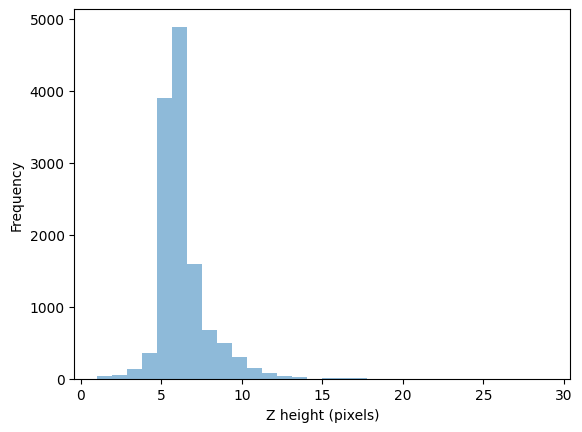

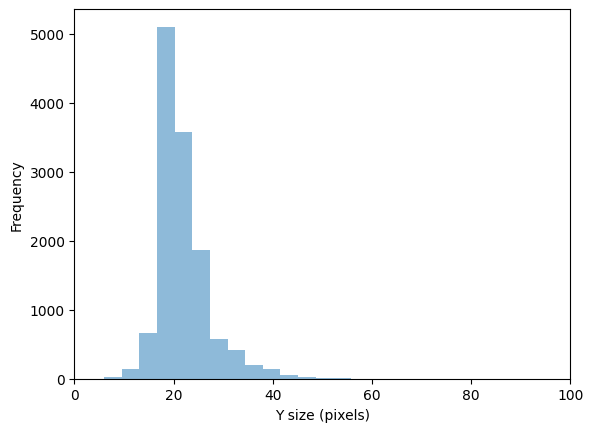

In [17]:
# Measuring zebrafish accuracy in bottom 10% of the cells
from skimage.measure import regionprops


name = "Zebrafish_1"
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
input_directory = os.path.join(base_directory, name)
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
ground_truth = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))
# nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"))
# cellpose4 = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4_trained.tif"))
print(ground_truth.shape)

from skimage.measure import regionprops
import os
import tifffile
import numpy as np
names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

scale = (2.5, 0.43, 0.43)

# get the mean Z height of the ground truth cells
results_z = []
results_y = []
for region in regionprops(ground_truth):
    z_heights = region.bbox[3] - region.bbox[0]
    y_size = region.bbox[4] - region.bbox[1]
    results_z.append(z_heights)
    results_y.append(y_size)
mean_z_height = np.mean(results_z)
mean_y_size = np.mean(results_y)
print(f"Mean Z height for {name}: {mean_z_height:.2f}")
print(f"Mean Y size for {name}: {mean_y_size:.2f}")

plt.hist(results_z, bins=30, alpha=0.5, label="Z height")
plt.ylabel("Frequency")
plt.xlabel("Z height (pixels)")
plt.show()
plt.hist(results_y, bins=400, alpha=0.5, label="Y size")
plt.ylabel("Frequency")
plt.xlabel("Y size (pixels)")
plt.xlim(0, 100)
plt.show()


In [5]:
# try stardist zebrafish

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.centroid_accuracy import centroid_accuracy

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for name in names:
    input_directory = os.path.join(base_directory, name)
    image = tifffile.imread(os.path.join(input_directory, "data.tif"))
    gt = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))    
    time_start = time()
    img = normalize(image, 1,99.8, axis=axis_norm)
    stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    time_end = time()
    star_time = time_end - time_start
    tifffile.imwrite(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"), stardist.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})
    stardist = tifffile.imread(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"))
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results}")

#     print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

#     results_df = pd.DataFrame(
#     {
#         "method": ["stardist"],
#         "f1": [stardist_results["f1"]],
#         "precision": [stardist_results["precision"]],
#         "recall": [stardist_results["recall"]],
#         "actual_cells": [len(np.unique(gt)) - 1],
#         "predicted_cells": [len(np.unique(stardist)) - 1],
#         "true_positives": [stardist_results["true_positives"]],
#         "false_positives": [stardist_results["false_positives"]],
#         "false_negatives": [stardist_results["false_negatives"]],
#         "merged_cells": [stardist_results["merged_cells"]],
#         "total_time": [star_time],
#         "nuclogic_2d_time": [0],
#         "stitching_time": [0],
#     }
#     )
#     name = f"synthetic_organoid_{i}"
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.


100%|██████████| 768/768 [12:16<00:00,  1.04it/s]


stardist time: 809.41s
StarDist3D centroid accuracy: {'true_positives': 4821, 'false_negatives': 7972, 'false_positives': 2752, 'merged_cells': 52, 'precision': 0.6366037237554469, 'recall': 0.37684671304619716, 'f1': 0.4734361190218992, 'voxel_dice': 0.3718252077811998, 'tp_list': [1, 3, 4, 5, 6, 7, 8, 9, 11, 14, 16, 19, 21, 24, 32, 35, 36, 37, 41, 43, 44, 46, 48, 49, 50, 53, 55, 56, 58, 60, 61, 63, 64, 65, 69, 71, 72, 74, 82, 89, 94, 95, 99, 101, 102, 104, 106, 107, 109, 110, 112, 113, 116, 117, 119, 120, 123, 125, 128, 130, 131, 133, 135, 138, 139, 143, 144, 145, 147, 148, 151, 152, 154, 155, 156, 157, 158, 159, 160, 161, 164, 165, 166, 167, 169, 171, 172, 173, 175, 176, 177, 178, 179, 180, 184, 185, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 211, 212, 214, 216, 217, 218, 220, 223, 225, 229, 230, 231, 232, 233, 234, 235, 237, 240, 241, 242, 243, 244, 248, 249, 250, 251, 253, 254, 256, 257, 258, 259, 260, 261, 263, 265, 26

In [5]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: 'green', 2: 'magenta', 3: 'cyan'}

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))

# def color_mask(mask, gt, tp_list, fp_list, fn_list):
#     # mask-based classes (tp=1, fp=2)
#     lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
#     lut[np.asarray(tp_list, dtype=int)] = 1
#     lut[np.asarray(fp_list, dtype=int)] = 2
#     colored = lut[mask]

#     # fn comes from gt, painted on top
#     fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
#     fn_lut[np.asarray(fn_list, dtype=int)] = 3
#     colored[fn_lut[gt] == 3] = 3
#     return colored

# nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
# nuclogic_colored = color_mask(nuclogic, ground_truth, nuclogic_results["tp_list"], nuclogic_results["fp_list"], nuclogic_results["fn_list"])
# cp4_results = (centroid_accuracy(ground_truth, cp4))
# cp4_colored = color_mask(cp4, ground_truth, cp4_results["tp_list"], cp4_results["fp_list"], cp4_results["fn_list"])

viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "zebrafish_data.png"), size=(2160, 3840), canvas_only=True, scale = 1.2)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (24.796264343669097, 237.4340231835281, 402.7615460461847)
viewer.camera.angles = (179.77222044782297, -0.3018545374737001, 1.8301771723984743)
viewer.camera.zoom   = 10.457644595201812
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "zebrafish_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1.3)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([[[110, 110, 110, 255],
        [109, 109, 109, 255],
        [107, 107, 107, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       [[110, 110, 110, 255],
        [108, 108, 108, 255],
        [106, 106, 106, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       [[109, 109, 109, 255],
        [108, 108, 108, 255],
        [106, 106, 106, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       ...,

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0

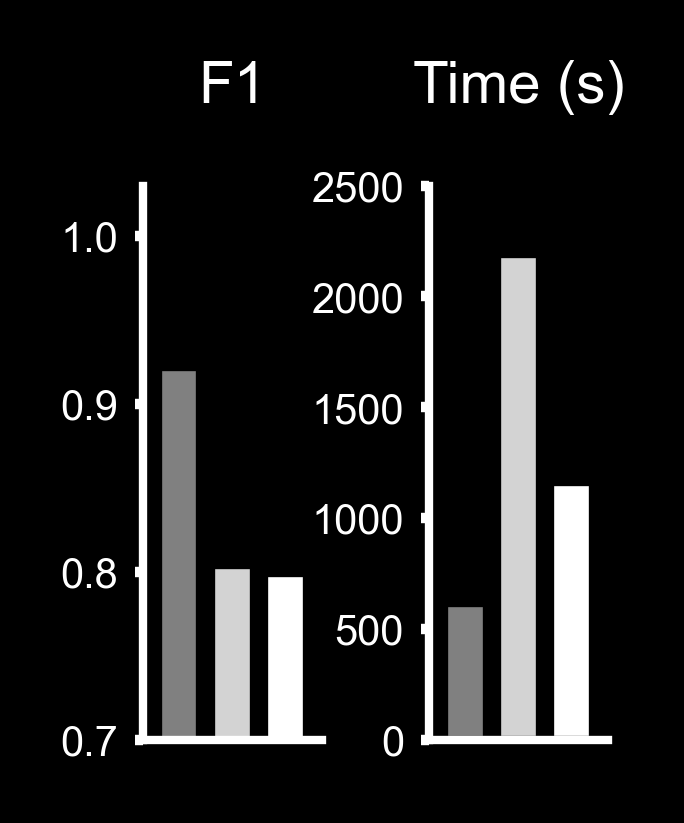

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "zebrafish_results_trained.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
sns.set_theme(
    style="dark",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "ytick.labelsize": 5,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "legend.frameon": False,
        "text.color":       "white",   # generic text (annotations, legend)
        "axes.labelcolor":  "white",   # x/y axis labels
        "axes.titlecolor":  "white",   # titles
        "xtick.color":      "white",   # x tick MARKS + numbers
        "ytick.color":      "white",   # y tick MARKS + numbers
        "axes.edgecolor":   "white",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        # tick lengths (major long, minor short)
        "xtick.major.size": 1,
        "ytick.major.size": 1,
        "xtick.minor.size": 0.5,
        "ytick.minor.size": 0.5,
        "xtick.minor.width": 1,
        "ytick.minor.width": 1,
        # show minor ticks by default
        "ytick.minor.visible": True,
        "xtick.minor.visible": False,   # your x is categorical (pointplot), leave off
        "figure.facecolor":  "black",
        "axes.facecolor":    "black",
        "savefig.facecolor": "black",
        "savefig.edgecolor": "black",
        })
# plt.style.use('dark_background')
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)                    
agg = results.groupby("method")[metrics].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, axes = plt.subplots(
    figsize=(1, 1.2),
    dpi=600,
    ncols=2,
    gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
)


for i, metric in enumerate(metrics):
        means = [agg.loc[m, (metric, "mean")] for m in methods]
        sds   = [agg.loc[m, (metric, "std")]  for m in methods]
        axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars

        axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        axes[i].set_xticklabels("")
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)

        axes[i].tick_params(left=True, bottom=False) 
        axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
        axes[i].margins(x=0.1)
        axes[i].set_ylabel("")

        nuclogic_values = results[results["method"] == "NucLogic"][metric]
        cellpose_values = results[results["method"] == "Cellpose 4"][metric]
        usegment_values = results[results["method"] == "u-Segment3D"][metric]
        star_values = results[results["method"] == "StarDist"][metric]
     
        if i == 0:
                axes[i].set_title("F1", pad=10)
                axes[i].set_ylim(0.7, 1.03)
                axes[i].yaxis.set_major_locator(MaxNLocator(nbins=4))
        else:
                axes[i].set_title("Time (s)", pad=10)
                axes[i].set_ylim(0, 2500)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "zebrafish_results_full_black.png"), dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: 'green', 2: 'magenta', 3: 'cyan'}

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))

# def color_mask(mask, gt, tp_list, fp_list, fn_list):
#     # mask-based classes (tp=1, fp=2)
#     lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
#     lut[np.asarray(tp_list, dtype=int)] = 1
#     lut[np.asarray(fp_list, dtype=int)] = 2
#     colored = lut[mask]

#     # fn comes from gt, painted on top
#     fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
#     fn_lut[np.asarray(fn_list, dtype=int)] = 3
#     colored[fn_lut[gt] == 3] = 3
#     return colored

# nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
# nuclogic_colored = color_mask(nuclogic, ground_truth, nuclogic_results["tp_list"], nuclogic_results["fp_list"], nuclogic_results["fn_list"])
# cp4_results = (centroid_accuracy(ground_truth, cp4))
# cp4_colored = color_mask(cp4, ground_truth, cp4_results["tp_list"], cp4_results["fp_list"], cp4_results["fn_list"])

viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "zebrafish_data.png"), size=(2160, 3840), canvas_only=True, scale = 1.2)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (24.796264343669097, 237.4340231835281, 402.7615460461847)
viewer.camera.angles = (179.77222044782297, -0.3018545374737001, 1.8301771723984743)
viewer.camera.zoom   = 10.457644595201812
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "zebrafish_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1.3)

Emmanuel zebrafish

In [ ]:
import napari
import nrrd
import numpy as np


image, header = nrrd.read(r"C:\Users\6331823\Local SSD\EML_zebrafish\MF59_r0c3.nrrd")
image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order
seg, header = nrrd.read(r"C:\Users\6331823\Local SSD\EML_zebrafish\MF59_masks_crop.nrrd")
seg = np.transpose(seg, (2, 1, 0))  # transpose to ZYX order

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image, scale=(0.43, 0.23, 0.23))
viewer.add_labels(seg, scale=(0.43, 0.23, 0.23), iso_gradient_mode="smooth", opacity=1)
# random_indices = np.random.choice(image.shape[0], size=10, replace=False)
# for index in random_indices:
#     slice = image[index, :, :]
#     tifffile.imwrite(os.path.join(r"C:\Users\6331823\Local SSD\EML_zebrafish\model", f"slice_{index}.tif"), slice, compression="zlib", compressionargs={"level": 8})


<Labels layer 'seg' at 0x2410f6e4890>

In [3]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile
from skimage.transform import resize
from scipy import ndimage

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"
names = ["MF59_r0c3.nrrd"]

scale = (0.43, 0.23, 0.23)  # in micrometers



model = load_model(
    os.path.join(input_directory, "model","models", "zebrafish_lightsheet")
)

results = []
for name in names:
    image, header = nrrd.read(os.path.join(input_directory, name))
    image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order
    image = ndimage.zoom(image, 0.25, order=0)

    start_time = time.time()
    mask = segment(image, model)
    tifffile.imwrite(
        os.path.join(input_directory, "2d_segmented_rescaled.tif"),
        mask,
        compression="zlib",
        compressionargs={"level": 8},
    )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_rescaled.tif"))
    segmentation_time = time.time() - start_time


    start_stitch_time = time.time()
    nuclogic = stitch_3d(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=2,
        scale=scale
    )
    end_time = time.time()
    nuclogic_time = end_time - start_time
    nuclogic_cellpose_time = start_stitch_time - start_time
    nuclogic_stitch_time = end_time - start_stitch_time

    ground_truth, header = nrrd.read(
        os.path.join(input_directory, "MF59_masks_crop.nrrd")
    )
    ground_truth = np.transpose(ground_truth, (2, 1, 0))  # transpose to ZYX order
    nuclogic = resize(nuclogic, ground_truth.shape, order=0)  # rescale back to original size
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_nuclogic_rescaled.tif"),
        nuclogic,
        compression="zlib",
        compressionargs={"level": 8},
    )
    nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_rescaled.tif"))

    nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )

    print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    start_cp4 = time.time()
    cp4,_,_ = model.eval(
                    image,
                    diameter=None,
                    normalize=True,
                    flow3D_smooth=0.4,
                    invert=False,
                    resample=True,
                    do_3D=True,
                    z_axis=0,
                    min_size=150,
                    progress=True,
                )
    end_cp4 = time.time()
    cp4_time = end_cp4 - start_cp4

    cp4 = resize(cp4, ground_truth.shape, order=0)  # rescale back to original size
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_cp4_rescaled.tif"),
        cp4,
        compression="zlib",
        compressionargs={"level": 8},
    )

    cp4_results = (centroid_accuracy(ground_truth, cp4))
    print(f"centroid accuracy: {cp4_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    )
    print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # save results of centroid accuracy and amount of cells to a tsv file

    results_df = pd.DataFrame(
        {
            "method": ["nuclogic", "cellpose4"],
            "f1": [nuclogic_results["f1"], cp4_results["f1"]],
            "precision": [nuclogic_results["precision"], cp4_results["precision"]],
            "recall": [nuclogic_results["recall"], cp4_results["recall"]],
            "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
            "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
            "total_time": [nuclogic_time, cp4_time],
            "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
            "stitching_time": [nuclogic_stitch_time, 0],
        }
    )
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results_df.to_csv(os.path.join(output_directory, "emmanuel_results_rescaled.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: zebrafish_lightsheet
Starting 3D stitching process...
Created 58118 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 5141 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 2384 breaks.
    Iteration 2: Made 1853 breaks.
    Iteration 3: Made 1097 breaks.
    Iteration 4: Made 484 breaks.
    Iteration 5: Made 155 breaks.
    Iteration 6: Made 45 breaks.
    Iteration 7: Made 7 breaks.
    Iteration 8: Made 1 breaks.
    Iteration 9: Made 1 breaks.
Finding touching cell pairs...
Found 20059 pairs of touching cells.
Splitted 11147 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 141 small cells, and removed 360 cells without suitable neighbors.
Final stitched mask has 10667 cells.
centroid accuracy: {'true_positives': 9228, 'false_negatives': 1292, 'false_positives': 1439, 'merged_cells': 1010, 'precision': 0.86

In [2]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.centroid_accuracy import centroid_accuracy
from utils.stitch_3d import stitch_3d
from scipy import ndimage
import nrrd
import numpy as np
# from utils.load_model import load_model
from skimage.transform import resize
import tifffile
import time
import pandas as pd

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"

name = "MF59_r0c3_2"

# image_normal, header = nrrd.read(os.path.join(input_directory, f"{name}.nrrd"))
# image_normal = np.transpose(image_normal, (2, 1, 0))  # transpose to ZYX order
# image_zoomed = ndimage.zoom(image_normal, 0.25, order=0)

# def degrade_image(image, bottom=0.05):
#     depth = np.linspace(0.0, 1.0, image.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
#     sqrt_part = 1.0 - (1.0 - bottom) * np.sqrt(depth)
#     d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
#     sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
#     factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
#     z_profile = (sqrt_part * factor)[:, None, None]
#     image_degraded = image * z_profile
#     return image_degraded

# image_degraded = degrade_image(image_zoomed, bottom=0.05)
# image_degraded = resize(image_degraded, image_normal.shape, order=1)  # rescale to zoomed size
# tifffile.imwrite(os.path.join(input_directory, f"{name}_degraded.tif"), image_degraded, compression="zlib", compressionargs={"level": 8})
# image_degraded = tifffile.imread(os.path.join(input_directory, f"{name}_degraded.tif"))

# images = [image_degraded]
# gt , header = nrrd.read(os.path.join(input_directory, "MF59_masks_crop_2.nrrd"))
# gt = np.transpose(gt, (2, 1, 0))  # transpose to ZYX order
gt = tifffile.imread(os.path.join(input_directory, f"MF59_r0c3_2_3d_segmented_cp4.tif")).astype(np.uint16)
# model = load_model(
#     os.path.join(input_directory, "model", "models", "zebrafish_lightsheet")
# )

# for image in images:
    # if image.shape != gt.shape:
extra_name = "_degraded"
sample_name = f"{name}_degraded"
# else:
#     extra_name = ""
#     sample_name = name
print(f"Processing {sample_name}...")
# del image
# start_nuclogic_cp = time.time()
# segmented_2d = segment(image, model)
# end_nuclogic_cp = time.time()
# nuclogic_cp_time = end_nuclogic_cp - start_nuclogic_cp
# tifffile.imwrite(
#     os.path.join(input_directory, f"{name}_2d_segmented{extra_name}.tif"),
#     segmented_2d,
#     compression="zlib",
#     compressionargs={"level": 8},
# )
# segmented_2d = tifffile.imread(os.path.join(input_directory, f"{name}_2d_segmented.tif"))
# segmented_2d = resize(segmented_2d, image.shape, order=0)  # rescale back to original size

# scale = (0.83, 0.46, 0.46)  # in micrometers
# nuclogic_start_stitch_time = time.time()
# nuclogic_3d = stitch_3d(segmented_2d,   
#         image,
#         image_type_1="wt",
#         breaking_threshold=2,
#         scale=scale
#     )
# end_nuclogic_stitch = time.time()
# nuclogic_stitch_time = end_nuclogic_stitch - nuclogic_start_stitch_time
# print(f"Nuclogic stitching time: {nuclogic_stitch_time:.2f} seconds")
# # nuclogic_time = end_nuclogic_stitch - start_nuclogic_cp

# if image.shape != gt.shape:
#     nuclogic_3d = resize(nuclogic_3d, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)

# tifffile.imwrite(
#     os.path.join(input_directory, f"{name}_3d_segmented_nuclogic{extra_name}.tif"),
#     nuclogic_3d,
#     compression="zlib",
#     compressionargs={"level": 8},
# )
nuclogic_3d = tifffile.imread(os.path.join(input_directory, f"{name}_3d_segmented_nuclogic{extra_name}.tif")).astype(np.uint16)

print("Starting centroid accuracy")
nuclogic_results = centroid_accuracy(gt, nuclogic_3d)
#     print(f"Nuclogic time: {nuclogic_time:.2f} seconds")
print(f"Nuclogic time Nuclogic results: {nuclogic_results}")
predicted_cells_nuclogic = len(np.unique(nuclogic_3d)) - 1
#     #remove nuclogic out of memory
del nuclogic_3d

#     start_usegment = time.time()
#     usegment = usegment_stitch(segmented_2d)
#     end_usegment = time.time()
#     usegment_time = end_usegment - start_usegment
#     if image.shape != gt.shape:
#         usegment = resize(usegment, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)

#     tifffile.imwrite(
#         os.path.join(input_directory, f"{name}_3d_segmented_usegment{extra_name}.tif"),
#         usegment,
#         compression="zlib",
#         compressionargs={"level": 8},
#     )
usegment = tifffile.imread(os.path.join(input_directory, f"{name}_3d_segmented_usegment{extra_name}.tif")).astype(np.uint16)
usegment_results = centroid_accuracy(gt, usegment)
# print(f"u-Segment3D time: {usegment_time:.2f} seconds")
print(f"u-Segment3D results: {usegment_results}")
predicted_cells_usegment = len(np.unique(usegment)) - 1
del usegment
#     del segmented_2d

#     start_cp4 = time.time()
#     cp4,_,_ = model.eval(
#                     image,
#                     diameter=None,
#                     normalize=True,
#                     flow3D_smooth=0.4,
#                     resample=True,
#                     do_3D=True,
#                     z_axis=0,
#                     min_size=150,
#                     progress=True,
#                 )
#     end_cp4 = time.time()
#     cp4_time = end_cp4 - start_cp4

#     if image.shape != gt.shape:
#         cp4 = resize(cp4, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)
#     tifffile.imwrite(
#         os.path.join(input_directory, f"{name}_3d_segmented_cp4{extra_name}.tif"),
#         cp4,
#         compression="zlib",
#         compressionargs={"level": 8},
#     )
cp4 = tifffile.imread(os.path.join(input_directory, f"{name}_3d_segmented_cp4{extra_name}.tif")).astype(np.uint16)
cp4_results = centroid_accuracy(gt, cp4)
#     print(f"Cellpose 4 time: {cp4_time:.2f} seconds")
predicted_cells_cp4 = len(np.unique(cp4)) - 1
del cp4
print(f"Cellpose 4 results: {cp4_results}")

actual_cells = len(np.unique(gt)) - 1

results_df = pd.DataFrame(
    {
        "method": ["nuclogic", "cellpose4", "usegment3d"],
        "f1": [nuclogic_results["f1"], cp4_results["f1"], usegment_results["f1"]],
        "precision": [nuclogic_results["precision"], cp4_results["precision"], usegment_results["precision"]],
        "recall": [nuclogic_results["recall"], cp4_results["recall"], usegment_results["recall"]],
        "actual_cells": [actual_cells, actual_cells, actual_cells],
        "predicted_cells": [predicted_cells_nuclogic, predicted_cells_cp4, predicted_cells_usegment],
        "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"], usegment_results["true_positives"]],
        "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"], usegment_results["false_positives"]],
        "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"], usegment_results["false_negatives"]],
        "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"], usegment_results["merged_cells"]],
        # "total_time": [nuclogic_time, cp4_time, usegment_time],
        # "nuclogic_2d_time": [nuclogic_cellpose_time, 0, 0],
        # "stitching_time": [nuclogic_stitch_time, 0, 0],
    }
)
results_df.insert(0, "sample", name) 

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results_df.to_csv(os.path.join(output_directory, "emmanuel_results_cp_2.tsv"), sep="\t", index=False)

Processing MF59_r0c3_2_degraded...
Starting centroid accuracy
Nuclogic time Nuclogic results: {'true_positives': 38418, 'false_negatives': 5983, 'false_positives': 1151, 'merged_cells': 3439, 'precision': 0.9709115721903511, 'recall': 0.8652507826400306, 'f1': 0.9150410861021794, 'voxel_dice': 0.9251202447879949, 'tp_list': [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77, 78, 79, 80, 81, 82, 83, 84, 86, 87, 88, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 104, 105, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,

In [ ]:
import napari
import os
import tifffile
import nrrd
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
from skimage.transform import resize
from scipy import ndimage
colormap = cu.label_colormap(num_colors=1024)

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"

image, header = nrrd.read(os.path.join(input_directory, "MF59_r0c3_2.nrrd"))
image = np.transpose(image, (2, 1, 0)) # transpose to ZYX orde
shapes = image.shape
image = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_degraded.tif"))
gt , header = nrrd.read(os.path.join(input_directory, "MF59_masks_crop_2.nrrd"))
# image = ndimage.zoom(image, 0.25, order=0)  # downsample for faster visualization
image = resize(image, (shapes[0], shapes[1], shapes[2]), order=0)  # upsample again
xy_25 = slice(0, image.shape[1] // 4)
xy_8 = slice(0, image.shape[1] // 12)
image = image[:, xy_25, :]
gt = np.transpose(gt, (2, 1, 0)).astype(np.uint16)  # transpose to ZYX order
# gt = ndimage.zoom(gt, 0.25, order=0)  # downsample for faster visualization
# gt = resize(gt, (shapes[0], shapes[1], shapes[2]), order=0).astype(np.uint16)  # upsample again
gt = gt[:, xy_25, :]
# nuclogic = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_nuclogic.tif")).astype(np.uint16)
nuclogic = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_nuclogic_degraded.tif")).astype(np.uint16)
nuclogic = nuclogic[:, xy_25, :]
# cp4 = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_cp4.tif")).astype(np.uint16)
cp4 = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_cp4_degraded.tif")).astype(np.uint16)
cp4 = cp4[:, xy_25, :]

# scale = (0.43, 0.23, 0.23)  # in micrometers
# viewer = napari.Viewer(ndisplay=2)
# # viewer.add_image(image, scale=scale) #contrast_limits=(0, 600) for degraded
# viewer.add_image(image, scale=scale, contrast_limits=(0, 600)) #contrast_limits=(0, 600) for degraded
# viewer.add_labels(gt, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(cp4, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.reset_view()
# # move to z 594
# viewer.dims.set_point(0, 575 * scale[0]) 
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# viewer.grid.enabled = True
# viewer.camera.zoom  = 3
# napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "emmanuel_degraded_slice.png"), size=(2160, 3840), canvas_only=True, scale = 1)

scale = (0.43, 0.23, 0.23)  # in micrometers
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image[:, xy_8, :], scale=scale) #contrast_limits=(0, 600) for degraded
viewer.add_labels(gt[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(nuclogic[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(cp4[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.grid.enabled = True
viewer.camera.zoom   = 1.3

napari.run()
viewer.screenshot(path=os.path.join(output_directory, "emmanuel_degraded_2.png"), size=(2160, 3840), canvas_only=True, scale = 1)

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
# viewer.camera.angles = (180.0, 0.0, 0.0)
# viewer.camera.zoom = 5
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# viewer.screenshot(path=os.path.join(output_directory, "emmanuel_normal_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1)



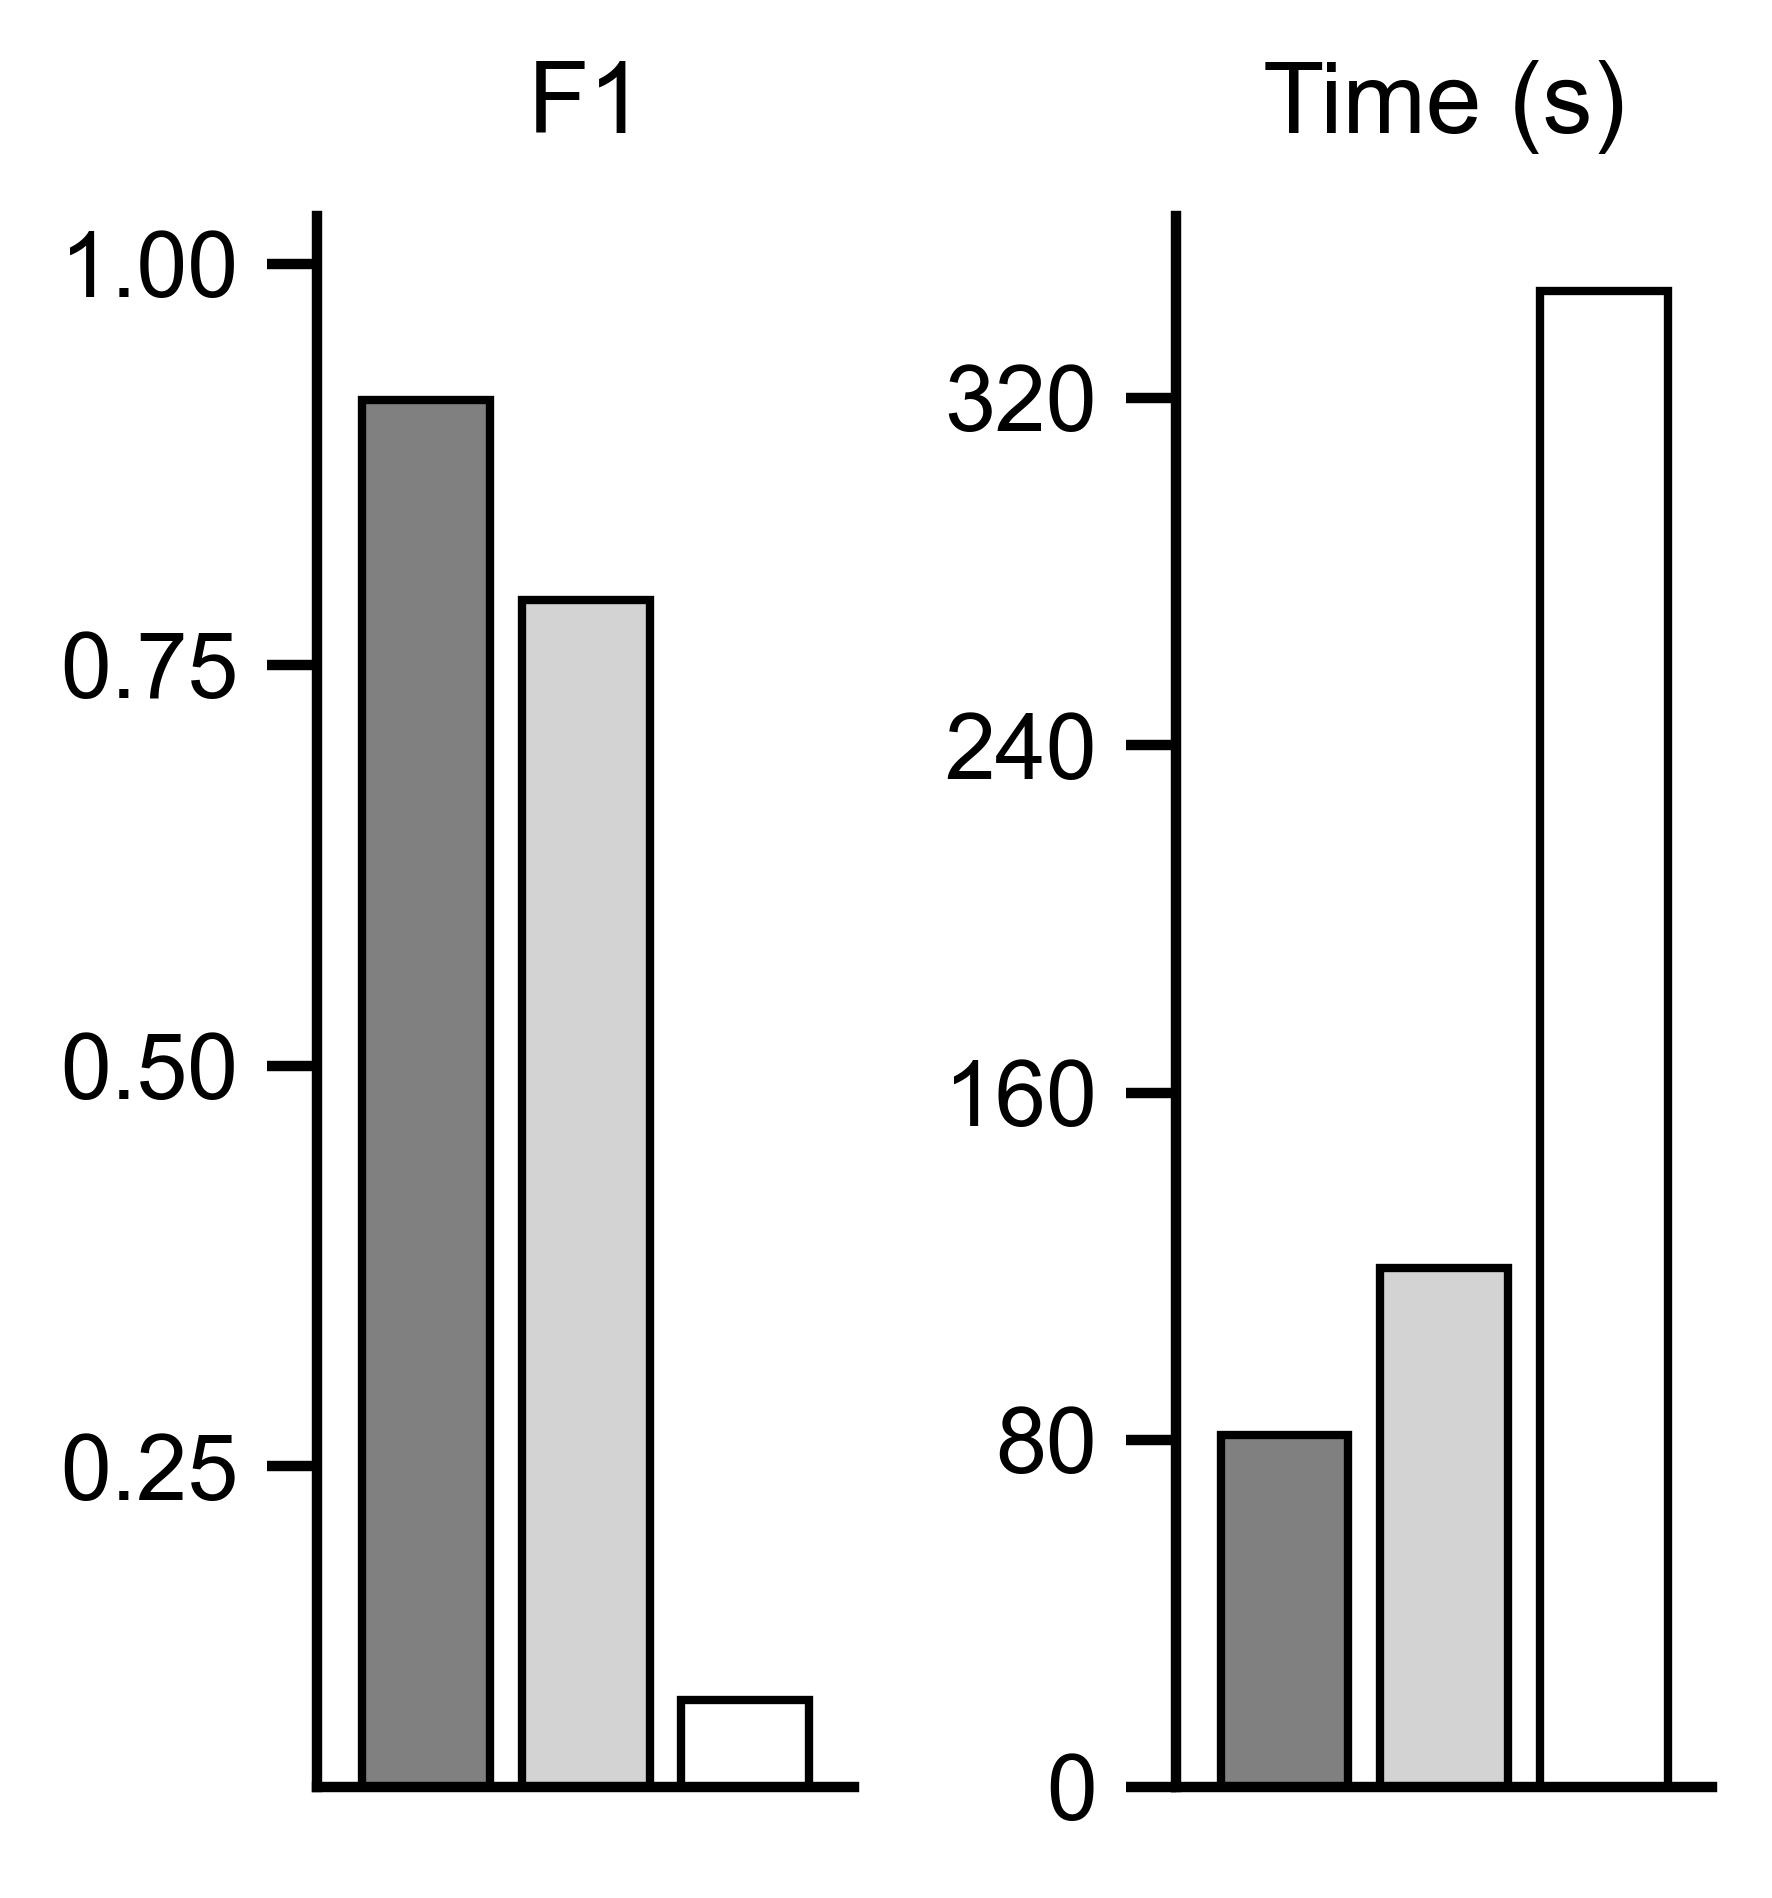

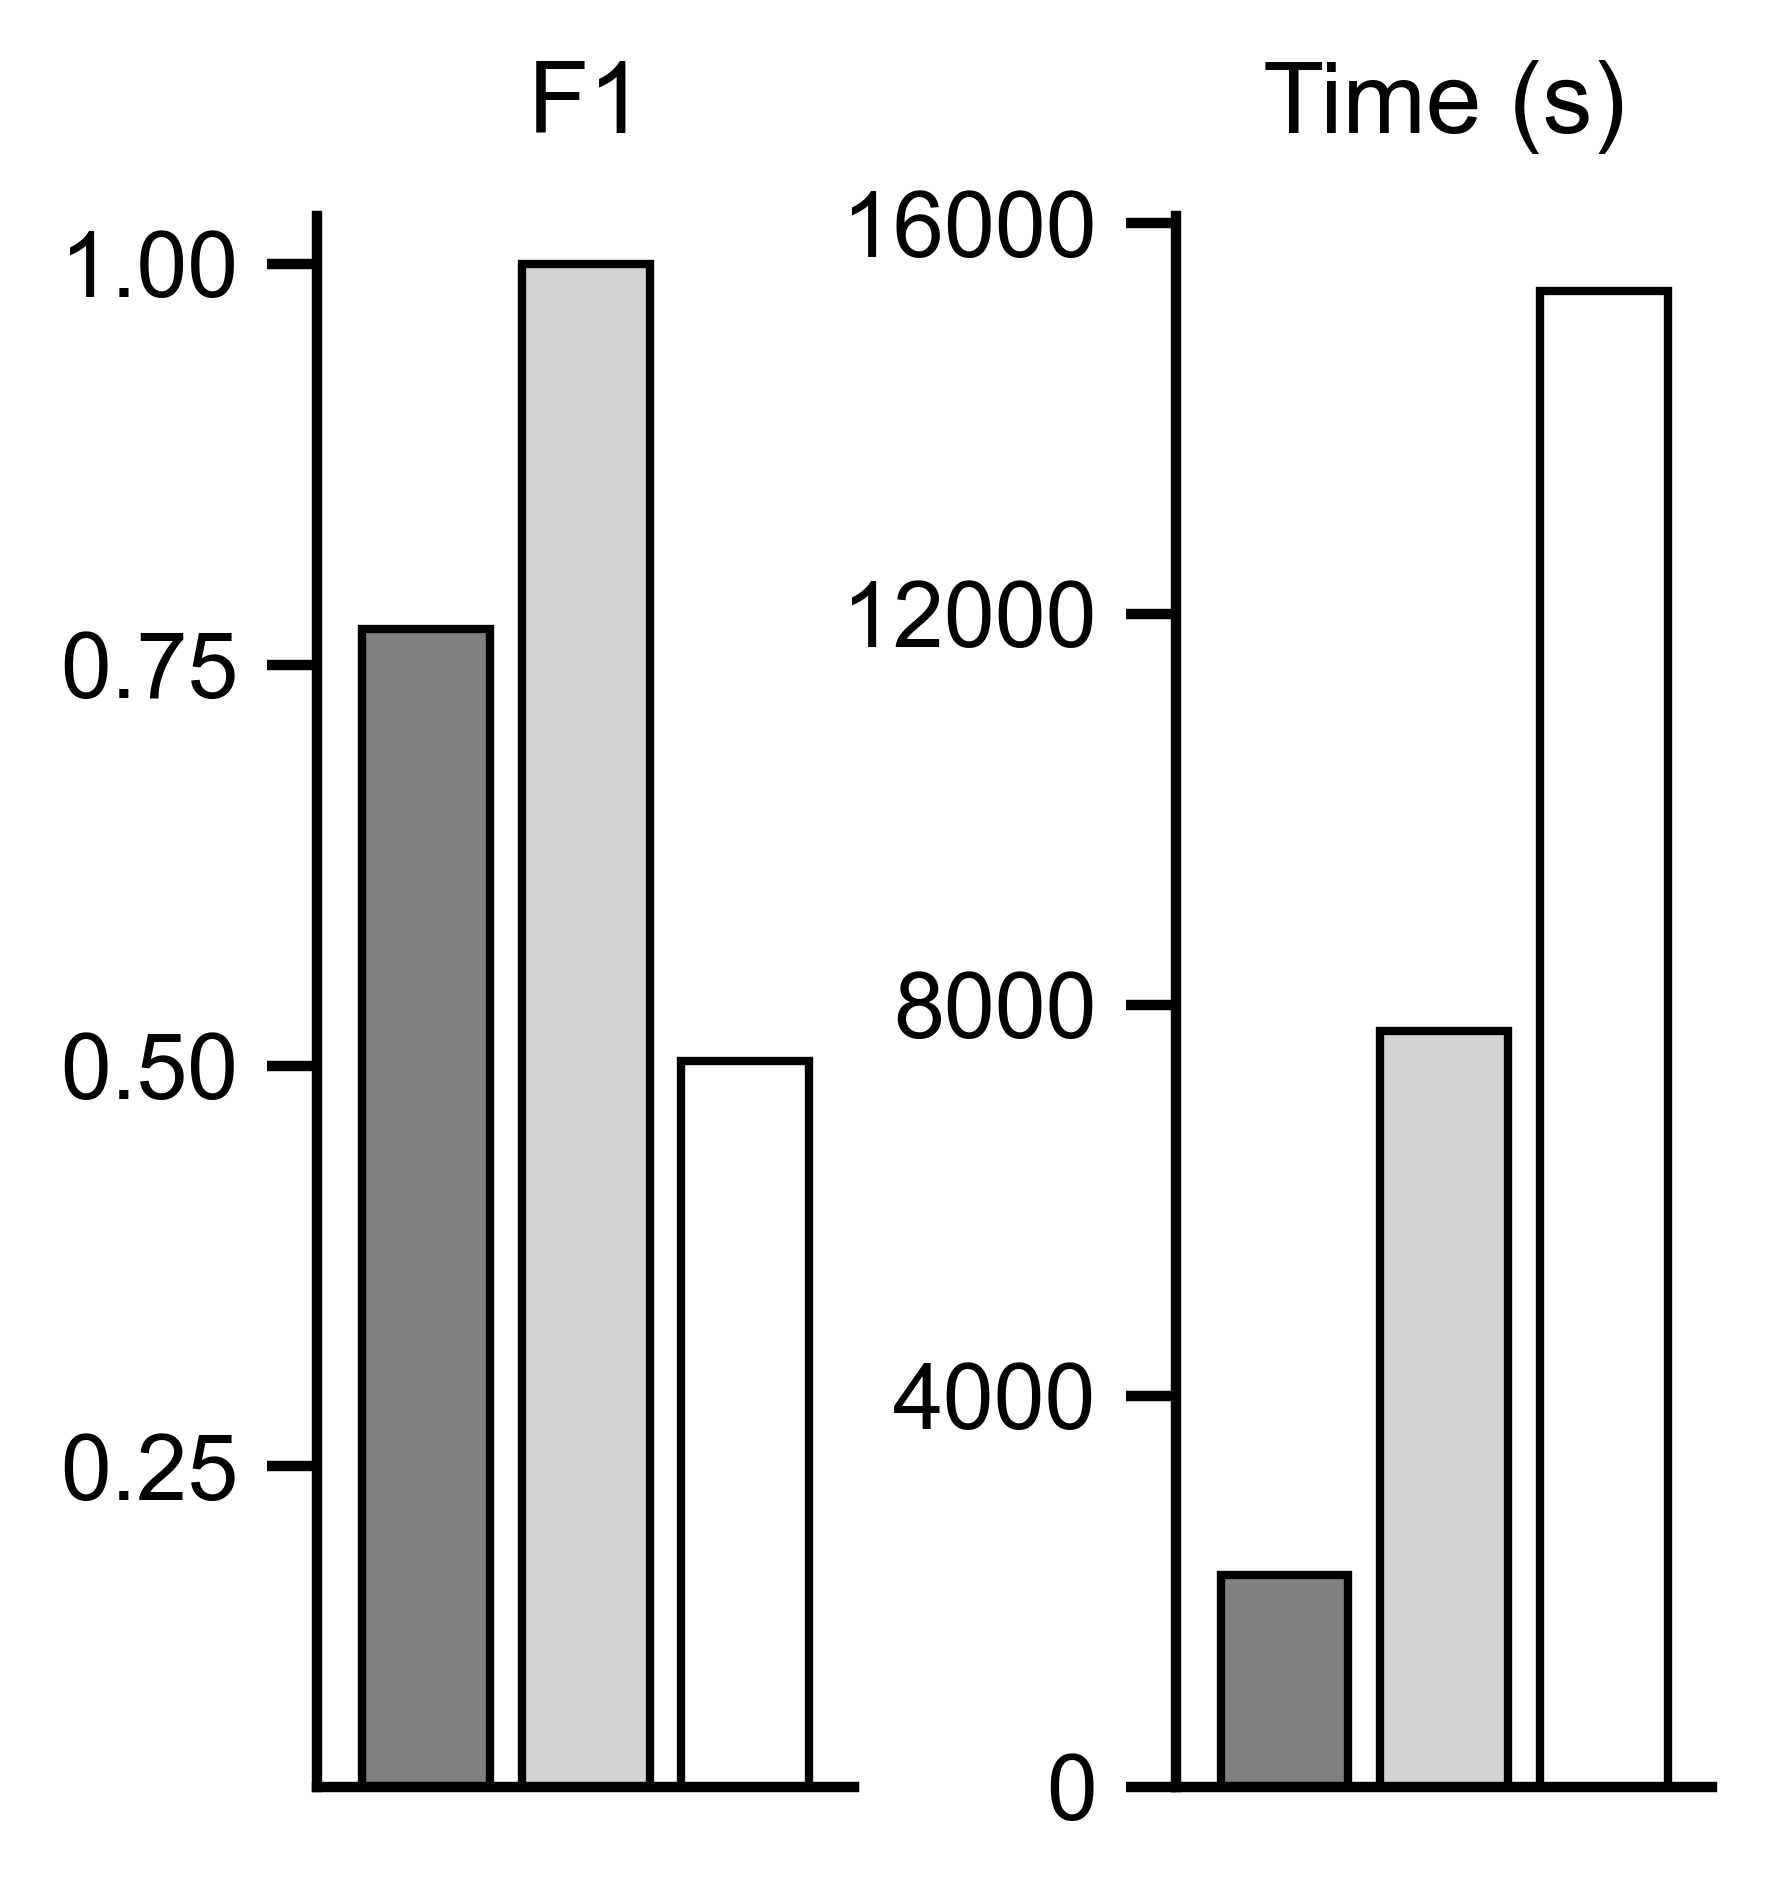

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "emmanuel_results_cp.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  
# 
for sample in results["sample"].unique():
    sample_results = results[results["sample"] == sample]                  
    agg = sample_results.groupby("method")[metrics].agg(["mean", "std"])

    x = np.arange(len(methods))          # one group center per method
    color =  "black"

    fig, axes = plt.subplots(
        figsize=(3, 3.4),
        dpi=600,
        ncols=2,
        gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
    )


    for i, metric in enumerate(metrics):
            means = [agg.loc[m, (metric, "mean")] for m in methods]
            sds   = [agg.loc[m, (metric, "std")]  for m in methods]
            axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                    label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars

            axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
            axes[i].set_xticklabels("")
            axes[i].spines["top"].set_visible(False)
            axes[i].spines["right"].set_visible(False)

            axes[i].tick_params(left=True, bottom=False) 
            axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
            axes[i].margins(x=0.1)
            axes[i].set_ylabel("")

        
            if i == 0:
                    axes[i].set_title("F1", pad=10)
                    axes[i].set_ylim(0.05, 1.03)
                    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=4))
            else:
                    axes[i].set_title("Time (s)", pad=10)
                    # axes[i].set_ylim(0, 2500)

    figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
    plt.savefig(os.path.join(figure_folder, f"emmanuel_{sample}.eps"), dpi=600, bbox_inches="tight")
    plt.show()

# Figure 4

In [ ]:
# Small intestine cell type identification



In [ ]:
# Anna data TL of hepatocyte organoids with crc cells
import os
import tifffile
import napari
from napari.utils.colormaps import colormap_utils as cu
from napari.components._viewer_constants import CanvasPosition
import numpy as np
colormap = cu.label_colormap(num_colors=1024)
input_directory = r"E:\Data Hussein\E-133_S-61_O-1"

movie = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_cropped.tif"))
segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented.tif"))
wt_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_wt_mask.tif"))
crc_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_crc_mask.tif"))
wt_mask = np.where(wt_mask > 0, 1, 0)
crc_mask = np.where(crc_mask > 0, 1, 0)
dapi = movie[:,:,0]
d2 = movie[:,:,1]
mTmG = movie[:,:,2]
dapi_contrast = (5, np.percentile(dapi, 99.99))
d2_contrast = (5, np.percentile(d2, 99.99))
mTmG_contrast = (np.median(mTmG)*1.2, np.percentile(mTmG, 99.99))

viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)

viewer.add_image(dapi, name = "DAPI", scale=scale, colormap="blue", blending="additive", contrast_limits=dapi_contrast)
viewer.add_image(d2, name = "D2", scale=scale, colormap="green",blending="additive", contrast_limits=d2_contrast)
viewer.add_image(mTmG, name = "mTmG", scale=scale, colormap="magenta", blending="additive", contrast_limits=mTmG_contrast)
viewer.add_labels(segmentation, name = "Segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="additive")
viewer.add_labels(crc_mask, name = "CRC mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"green"}, blending="translucent")
viewer.add_labels(wt_mask, name = "WT mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"magenta"}, blending="translucent")

viewer.reset_view()
def update_slider(event):
    time = viewer.dims.current_step[0]
    viewer.text_overlay.text = f"{time*5:1f} time"

viewer.text_overlay.visible = True
viewer.text_overlay.position = CanvasPosition.BOTTOM_CENTER
viewer.text_overlay.color = "white"
viewer.text_overlay.font_size = 24
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.dims.events.current_step.connect(update_slider)
viewer.grid.enabled = True
viewer.camera.angles = (180, 0, 0)
viewer.dims.set_point(0, 12)  # move to timepoint 12

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
# viewer.camera.angles = (180.0, 0.0, 0.0)
viewer.camera.zoom = 1.5
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
viewer.screenshot(path=os.path.join(output_directory, "anna_tl_channels.png"), size=(2160, 3840), canvas_only=True, scale = 1)

viewer.layers["DAPI"].visible = False
viewer.layers["D2"].visible = False
viewer.layers["mTmG"].visible = False
viewer.layers["Segmentation"].visible = False
viewer.grid.enabled = False
viewer.camera.zoom = 2
for timepoint in [0,4, 8,12]:
    viewer.dims.set_point(0, timepoint)  # move to timepoint 12
    viewer.screenshot(path=os.path.join(output_directory, f"anna_tl_combined_{timepoint}.png"), size=(2160, 3840), canvas_only=True, scale = 1)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default colo

In [75]:
import pandas as pd

# Plots of A
data = pd.read_csv(r"E:\Extra analysis for Hossein\70h_cell_data.tsv", sep="\t")

position_table = pd.read_csv(
    r"C:\Users\6331823\Downloads\hussein_positions.csv"
)

def _clean_series_to_list(series: pd.Series) -> list[str]:
    cleaned = series.dropna().astype(str).str.strip()
    return [value for value in cleaned if value]

wt_pure = _clean_series_to_list(position_table["WT pure"])
mixed = _clean_series_to_list(position_table["WT Mix"])
crc_pure = _clean_series_to_list(position_table["Cancer pure"])

# check for every row if the sample column is in wt_pure, mixed, or crc_pure and create a new column sample_type with values "WT pure", "Mix, or "CRC pure"
def determine_sample_type(sample):
    if sample in wt_pure:
        return "WT pure"
    elif sample in mixed:
        return "Mixed"
    elif sample in crc_pure:
        return "CRC pure"
    else:
        return "Unknown"
    
data["sample_type"] = data["sample"].apply(determine_sample_type)
data["time"] = data["time"].astype(int)
import numpy as np

# Counts per sample/time
wt_counts = (
    data[data["phenotype_crc_vs_wt"].str.lower().eq("wt")]
    .groupby(["sample", "time"], as_index=False)
    .size()
    .rename(columns={"size": "wt_cells"})
)

crc_counts = (
    data[data["phenotype_crc_vs_wt"].str.lower().eq("crc")]
    .groupby(["sample", "time"], as_index=False)
    .size()
    .rename(columns={"size": "crc_cells"})
)

total_counts = (
    data.groupby(["sample", "time"], as_index=False)
    .size()
    .rename(columns={"size": "total_cells"})
)

# Merge by keys (sample + time), not by index
summary_df = total_counts.merge(wt_counts, on=["sample", "time"], how="left").merge(
    crc_counts, on=["sample", "time"], how="left"
)

summary_df["wt_cells"] = summary_df["wt_cells"].fillna(0).astype(int)
summary_df["crc_cells"] = summary_df["crc_cells"].fillna(0).astype(int)

# Baseline at t=0 per sample
t0 = summary_df[summary_df["time"] == 0][
    ["sample", "total_cells", "wt_cells", "crc_cells"]
].rename(
    columns={
        "total_cells": "total_cells_t0",
        "wt_cells": "wt_cells_t0",
        "crc_cells": "crc_cells_t0",
    }
)

summary_df = summary_df.merge(t0, on="sample", how="left")

# Relative growth per sample (vs each sample's own t=0)
summary_df["relative_growth_total"] = summary_df["total_cells"] / summary_df[
    "total_cells_t0"
].replace(0, np.nan)
summary_df["relative_growth_wt"] = summary_df["wt_cells"] / summary_df[
    "wt_cells_t0"
].replace(0, np.nan)
summary_df["relative_growth_crc"] = summary_df["crc_cells"] / summary_df[
    "crc_cells_t0"
].replace(0, np.nan)

summary_df["sample_type"] = summary_df["sample"].apply(determine_sample_type)

#remove unnecessary columns
summary_df = summary_df.drop(columns=["total_cells_t0", "wt_cells_t0", "crc_cells_t0"])

# Move sample_type column to the front
cols = summary_df.columns.tolist()
cols.insert(0, cols.pop(cols.index("sample_type")))
summary_df = summary_df[cols]

print(summary_df.head())

summary = []
full_data = []
for sample in summary_df["sample"].unique():
    sample_data = summary_df[summary_df["sample"] == sample]
    raw_sample_data = data[data["sample"] == sample]
    if sample_data["sample_type"].iloc[0] == "WT pure" and sample_data["relative_growth_crc"].notna().any():
        sample_data["wt_cells"] = sample_data["total_cells"]
        sample_data["crc_cells"] = 0
        sample_data["relative_growth_wt"] = sample_data["relative_growth_total"]
        sample_data["relative_growth_crc"] = 0
        summary.append(sample_data)

        raw_sample_data["phenotype_crc_vs_wt"] = "wt"
        full_data.append(raw_sample_data)
    elif sample_data["sample_type"].iloc[0] == "CRC pure" and sample_data["relative_growth_wt"].notna().any():
        sample_data["wt_cells"] = 0
        sample_data["crc_cells"] = sample_data["total_cells"]
        sample_data["relative_growth_wt"] = 0
        sample_data["relative_growth_crc"] = sample_data["relative_growth_total"]
        summary.append(sample_data)

        raw_sample_data["phenotype_crc_vs_wt"] = "crc"
        full_data.append(raw_sample_data)
    else:
        summary.append(sample_data)
        full_data.append(raw_sample_data)

summary = pd.concat(summary, ignore_index=True)
full_data = pd.concat(full_data, ignore_index=True)


print(summary.head())

  sample_type          sample  time  total_cells  wt_cells  crc_cells  \
0     WT pure  E-133_S-10_O-1     0           20        20          0   
1     WT pure  E-133_S-10_O-1     5           23        23          0   
2     WT pure  E-133_S-10_O-1    10           26        26          0   
3     WT pure  E-133_S-10_O-1    15           33        33          0   
4     WT pure  E-133_S-10_O-1    20           28        28          0   

   relative_growth_total  relative_growth_wt  relative_growth_crc  
0                   1.00                1.00                  NaN  
1                   1.15                1.15                  NaN  
2                   1.30                1.30                  NaN  
3                   1.65                1.65                  NaN  
4                   1.40                1.40                  NaN  


C:\Users\6331823\AppData\Local\Temp\ipykernel_36996\3172458746.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data["wt_cells"] = sample_data["total_cells"]
C:\Users\6331823\AppData\Local\Temp\ipykernel_36996\3172458746.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data["crc_cells"] = 0
C:\Users\6331823\AppData\Local\Temp\ipykernel_36996\3172458746.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

  sample_type          sample  time  total_cells  wt_cells  crc_cells  \
0     WT pure  E-133_S-10_O-1     0           20        20          0   
1     WT pure  E-133_S-10_O-1     5           23        23          0   
2     WT pure  E-133_S-10_O-1    10           26        26          0   
3     WT pure  E-133_S-10_O-1    15           33        33          0   
4     WT pure  E-133_S-10_O-1    20           28        28          0   

   relative_growth_total  relative_growth_wt  relative_growth_crc  
0                   1.00                1.00                  NaN  
1                   1.15                1.15                  NaN  
2                   1.30                1.30                  NaN  
3                   1.65                1.65                  NaN  
4                   1.40                1.40                  NaN  


In [77]:
df_mixed = summary[summary["sample_type"] == "Mixed"].copy()
df_mixed = df_mixed[df_mixed["time"] <= 60]
print(len(np.unique(df_mixed["sample"])))

46


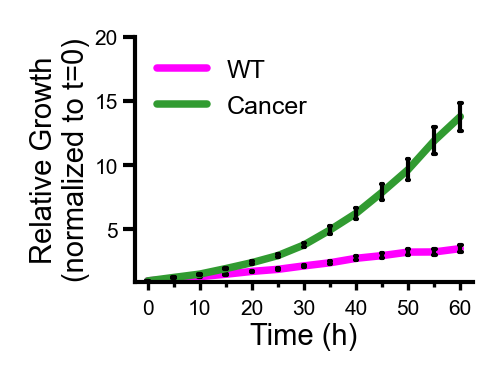

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from matplotlib.ticker import MaxNLocator, LogLocator, NullFormatter
import statsmodels.formula.api as smf
# sns.set_theme(
#     style="dark",
#     context="notebook",
#     font="Arial",
#     rc={
#         "font.family": "Arial",
#         "font.sans-serif": ["Arial"],
#         "font.size": 6,
#         "axes.titlesize": 7,
#         "axes.labelsize": 7,
#         "xtick.labelsize": 5,
#         "xtick.major.pad": 2,
#         "ytick.major.pad": 2,
#         "ytick.labelsize": 5,
#         "legend.fontsize": 5,
#         "legend.title_fontsize": 5,
#         "legend.frameon": False,
#         "text.color":       "white",   # generic text (annotations, legend)
#         "axes.labelcolor":  "white",   # x/y axis labels
#         "axes.titlecolor":  "white",   # titles
#         "xtick.color":      "white",   # x tick MARKS + numbers
#         "ytick.color":      "white",   # y tick MARKS + numbers
#         "axes.edgecolor":   "white",   # spines (optional, if those look gray too)
#         "axes.labelpad": 1.5,  # space between axis and label
#         "lines.linewidth": 1,  
#         "axes.linewidth": 1,
#         # tick lengths (major long, minor short)
#         "xtick.major.size": 1,
#         "ytick.major.size": 1,
#         "xtick.minor.size": 0.5,
#         "ytick.minor.size": 0.5,
#         "xtick.minor.width": 1,
#         "ytick.minor.width": 1,
#         # show minor ticks by default
#         "ytick.minor.visible": True,
#         "xtick.minor.visible": False,   # your x is categorical (pointplot), leave off
#         "figure.facecolor":  "black",
#         "axes.facecolor":    "black",
#         "savefig.facecolor": "black",
#         "savefig.edgecolor": "black",
#     },
# )

sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "ytick.labelsize": 5,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "legend.frameon": False,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        # tick lengths (major long, minor short)
        "xtick.major.size": 1,
        "ytick.major.size": 1,
        "xtick.minor.size": 0.5,
        "ytick.minor.size": 0.5,
        "xtick.minor.width": 1,
        "ytick.minor.width": 1,
        # show minor ticks by default
        "ytick.minor.visible": True,
        "xtick.minor.visible": False,   # your x is categorical (pointplot), leave off
    
    },
)

# Show mixed only
df_mixed = summary[summary["sample_type"] == "Mixed"].copy()

# show all organoids
# df_mixed = summary.copy()

df_mixed = df_mixed[df_mixed["time"] <= 60]
df_mixed_long = df_mixed.melt(
    id_vars=["sample", "time", "sample_type"],
    value_vars=["relative_growth_wt", "relative_growth_crc"],
    var_name="cell_type",
    value_name="relative_growth"
)
df_mixed_long["cell_type"] = df_mixed_long["cell_type"].replace({"relative_growth_wt": "WT mixed", "relative_growth_crc": "Cancer mixed"})

mm = 1 / 25.4  # millimeters in inches
fig, axes = plt.subplots(nrows=1, figsize=(37*mm,27*mm), dpi=300, gridspec_kw={"hspace": 0.4})
# Plot 1: relative_wt

# Show mixed only
df_mixed = summary[summary["sample_type"] == "Mixed"].copy()
df_mixed = df_mixed[df_mixed["time"] <= 60]
df_mixed_long = df_mixed.melt(
    id_vars=["sample", "time", "sample_type"],
    value_vars=["relative_growth_wt", "relative_growth_crc"],
    var_name="cell_type",
    value_name="relative_growth"
)
df_mixed_long["cell_type"] = df_mixed_long["cell_type"].replace({"relative_growth_wt": "WT mixed", "relative_growth_crc": "Cancer mixed"})

mm = 1 / 25.4  # millimeters in inches
# fig, axes = plt.subplots(nrows=1, figsize=(37*mm,27*mm), dpi=300, gridspec_kw={"hspace": 0.4})
# Plot 1: relative_wt
sns.pointplot(
    data=df_mixed_long,
    x="time",
    y="relative_growth",
    hue="cell_type",
    hue_order=["WT mixed", "Cancer mixed"],
    palette={"WT mixed": "magenta", "Cancer mixed": "#319b31"},
    errorbar="se",  # or "se" for standard error, or ("ci", 95) for confidence interval
    capsize=0.1,  # Width of error bar caps
    err_kws={"linewidth": 1, "color": "black"},  # Style the error bars
    markersize=0,  # Size of the points
)
plt.ylabel("Relative Growth\n(normalized to t=0)", labelpad=1)
plt.xlabel("")
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["WT", "Cancer"],
           title="", loc="upper left", fontsize=6, frameon=False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
# plt.gca().set_yscale("log")
plt.gca().set_ylim((0.9,20))
plt.tick_params(axis="y", pad=1)  

# set tick params to have numbers every 10 hours and minor ticks every 5 hours
from matplotlib.ticker import FixedLocator, FixedFormatter

times = sorted(df_mixed_long["time"].unique())
major = [i for i, t in enumerate(times) if t % 10 == 0]
minor = [i for i, t in enumerate(times) if t % 5 == 0 and t % 10 != 0]

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator(major))
ax.xaxis.set_major_formatter(FixedFormatter([str(int(times[i])) for i in major]))
ax.xaxis.set_minor_locator(FixedLocator(minor))
plt.tick_params(axis="x", which="minor", bottom=True, width=.8, length=1.3)
plt.tick_params(axis="x", which="major", bottom=True, width=.8, length=2)

# ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
# ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9), numticks=10))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis="y", which="major", left=True, length=3, width=1, pad=1)
# ax.tick_params(axis="y", which="minor", left=True, length=1.5, width=0.8)
plt.xlabel("Time (h)", labelpad=1)

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
plt.savefig(os.path.join(output_directory, f"TL_growth_curves_mixed.eps"), dpi=600, bbox_inches="tight")

# plt.savefig(os.path.join(output_directory, f"TL_growth_curves_mixed_black.png"), dpi=1200, bbox_inches="tight")
plt.show()


In [7]:
# B create schemetic overview of how EDT transform works
#B overview of touching cells
import os
import tifffile
import napari
from napari.utils.colormaps import colormap_utils as cu
from napari.utils.colormaps import DirectLabelColormap
from napari.components._viewer_constants import CanvasPosition
import numpy as np
import pandas as pd
from scipy import ndimage
colormap = cu.label_colormap(num_colors=1024)
input_directory = r"E:\Data Hussein\E-133_S-61_O-1"
scale = (0.64, 0.64) # in micrometers
segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented.tif"))
selected = [1, 11, 13, 16, 18, 19]
selected_mask = np.isin(segmentation, selected).astype(np.uint16)
selected_mask = np.where(selected_mask > 0, segmentation, 0).astype(np.uint16)
selected_mask = selected_mask[12] # show only 1 timepoint
selected_mask = np.max(selected_mask, axis=0) 

#transform 5um
background = selected_mask == 0
distance, indices = ndimage.distance_transform_edt(background, sampling=scale, return_indices=True)
grow = background & (distance <= 5)
expanded = selected_mask.copy()
expanded[grow] = selected_mask[indices[0][grow], indices[1][grow]]
from skimage.segmentation import find_boundaries

bordered = expanded.copy()
bordered[find_boundaries(expanded, mode="inner", connectivity=1)] = 0


def colormap_cell(cell_numbers, color1, color2):
    colormap = {None: color2, 0: ""}
    for cell in cell_numbers:
            colormap[int(cell)] = color1
    return DirectLabelColormap(color_dict=colormap)

viewer = napari.Viewer(ndisplay=2)
viewer.add_labels(selected_mask, name = "Selected cells", scale=(1,1), iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(expanded, name = "expanded", scale=(1,1), iso_gradient_mode="smooth", opacity=1, colormap=colormap)

cells = []
for cell in selected:
    cells.append(cell)
    colormap_selected = colormap_cell(cells, "magenta", "lime")
    viewer.add_labels(bordered, name = f"expanded_{cells}", scale=(1,1), colormap=colormap_selected)
viewer.reset_view()
viewer.grid.enabled = True
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.camera.zoom = 2
#make background white
viewer.theme = 'light'
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
viewer.screenshot(path=os.path.join(output_directory, "EDT transform.png"), size=(2160, 3840), scale = 1)


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\standardize_color.py:91: UserWarning: Empty string detected. Returning black instead.
  warnings.warn(


array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [36]:
#B overview of touching cells
import os
import tifffile
import napari
from napari.utils.colormaps import colormap_utils as cu
from napari.components._viewer_constants import CanvasPosition
import numpy as np
import pandas as pd
colormap = cu.label_colormap(num_colors=1024)
input_directory = r"E:\Data Hussein\E-133_S-61_O-1"

segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented.tif"))
dilated_segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented_touching_neighbour_5um.tif"))
wt_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_wt_mask.tif"))
crc_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_crc_mask.tif"))
properties = pd.read_csv(os.path.join(input_directory, "E-133_S-61_O-1_properties.tsv"), sep="\t")

combined_mask = []
for timepoint in range(segmentation.shape[0]):
    segmentation_timepoint = dilated_segmentation[timepoint]
    timepoint_properties = properties[properties["timepoint"] == timepoint]
    wt_properties = timepoint_properties[timepoint_properties["phenotype_crc_vs_wt"].str.lower() == "wt"]
    wt_touching_ids = wt_properties[wt_properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1]["label"].values
    wt_non_touching_ids = wt_properties[wt_properties["phenotype_similarity_ratio_touching_neighbour_5um"] == 1]["label"].values
    crc_properties = timepoint_properties[timepoint_properties["phenotype_crc_vs_wt"].str.lower() == "crc"]
    crc_touching_ids = crc_properties[crc_properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1]["label"].values
    crc_non_touching_ids = crc_properties[crc_properties["phenotype_similarity_ratio_touching_neighbour_5um"] == 1]["label"].values

    combined_mask.append(np.select(
        [
            np.isin(segmentation_timepoint, wt_touching_ids),
            np.isin(segmentation_timepoint, wt_non_touching_ids),
            np.isin(segmentation_timepoint, crc_touching_ids),
            np.isin(segmentation_timepoint, crc_non_touching_ids),
        ],
        [1, 2, 3, 4],
        default=0,
    ).astype(np.uint8))
combined_mask = np.stack(combined_mask, axis=0)
tifffile.imwrite(os.path.join(input_directory, "E-133_S-61_O-1_combined_mask_dilated.tif"), combined_mask, compression="zlib", compressionargs={"level": 8})
combined_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_combined_mask_dilated.tif"))
colormap_mixed = {2: "#f1a7c4", 1: "magenta", 4: "#a7eaa7", 3: "#319b31"}
colomap_touching = {1: "magenta", 3: "#319b31"}

viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)
viewer.add_labels(segmentation, name = "Segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="additive")
viewer.add_labels(dilated_segmentation, name = "Dilated Segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="additive")
# viewer.add_labels(crc_mask, name = "CRC mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"green"}, blending="translucent")
# viewer.add_labels(wt_mask, name = "WT mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"magenta"}, blending="translucent")
viewer.add_labels(combined_mask, name = "Combined Mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap_mixed, blending="translucent")
viewer.add_labels(combined_mask, name = "Combined Mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colomap_touching, blending="translucent")

viewer.reset_view()
def update_slider(event):
    time = viewer.dims.current_step[0]
    viewer.text_overlay.text = f"{time*5:1f} time"

viewer.text_overlay.visible = True
viewer.text_overlay.position = CanvasPosition.BOTTOM_CENTER
viewer.text_overlay.color = "white"
viewer.text_overlay.font_size = 24
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.dims.events.current_step.connect(update_slider)
viewer.grid.enabled = True
viewer.camera.angles = (180, 0, 0)
viewer.dims.set_point(0, 12)  # move to timepoint 12

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
viewer.camera.angles = (148.75832664972222, -29.25266749741341, 47.47202111488936)
viewer.camera.zoom = 1.2
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# viewer.screenshot(path=os.path.join(output_directory, "anna_interaction.png"), size=(2160, 3840), canvas_only=True, scale = 1)


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


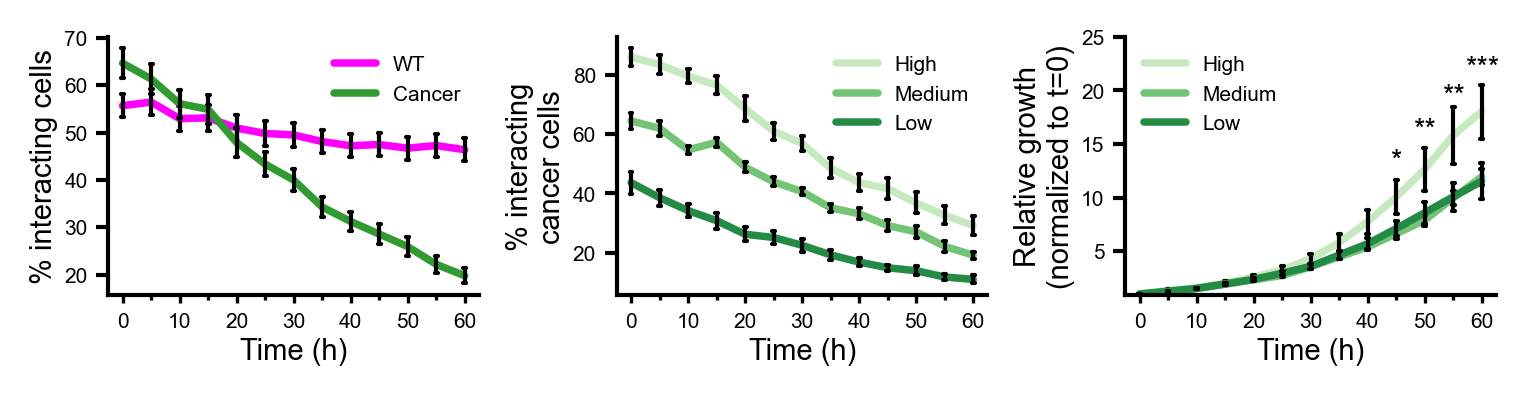

In [112]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

p = full_data.copy()
p = p[p["sample_type"] == "Mixed"]
p = p[p["time"] <= 60]
pheno = p["phenotype_crc_vs_wt"].str.lower()
interacting = p["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

p["wt"]      = pheno == "wt"
p["crc"]     = pheno == "crc"
p["int_wt"]  = p["wt"]  & interacting
p["int_crc"] = p["crc"] & interacting

results = (
    p.groupby(["time", "sample"])[["wt", "crc", "int_wt", "int_crc"]]
    .sum()
    .reset_index()
)
results["percent_interacting_wt"]  = results["int_wt"]  / results["wt"]  * 100
results["percent_interacting_crc"] = results["int_crc"] / results["crc"] * 100
results["relative_growth_crc"] = results["crc"] / results.groupby("sample")["crc"].transform("first")

sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        # set ticks thickness
        "xtick.major.width": 1,
        "ytick.major.width": 1,
    },
)

long = results.melt(
    id_vars="time",
    value_vars=["percent_interacting_wt", "percent_interacting_crc"],
    var_name="cell_type",
    value_name="percent_interacting",
)
mm = 1 / 25.4
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(129 * mm, 33 * mm), dpi=300)
position1 = 0
position2 = 1
position3 = 2
sns.pointplot(
    data=long,
    x="time",
    y="percent_interacting",
    hue="cell_type",
    palette={
        "percent_interacting_wt":  "magenta",
        "percent_interacting_crc": "#319b31",
    },
    ax=axes[position1],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "black"},
    markersize=0,
)
axes[position1].set_ylabel("% interacting cells")
axes[position1].set_xlabel("Time (h)")
handles, _ = axes[position1].get_legend_handles_labels()
axes[position1].legend(handles=handles, labels=["WT", "Cancer"], title="", frameon=False)

axes[position1].spines["top"].set_visible(False)
axes[position1].spines["right"].set_visible(False)
# remove legend box
axes[position1].legend_.get_frame().set_linewidth(0.0)
#turn on ticks
axes[position1].tick_params(axis="both", which="major", bottom=True, left=True, size=3)

# one tercile label per SAMPLE, based on its mean CRC interaction across time
sample_level = results.groupby("sample")["percent_interacting_crc"].mean()
sample_group = pd.qcut(sample_level, q=3, labels=["Low", "Medium", "High"])
# sample_group = pd.qcut(sample_level, q=2, labels=["Low", "High"])
# edges = np.linspace(sample_level.min(), sample_level.max(), 4)
# sample_group = pd.cut(
#     sample_level,
#     bins=edges,
#     labels=["Low", "Medium", "High"],
#     include_lowest=True,          # <-- so the min value lands in "Low" instead of NaN
# )

results["interaction_group"] = results["sample"].map(sample_group)

sns.pointplot(
    data=results,
    x="time",
    y="percent_interacting_crc",
    hue="interaction_group",
    hue_order=["High", "Medium", "Low"],
    palette={"High": "#c7e9c0", "Medium": "#74c476", "Low": "#238b45"},
    ax=axes[position2],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "black"},
    markersize=0,
)
axes[position2].set_ylabel("% interacting\ncancer cells")
axes[position2].set_xlabel("Time (h)")
handles, _ = axes[position2].get_legend_handles_labels()
axes[position2].legend(handles=handles, labels=["High", "Medium", "Low"], title="", frameon=False)

axes[position2].spines["top"].set_visible(False)
axes[position2].spines["right"].set_visible(False)
axes[position2].legend_.get_frame().set_linewidth(0.0)
axes[position2].tick_params(axis="both", which="major", bottom=True, left=True, size=3)

sns.pointplot(
    data=results,
    x="time",
    y="relative_growth_crc",
    hue="interaction_group",
    hue_order=["High", "Medium", "Low"],
    palette={"High": "#c7e9c0", "Medium": "#74c476", "Low": "#238b45"},
    ax=axes[position3],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "black"},
    markersize=0,
)
# axes[position3].set_yscale("log")
axes[position3].set_ylim(0.9, 25)
axes[position3].set_ylabel("Relative growth\n(normalized to t=0)")
axes[position3].set_xlabel("Time (h)")
handles, _ = axes[position3].get_legend_handles_labels()

# ax.legend_.remove()
axes[position3].legend(handles=handles, labels=["High", "Medium", "Low"], title="", frameon=False, loc="upper left")
axes[position3].legend_.get_frame().set_linewidth(0.0)
axes[position3].spines["top"].set_visible(False)
axes[position3].spines["right"].set_visible(False)
axes[position3].tick_params(axis="both", which="major", bottom=True, left=True, size=3)
# axes[position3].tick_params(axis="y",    which="minor", left=True, width= .8, length=2)
# Calculate statistics between High and Low group
selected_results = results[results["interaction_group"].isin(["High", "Low"])].copy()
selected_results["interaction_group"] = selected_results["interaction_group"].cat.remove_unused_categories() 
selected_results["log_growth"] = np.log(selected_results["relative_growth_crc"])
selected_results = selected_results.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth"])
stats = smf.mixedlm("log_growth ~ C(time) * interaction_group", selected_results, groups=selected_results["sample"]).fit()

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

for i, time in enumerate(selected_results["time"].unique()):
    p_value = stats.pvalues.get(f"C(time)[T.{time}]:interaction_group[T.High]", np.nan)
    sig_text = significance_text(p_value)
    time_y_max = [selected_results[selected_results["time"] == time]["relative_growth_crc"].mean() for time in selected_results[selected_results["interaction_group"] == "High"]["time"].unique()][i]
    axes[position3].text(i, time_y_max * 1.4, sig_text, ha="center", va="bottom", fontsize=7)

major = [i for i, t in enumerate(times) if t % 10 == 0]
minor = [i for i, t in enumerate(times) if t % 5 == 0 and t % 10 != 0]

for ax in axes:
    ax.xaxis.set_major_locator(FixedLocator(major))
    ax.xaxis.set_major_formatter(FixedFormatter([str(int(times[i])) for i in major]))
    ax.xaxis.set_minor_locator(FixedLocator(minor))
    ax.tick_params(axis="x", which="minor", bottom=True, width=.8, length=1.3)
    ax.tick_params(axis="x", which="major", bottom=True, width=.8, length=2)

# axes[0, 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"TL_interacting_cells_overview.eps"), dpi=600, bbox_inches="tight")

In [81]:
stats.pvalues

Intercept                                   1.000000e+00
C(time)[T.5]                                7.280813e-03
C(time)[T.10]                               2.158244e-07
C(time)[T.15]                               6.395429e-16
C(time)[T.20]                               2.362112e-25
C(time)[T.25]                               7.778249e-39
C(time)[T.30]                               3.036913e-54
C(time)[T.35]                               4.147404e-77
C(time)[T.40]                               7.145500e-98
C(time)[T.45]                              2.981800e-123
C(time)[T.50]                              4.632205e-145
C(time)[T.55]                              8.736090e-166
C(time)[T.60]                              2.270335e-183
interaction_group[T.High]                   1.000000e+00
C(time)[T.5]:interaction_group[T.High]      7.416714e-01
C(time)[T.10]:interaction_group[T.High]     9.418874e-01
C(time)[T.15]:interaction_group[T.High]     9.937540e-01
C(time)[T.20]:interaction_group

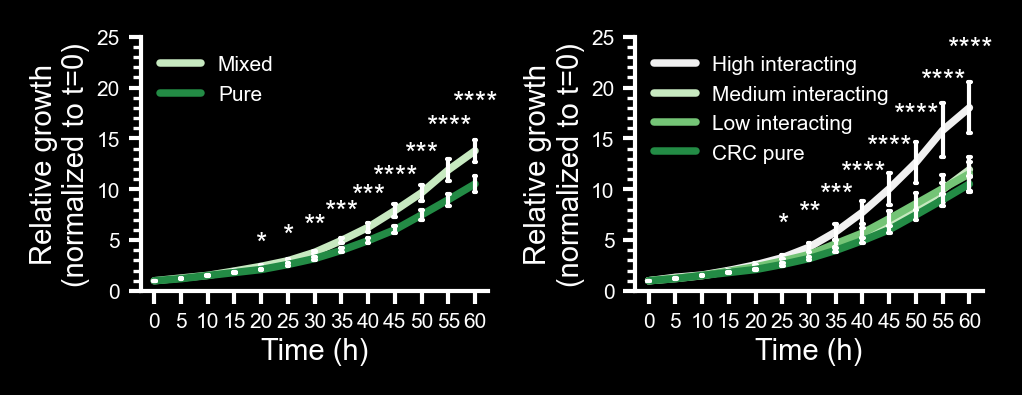

In [60]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

p = full_data.copy()
# p = p[p["sample_type"] == "Mixed"]
p = p[p["time"] <= 60]
pheno = p["phenotype_crc_vs_wt"].str.lower()
interacting = p["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

p["wt"]      = pheno == "wt"
p["crc"]     = pheno == "crc"
p["int_wt"]  = p["wt"]  & interacting
p["int_crc"] = p["crc"] & interacting

results = (
    p.groupby(["time", "sample", "sample_type"])[["wt", "crc", "int_wt", "int_crc"]]
    .sum()
    .reset_index()
)
results["percent_interacting_wt"]  = results["int_wt"]  / results["wt"]  * 100
results["percent_interacting_crc"] = results["int_crc"] / results["crc"] * 100
results["relative_growth_crc"] = results["crc"] / results.groupby("sample")["crc"].transform("first")

# sns.set_theme(
#     style="white",
#     context="notebook",
#     font="Arial",
#     rc={
#         "font.family": "Arial",
#         "font.sans-serif": ["Arial"],
#         "font.size": 6,
#         "axes.titlesize": 7,
#         "axes.labelsize": 7,
#         "xtick.labelsize": 5,
#         "ytick.labelsize": 5,
#         "xtick.major.pad": 2,
#         "ytick.major.pad": 2,
#         "legend.fontsize": 5,
#         "legend.title_fontsize": 5,
#         "text.color":       "black",   # generic text (annotations, legend)
#         "axes.labelcolor":  "black",   # x/y axis labels
#         "axes.titlecolor":  "black",   # titles
#         "xtick.color":      "black",   # x tick MARKS + numbers
#         "ytick.color":      "black",   # y tick MARKS + numbers
#         "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
#         "axes.labelpad": 1.5,  # space between axis and label
#         "lines.linewidth": 1,  
#         "axes.linewidth": 1,
#         # set ticks thickness
#         "xtick.major.width": 1,
#         "ytick.major.width": 1,
#     },
# )
sns.set_theme(
    style="dark",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "white",   # generic text (annotations, legend)
        "axes.labelcolor":  "white",   # x/y axis labels
        "axes.titlecolor":  "white",   # titles
        "xtick.color":      "white",   # x tick MARKS + numbers
        "ytick.color":      "white",   # y tick MARKS + numbers
        "axes.edgecolor":   "white",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        # set ticks thickness
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "figure.facecolor":  "black",
        "axes.facecolor":    "black",
        "savefig.facecolor": "black",
        "savefig.edgecolor": "black",
    },
)
mixed_results = results[results["sample_type"] == "Mixed"]
long = mixed_results.melt(
    id_vars="time",
    value_vars=["percent_interacting_wt", "percent_interacting_crc"],
    var_name="cell_type",
    value_name="percent_interacting",
)
mm = 1 / 25.4
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(129 * (2/3) * mm, 33 * mm), dpi=300)
position1 = 0
position2 = 1
# one tercile label per SAMPLE, based on its mean CRC interaction across time
pure_crc_label = "CRC pure"   # <-- set to whatever your pure-CRC sample_type is called

sample_level = mixed_results.groupby("sample")["percent_interacting_crc"].mean()
sample_group = pd.qcut(sample_level, q=3, labels=["Low", "Medium", "High"]).astype(str)

group_order = ["High", "Medium", "Low", "CRC pure"]
results["interaction_group"] = results["sample"].map(sample_group)
results.loc[results["sample_type"] == pure_crc_label, "interaction_group"] = "CRC pure"
results["interaction_group"] = pd.Categorical(results["interaction_group"], categories=group_order)

group_palette = {"High": "#c7e9c0", "Medium": "#74c476", "Low": "#238b45", "CRC pure": "#888888"}


sns.pointplot(
    data=results,
    x="time",
    y="relative_growth_crc",
    hue="sample_type",
    hue_order=[ "Mixed", "CRC pure"],
    palette={"Mixed": "#c7e9c0", "CRC pure": "#238b45"},
    ax=axes[position1],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "white"},
    markersize=0,
)
# axes[position3].set_yscale("log")
axes[position1].set_ylim(0, 25)
axes[position1].set_ylabel("Relative growth\n(normalized to t=0)")
axes[position1].set_xlabel("Time (h)")
handles, _ = axes[position1].get_legend_handles_labels()

# ax.legend_.remove()
axes[position1].legend(handles=handles, labels=["Mixed", "Pure"], title="", frameon=False, loc="upper left")
axes[position1].legend_.get_frame().set_linewidth(0.0)
axes[position1].spines["top"].set_visible(False)
axes[position1].spines["right"].set_visible(False)
axes[position1].tick_params(axis="both", which="major", bottom=True, left=True, size=3)
axes[position1].tick_params(axis="y",    which="minor", left=True, width= .8, length=2)
# Calculate statistics between High and Low group

selected_results = results[results["sample_type"].isin(["Mixed", "CRC pure"])].copy()
selected_results["log_growth"] = np.log(selected_results["relative_growth_crc"])
selected_results = selected_results.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth"])
stats = smf.mixedlm("log_growth ~ C(time) * C(sample_type, Treatment('CRC pure'))",
                    selected_results, groups=selected_results["sample"]).fit()

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

for i, time in enumerate(selected_results["time"].unique()):
    p_value = stats.pvalues.get(f"C(time)[T.{time}]:C(sample_type, Treatment('CRC pure'))[T.Mixed]", np.nan)
    sig_text = significance_text(p_value)
    time_y_max = [selected_results[selected_results["time"] == time]["relative_growth_crc"].mean() for time in selected_results["time"].unique()][i]
    axes[position1].text(i, time_y_max * 1.4, sig_text, ha="center", va="bottom", fontsize=7, color="white")


sns.pointplot(
    data=results,
    x="time",
    y="relative_growth_crc",
    hue="interaction_group",
    hue_order=["High", "Medium", "Low", "CRC pure"],
    palette={"High": "#f1f1f1", "Medium": "#c7e9c0", "Low": "#74c476", "CRC pure": "#238b45"},
    ax=axes[position2],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "white"},
    markersize=0,
)
# axes[position3].set_yscale("log")
axes[position2].set_ylim(0, 25)
axes[position2].set_ylabel("Relative growth\n(normalized to t=0)")
axes[position2].set_xlabel("Time (h)")
handles, _ = axes[position2].get_legend_handles_labels()

# ax.legend_.remove()
axes[position2].legend(handles=handles, labels=["High interacting", "Medium interacting", "Low interacting", "CRC pure"], title="", frameon=False, loc="upper left")
axes[position2].legend_.get_frame().set_linewidth(0.0)
axes[position2].spines["top"].set_visible(False)
axes[position2].spines["right"].set_visible(False)
axes[position2].tick_params(axis="both", which="major", bottom=True, left=True, size=3)
axes[position2].tick_params(axis="y",    which="minor", left=True, width= .8, length=2)
# Calculate statistics between High and Low group
selected_results = results[results["interaction_group"].isin(["High", "CRC pure"])].copy()
selected_results["interaction_group"] = (
    selected_results["interaction_group"]
    .cat.remove_unused_categories()
    .cat.reorder_categories(["CRC pure", "High"])
) 
selected_results["log_growth"] = np.log(selected_results["relative_growth_crc"])
selected_results = selected_results.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth"])
stats = smf.mixedlm("log_growth ~ C(time) * interaction_group", selected_results, groups=selected_results["sample"]).fit()

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

for i, time in enumerate(selected_results["time"].unique()):
    p_value = stats.pvalues.get(f"C(time)[T.{time}]:interaction_group[T.High]", np.nan)
    sig_text = significance_text(p_value)
    time_y_max = [selected_results[selected_results["time"] == time]["relative_growth_crc"].mean() for time in selected_results[selected_results["interaction_group"] == "High"]["time"].unique()][i]
    axes[position2].text(i, time_y_max * 1.8, sig_text, ha="center", va="bottom", fontsize=7, color="white")

# axes[0, 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"TL_growth_patterns.png"), dpi=600, bbox_inches="tight")
plt.show()


In [66]:
condition1 = "High"
condition2 = "Low"
selected_results = results[results["interaction_group"].isin([condition1, condition2])].copy()
selected_results["interaction_group"] = (
    selected_results["interaction_group"]
    .cat.remove_unused_categories()
    .cat.reorder_categories([condition2, condition1])
) 
selected_results["log_growth"] = np.log(selected_results["relative_growth_crc"])
selected_results = selected_results.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth"])
stats = smf.mixedlm("log_growth ~ C(time) * interaction_group", selected_results, groups=selected_results["sample"]).fit()

# get the mean relative growth for each time point and interaction group
mean_growth = selected_results.groupby(["time", "interaction_group"])["relative_growth_crc"].mean().reset_index()
from scipy import stats as st   # don't name it `stats`, that holds your mixedlm fit

g = selected_results.groupby(["time", "interaction_group"], observed=True)["relative_growth_crc"]

summary_growth = g.agg(mean="mean", sem="sem", n="count").reset_index()
summary_growth["ci95"] = summary_growth["sem"] * st.t.ppf(0.975, summary_growth["n"] - 1)
print("Mean relative growth for each time point and interaction group:")
print(mean_growth)
print("\nStandard deviation of relative growth for each time point and interaction group:")
print(summary_growth)

# print p values not as scientific notation
for i, time in enumerate(selected_results["time"].unique()):
    p_value = stats.pvalues.get(f"C(time)[T.{time}]:interaction_group[T.{condition1}]", np.nan)
    print(f"Time {time}: p-value = {p_value:.5f}")

Mean relative growth for each time point and interaction group:
    time interaction_group  relative_growth_crc
0      0               Low             1.000000
1      0              High             1.000000
2      5               Low             1.253525
3      5              High             1.336632
4     10               Low             1.525957
5     10              High             1.561859
6     15               Low             1.935458
7     15              High             2.014531
8     20               Low             2.366596
9     20              High             2.561562
10    25               Low             2.938538
11    25              High             3.261629
12    30               Low             3.575787
13    30              High             4.290764
14    35               Low             4.640647
15    35              High             5.805106
16    40               Low             5.691818
17    40              High             7.739742
18    45               L

C:\Users\6331823\AppData\Local\Temp\ipykernel_36996\2847481790.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_growth = selected_results.groupby(["time", "interaction_group"])["relative_growth_crc"].mean().reset_index()


In [ ]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

p = full_data.copy()
p = p[p["sample_type"] == "Mixed"]
p = p[p["time"] <= 60]
pheno = p["phenotype_crc_vs_wt"].str.lower()
interacting = p["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

p["wt"]      = pheno == "wt"
p["crc"]     = pheno == "crc"
p["int_wt"]  = p["wt"]  & interacting
p["int_crc"] = p["crc"] & interacting

results = (
    p.groupby(["time", "sample"])[["wt", "crc", "int_wt", "int_crc"]]
    .sum()
    .reset_index()
)
results["percent_interacting_wt"]  = results["int_wt"]  / results["wt"]  * 100
results["percent_interacting_crc"] = results["int_crc"] / results["crc"] * 100
results["relative_growth_crc"] = results["crc"] / results.groupby("sample")["crc"].transform("first")

# sns.set_theme(
#     style="white",
#     context="notebook",
#     font="Arial",
#     rc={
#         "font.family": "Arial",
#         "font.sans-serif": ["Arial"],
#         "font.size": 6,
#         "axes.titlesize": 7,
#         "axes.labelsize": 7,
#         "xtick.labelsize": 5,
#         "ytick.labelsize": 5,
#         "xtick.major.pad": 2,
#         "ytick.major.pad": 2,
#         "legend.fontsize": 5,
#         "legend.title_fontsize": 5,
#         "text.color":       "black",   # generic text (annotations, legend)
#         "axes.labelcolor":  "black",   # x/y axis labels
#         "axes.titlecolor":  "black",   # titles
#         "xtick.color":      "black",   # x tick MARKS + numbers
#         "ytick.color":      "black",   # y tick MARKS + numbers
#         "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
#         "axes.labelpad": 1.5,  # space between axis and label
#         "lines.linewidth": 1,  
#         "axes.linewidth": 1,
#         # set ticks thickness
#         "xtick.major.width": 1,
#         "ytick.major.width": 1,
#     },
# )
sns.set_theme(
    style="dark",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "white",   # generic text (annotations, legend)
        "axes.labelcolor":  "white",   # x/y axis labels
        "axes.titlecolor":  "white",   # titles
        "xtick.color":      "white",   # x tick MARKS + numbers
        "ytick.color":      "white",   # y tick MARKS + numbers
        "axes.edgecolor":   "white",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        # set ticks thickness
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "figure.facecolor":  "black",
        "axes.facecolor":    "black",
        "savefig.facecolor": "black",
        "savefig.edgecolor": "black",
    },
)
long = results.melt(
    id_vars="time",
    value_vars=["percent_interacting_wt", "percent_interacting_crc"],
    var_name="cell_type",
    value_name="percent_interacting",
)
mm = 1 / 25.4
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(129 * mm, 33 * mm), dpi=300)
position1 = 0
position2 = 1


sns.pointplot(
    data=results,
    x="time",
    y="relative_growth_crc",
    hue="interaction_group",
    hue_order=["High", "Medium", "Low"],
    palette={"High": "#c7e9c0", "Medium": "#74c476", "Low": "#238b45"},
    ax=axes[position3],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "white"},
    markersize=0,
)
# axes[position3].set_yscale("log")
axes[position3].set_ylim(0, 25)
axes[position3].set_ylabel("Relative growth\n(normalized to t=0)")
axes[position3].set_xlabel("Time (h)")
handles, _ = axes[position3].get_legend_handles_labels()

# ax.legend_.remove()
axes[position3].legend(handles=handles, labels=["High", "Medium", "Low"], title="", frameon=False, loc="upper left")
axes[position3].legend_.get_frame().set_linewidth(0.0)
axes[position3].spines["top"].set_visible(False)
axes[position3].spines["right"].set_visible(False)
axes[position3].tick_params(axis="both", which="major", bottom=True, left=True, size=3)
axes[position3].tick_params(axis="y",    which="minor", left=True, width= .8, length=2)
# Calculate statistics between High and Low group
selected_results = results[results["interaction_group"].isin(["High", "Low"])].copy()
selected_results["interaction_group"] = selected_results["interaction_group"].cat.remove_unused_categories() 
selected_results["log_growth"] = np.log(selected_results["relative_growth_crc"])
selected_results = selected_results.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth"])
stats = smf.mixedlm("log_growth ~ C(time) * interaction_group", selected_results, groups=selected_results["sample"]).fit()

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

for i, time in enumerate(selected_results["time"].unique()):
    p_value = stats.pvalues.get(f"C(time)[T.{time}]:interaction_group[T.High]", np.nan)
    sig_text = significance_text(p_value)
    time_y_max = [selected_results[selected_results["time"] == time]["relative_growth_crc"].mean() for time in selected_results["time"].unique()][i]
    axes[position3].text(i, time_y_max * 1.4, sig_text, ha="center", va="bottom", fontsize=7, color="white")

# axes[0, 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"TL_interacting_cells_overview_black.png"), dpi=600, bbox_inches="tight")
plt.show()

sns.pointplot(
    data=results,
    x="time",
    y="relative_growth_crc",
    hue="interaction_group",
    hue_order=["High", "Medium", "Low"],
    palette={"High": "#c7e9c0", "Medium": "#74c476", "Low": "#238b45"},
    ax=axes[position3],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1, "color": "white"},
    markersize=0,
)
# axes[position3].set_yscale("log")
axes[position3].set_ylim(0, 25)
axes[position3].set_ylabel("Relative growth\n(normalized to t=0)")
axes[position3].set_xlabel("Time (h)")
handles, _ = axes[position3].get_legend_handles_labels()

# ax.legend_.remove()
axes[position3].legend(handles=handles, labels=["High", "Medium", "Low"], title="", frameon=False, loc="upper left")
axes[position3].legend_.get_frame().set_linewidth(0.0)
axes[position3].spines["top"].set_visible(False)
axes[position3].spines["right"].set_visible(False)
axes[position3].tick_params(axis="both", which="major", bottom=True, left=True, size=3)
axes[position3].tick_params(axis="y",    which="minor", left=True, width= .8, length=2)
# Calculate statistics between High and Low group
selected_results = results[results["interaction_group"].isin(["High", "Low"])].copy()
selected_results["interaction_group"] = selected_results["interaction_group"].cat.remove_unused_categories() 
selected_results["log_growth"] = np.log(selected_results["relative_growth_crc"])
selected_results = selected_results.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_growth"])
stats = smf.mixedlm("log_growth ~ C(time) * interaction_group", selected_results, groups=selected_results["sample"]).fit()

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

for i, time in enumerate(selected_results["time"].unique()):
    p_value = stats.pvalues.get(f"C(time)[T.{time}]:interaction_group[T.High]", np.nan)
    sig_text = significance_text(p_value)
    time_y_max = [selected_results[selected_results["time"] == time]["relative_growth_crc"].mean() for time in selected_results["time"].unique()][i]
    axes[position3].text(i, time_y_max * 1.4, sig_text, ha="center", va="bottom", fontsize=7, color="white")

# axes[0, 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"TL_interacting_cells_overview_black.png"), dpi=600, bbox_inches="tight")
plt.show()


In [45]:
import napari
import os
from numpy import unique
import tifffile
import zarr
input_directory = r"E:\Data Hussein"


# from the low medium high interaction groups, pick two samples each
# low_samples = unique(results[results["interaction_group"] == "Low"]["sample"].tolist())
# medium_samples = unique(results[results["interaction_group"] == "Medium"]["sample"].tolist())
# high_samples = unique(results[results["interaction_group"] == "High"]["sample"].tolist())

selected_samples = ["E-139_S-25_O-1","E-140_S-48_O-1"]
timepoint = 6
print("Selected samples for visualization:", selected_samples)
viewer = napari.Viewer(ndisplay=3)
viewer.reset_view()
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
scale = (2.5, 0.654, 0.654)  # z, y, x in micrometers


for sample in selected_samples:
    print(f"Visualizing sample: {sample}")
    image_path = os.path.join(input_directory, sample, f"{sample}_cropped.tif")

    image = tifffile.imread(image_path)[timepoint]
    viewer.add_image(
        image[: ,1], name=f"{sample} crc", scale=scale, colormap="green", blending="additive", visible=True
    )
    viewer.add_image(
        image[: ,2], name=f"{sample} wt", scale=scale, colormap="magenta", blending="additive", visible=True
    )
    wt_seg = tifffile.imread(os.path.join(input_directory, sample, f"{sample}_wt_mask.tif"))[timepoint]
    wt_seg_binary = np.where(wt_seg > 0, 1, 0)
    crc_seg = tifffile.imread(os.path.join(input_directory, sample, f"{sample}_crc_mask.tif"))[timepoint]
    crc_seg_binary = np.where(crc_seg > 0, 2, 0)
    combined_mask = wt_seg_binary + crc_seg_binary
    # viewer.add_labels(wt_seg_binary, name=f"{sample} WT segmentation", scale=scale, colormap=["black", "green"], blending="additive", visible=False)
    # viewer.add_labels(crc_seg_binary, name=f"{sample} CRC segmentation", scale=scale, colormap=["black", "magenta"], blending="additive", visible=False)
    viewer.add_labels(combined_mask, name=f"{sample} Combined segmentation", scale=scale, colormap={0: "", 1: "magenta", 2: "#319b31"}, blending="additive", opacity=1)

    viewer.camera.zoom = 3
    viewer.camera.angles = (-12.41674898333476, 8.824164192022561, 132.83181757795282)
    viewer.camera.center = (95.0, 129.81900000000002, 135.37800000000001)   
    output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
    viewer.layers[f"{sample} Combined segmentation"].visible = False
    viewer.screenshot(path=os.path.join(output_directory, f"Interaction_examples_{sample}.png"), size=(2160, 3840), scale = 1)
    viewer.layers[f"{sample} wt"].visible = False
    viewer.layers[f"{sample} crc"].visible = False
    viewer.layers[f"{sample} Combined segmentation"].visible = True
    viewer.screenshot(path=os.path.join(output_directory, f"Interaction_examples_{sample}_seg.png"), size=(2160, 3840), scale = 1)
    viewer.layers[f"{sample} Combined segmentation"].visible = False


@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")


Selected samples for visualization: ['E-139_S-25_O-1', 'E-140_S-48_O-1']
Visualizing sample: E-139_S-25_O-1


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


Visualizing sample: E-140_S-48_O-1


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


Microtissue

In [4]:
from imaris_ims_file_reader import ims
import tifffile
import napari
import os
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\RB007_mix_suspension_ki67_FusionStitcher_F11"
name = os.path.basename(input_directory)
image = ims(os.path.join(input_directory, f"{name}_cropped.ims"))
segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_segmented.tif"))
wt_segmentation   = tifffile.imread(os.path.join(input_directory, f"{name}_TdT_mask.tif"))
crc_segmentation  = tifffile.imread(os.path.join(input_directory, f"{name}_Dendra_mask.tif"))
ki67_segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_ki67_mask.tif"))
ki67_segmentation = np.where(ki67_segmentation > 0, 1, 0)
combined_segmentation = np.zeros(wt_segmentation.shape, dtype=np.uint8)
combined_segmentation[wt_segmentation   > 0] = 1
combined_segmentation[crc_segmentation  > 0] = 2
# combined_segmentation[ki67_segmentation > 0] = 3

dapi = image[0, 0]
crc = image[0, 1]
wt = image[0, 2]
ki67 = image[0, 3]

dapi_contrast = (np.median(dapi) * 1.2, np.percentile(dapi, 99.95))
crc_contrast = (np.median(crc) * 1.3, np.percentile(crc, 99.9))
wt_contrast = (np.median(wt) * 1.2, np.percentile(wt, 99.9))
ki67_contrast = (np.median(ki67) * 1.2, np.percentile(ki67, 99.9))

viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.654, 0.654)  # z, y, x in micrometers
viewer.add_image(dapi, name="dapi", scale=scale, colormap="blue", blending="additive", contrast_limits=dapi_contrast)
viewer.add_image(crc, name="crc", scale=scale, colormap="green", blending="additive", contrast_limits=crc_contrast)
viewer.add_image(wt, name="wt", scale=scale, colormap="magenta", blending="additive", contrast_limits=wt_contrast)
viewer.add_image(ki67, name="ki67", scale=scale, colormap="white", blending="additive", contrast_limits=ki67_contrast)
viewer.add_labels(segmentation, name="segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="translucent")
viewer.add_labels(combined_segmentation, name="combined_mask", scale=scale, colormap={0:"", 1:"magenta", 2:"lime"}, blending="translucent", opacity=1)
viewer.add_labels(ki67_segmentation, name="ki67_mask", scale=scale, colormap={0:"", 1:"white"}, blending="translucent", opacity=1)
viewer.reset_view()
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
standard_zoom = 0.9
zoomed_zoom = 3.5
zoomed_center = (81.36403718997984, 754.7249132836121, 356.12557408071456)

# viewer.camera.zoom = standard_zoom
# viewer.layers["crc"].visible = False
# viewer.layers["wt"].visible = False
# viewer.layers["ki67"].visible = False
# viewer.layers["segmentation"].visible = False
# viewer.layers["combined_mask"].visible = False
# viewer.layers["ki67_mask"].visible = False
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_dapi.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_dapi_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["crc"].visible = True
# viewer.layers["wt"].visible = True
# viewer.layers["dapi"].visible = False
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_wt_crc.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_wt_crc_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["crc"].visible = False
# viewer.layers["wt"].visible = False
# viewer.layers["ki67"].visible = True
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_ki67.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_ki67_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["ki67"].visible = False
# viewer.layers["segmentation"].visible = True
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_segmentation.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_segmentation_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["combined_mask"].visible = True
# viewer.layers["segmentation"].visible = False
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_combined_mask.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_combined_mask_zoom.png"), size=(2160, 3840), scale = 1)

# viewer.reset_view()
# viewer.camera.zoom = standard_zoom
# viewer.layers["combined_mask"].visible = False
# viewer.layers["ki67_mask"].visible = True
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_ki67_mask.png"), size=(2160, 3840), scale = 1)
# viewer.camera.center = zoomed_center
# viewer.camera.zoom   = zoomed_zoom
# viewer.screenshot(path=os.path.join(output_directory, f"microtissue_ki67_mask_zoom.png"), size=(2160, 3840), scale = 1)


@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\RB007_mix_suspension_ki67_FusionStitcher_F11\RB007_mix_suspension_ki67_FusionStitcher_F11_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\RB007_mix_suspension_ki67_FusionStitcher_F11\RB007_mix_suspension_ki67_FusionStitcher_F11_cropped.ims 



c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 3, time 0, channel 3. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:134: UserWarning: HistogramMin value is not present for resolution 3, time 0, channel 3.
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 4, time 0, channel 3. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warn

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\6331823\\Local SSD\\NucLogic paper figure data\\RB007_mix_suspension_ki67_FusionStitcher_F11\\RB007_mix_suspension_ki67_FusionStitcher_F11_ki67_mask.tif'

   ki67_positive  total_cells  wt_cells  crc_cells  interacting_wt  \
0          False        11474      7758       3716            2685   
1           True         1361       151       1210             135   

   non_interacting_wt  interacting_crc  non_interacting_crc  \
0                5073             1964                 1752   
1                  16              615                  595   

   percent_interacting_wt  percent_interacting_crc  
0               34.609435                52.852530  
1               89.403974                50.826446  


C:\Users\6331823\AppData\Local\Temp\ipykernel_17920\730521156.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["WT", "Cancer"])


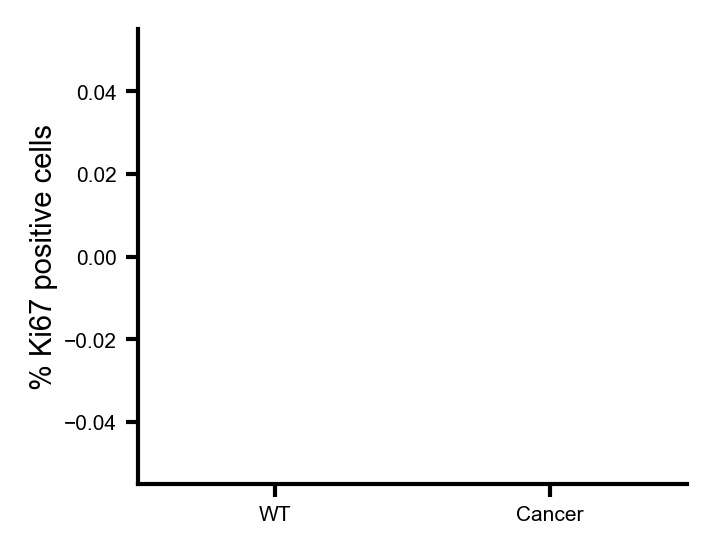

                         wt_cells  crc_cells  ki67_positive  ki67_percentage
phenotype_dendra_vs_tdt                                                     
Dendra                          0       4926              0              0.0
TdT                          7909          0              0              0.0


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\RB007_mix_suspension_ki67_FusionStitcher_F11"

name = os.path.basename(input_directory)
properties = pd.read_csv(os.path.join(input_directory, f"{name}_properties.tsv"), sep="\t")

sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

summary = properties.groupby("phenotype_dendra_vs_tdt").agg(
    wt_cells =("phenotype_dendra_vs_tdt", lambda x: (x == "TdT").sum()),
    crc_cells=("phenotype_dendra_vs_tdt", lambda x: (x == "Dendra").sum()),
    ki67_positive=("ki67_positive", lambda x: (x == "True").sum()),
    ki67_percentage=("ki67_positive", lambda x: (x == "True").sum() / len(x) * 100)
)

pheno       = properties["phenotype_dendra_vs_tdt"].str.lower()
interacting = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

properties["interacting_wt"]      =  interacting & (pheno == "tdt")
properties["non_interacting_wt"]  = ~interacting & (pheno == "tdt")
properties["interacting_crc"]     =  interacting & (pheno == "dendra")
properties["non_interacting_crc"] = ~interacting & (pheno == "dendra")

summary_ki67 = properties.groupby("ki67_positive").agg(
    total_cells=("ki67_positive", "count"),
    wt_cells =("phenotype_dendra_vs_tdt", lambda x: (x == "TdT").sum()),
    crc_cells=("phenotype_dendra_vs_tdt", lambda x: (x == "Dendra").sum()),
    interacting_wt      =("interacting_wt", "sum"),
    non_interacting_wt  =("non_interacting_wt", "sum"),
    interacting_crc     =("interacting_crc", "sum"),
    non_interacting_crc =("non_interacting_crc", "sum"),
).reset_index()

summary_ki67["percent_interacting_wt"]  = summary_ki67["interacting_wt"]  / summary_ki67["wt_cells"]  * 100
summary_ki67["percent_interacting_crc"] = summary_ki67["interacting_crc"] / summary_ki67["crc_cells"] * 100

print(summary_ki67)

fig, ax = plt.subplots(figsize=(60/25.4, 50/25.4), dpi=300)
sns.barplot(
    data=summary,
    x="phenotype_dendra_vs_tdt",
    y="ki67_percentage",
    order=["TdT", "Dendra"],
    hue="phenotype_dendra_vs_tdt",
    palette={"TdT": "magenta", "Dendra": "#319b31"},
    ax=ax
)
ax.tick_params(axis="both", which="major", bottom=True, left=True, size=3)
ax.set_xticklabels(["WT", "Cancer"])
ax.set_ylabel("% Ki67 positive cells")
ax.set_xlabel("")
plt.show()
print(summary)

In [149]:
properties["interacting"] = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

ki67_by_interaction = (
    properties.assign(ki67=properties["phenotype_ki67_vs_dapi"].eq("ki67"))
    .groupby(["phenotype_crc_vs_wt", "interacting"], as_index=False)
    .agg(n_cells=("ki67", "size"), ki67_positive=("ki67", "sum"))
)
ki67_by_interaction["ki67_percentage"] = (
    ki67_by_interaction["ki67_positive"] / ki67_by_interaction["n_cells"] * 100
)

print(ki67_by_interaction)

  phenotype_crc_vs_wt  interacting  n_cells  ki67_positive  ki67_percentage
0                 crc        False     1438            381        26.495132
1                 crc         True     3968           1989        50.126008
2                  wt        False     6510             75         1.152074
3                  wt         True     2038            411        20.166830


C:\Users\6331823\AppData\Local\Temp\ipykernel_44900\2590306737.py:11: DtypeWarning: Columns (31,33,35) have mixed types. Specify dtype option on import or set low_memory=False.
  properties = pd.read_csv(os.path.join(input_directory, f"full_data.tsv"), sep="\t")
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\6331823\AppData\Local\Temp\ipykernel_44900\2590306737.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["WT", "Cancer"])
C:\Users\6331823\AppData\Local\Temp\ipykernel_44900\2590306737.py:147: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(


wt: n=10 pairs, t=1.177, p=0.2693
crc: n=10 pairs, t=-3.549, p=0.006225


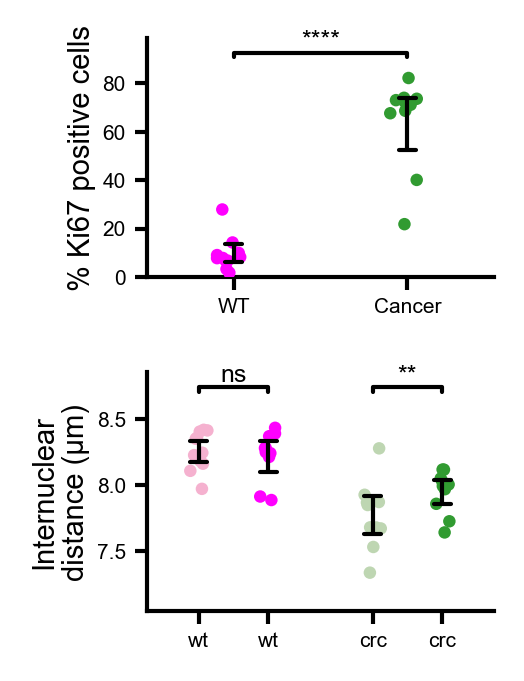

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\microtissues"

name = os.path.basename(input_directory)
properties = pd.read_csv(os.path.join(input_directory, f"full_data.tsv"), sep="\t")
# properties = pd.read_csv(os.path.join(input_directory,"RB007_mix_suspension_ki67_F11", f"RB007_mix_suspension_ki67_F11_properties.tsv"), sep="\t")
properties["log_ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity"] = np.log10(
    properties["ki67_background_subtracted_mean_intensity"] / properties["dapi_background_subtracted_mean_intensity"]
)
threshold = -0.2
properties["phenotype_ki67_vs_dapi"] = np.where(
    properties["log_ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity"] > threshold, "ki67", "dapi"
)

sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
        "axes.labelpad": 1.5,  # space between axis and label
        "lines.linewidth": 1,  
        "axes.linewidth": 1,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

properties["interacting"] = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1
summary = properties.groupby(["phenotype_crc_vs_wt", "sample"]).agg(
    wt_cells =("phenotype_crc_vs_wt", lambda x: (x == "wt").sum()),
    crc_cells=("phenotype_crc_vs_wt", lambda x: (x == "crc").sum()),
    ki67_positive=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum()),
    ki67_percentage=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum() / len(x) * 100),
    density=("mean_distance_1_knn", "mean")
).reset_index()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(38/25.4, 63/25.4), 
                         dpi=300, gridspec_kw={"height_ratios": [1, 1], "hspace":0.4}) # gridspec_kw={"width_ratios": [0.5, 1], "wspace":0.8}
sns.stripplot(
    data=summary,
    x="phenotype_crc_vs_wt",
    y="ki67_percentage",
    order=["wt", "crc"],
    hue="phenotype_crc_vs_wt",
    palette={"wt": "magenta", "crc": "#319b31"},
    size=3,
    jitter=0.1,
    ax=axes[0]
)
sns.pointplot(
    data=summary,
    x="phenotype_crc_vs_wt",
    y="ki67_percentage",
    order=["wt", "crc"],
    color="black",
    markersize=0,
    capsize=0.1,
    linewidth=0,
    err_kws={"linewidth": 1, "color": "black"},
    zorder=10,
    ax=axes[0]
)

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
def add_bracket(ax, x1, x2, text, y=0.92, barh=0.02, fontsize=6):
    """Significance bracket. y/barh are axes fractions, so data limits are untouched."""
    if not text:
        return
    xlim = ax.get_xlim()                      # categorical padding, e.g. (-0.5, 1.5)
    trans = ax.get_xaxis_transform()          # x: data, y: axes fraction
    ax.plot([x1, x1, x2, x2], [y, y + barh, y + barh, y],
            color="black", lw=1, transform=trans, clip_on=False)
    ax.text((x1 + x2) / 2, y + barh, text, ha="center", va="bottom",
            fontsize=fontsize, transform=trans)
    ax.set_xlim(xlim)                         # undo the autoscale

wt_values = summary[summary["phenotype_crc_vs_wt"] == "wt"]["ki67_percentage"]
crc_values = summary[summary["phenotype_crc_vs_wt"] == "crc"]["ki67_percentage"]
# do a simple t test to compare the two groups
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(wt_values, crc_values, equal_var=False)

y_max = max(summary["ki67_percentage"])
axes[0].set_ylim(0, y_max*1.2)
# axes[0].text(0.5, y_max * 1.1, sig_text, ha="center", va="bottom", fontsize=6)
add_bracket(axes[0], 0, 1, significance_text(p_value))
axes[0].set_ylabel("% Ki67 positive cells")
axes[0].set_xticklabels(["WT", "Cancer"])

summary = properties.groupby(["phenotype_crc_vs_wt", "sample", "interacting"]).agg(
    wt_cells =("phenotype_crc_vs_wt", lambda x: (x == "wt").sum()),
    crc_cells=("phenotype_crc_vs_wt", lambda x: (x == "crc").sum()),
    ki67_positive=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum()),
    ki67_percentage=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum() / len(x) * 100),
    density=("mean_distance_1_KNN", "mean")
).reset_index()

palettes = {
    "wt":    {False: "#f5b1cf", True: "magenta"},
    "crc": {False: "#bed6b2", True: "#319b31"},
}
ORDER, HUE_ORDER, DODGE = ["wt", "crc"], [False, True], 0.4

for phenotype, palette in palettes.items():
    sub = summary[summary["phenotype_crc_vs_wt"] == phenotype]
    sns.stripplot(
        data=sub, x="phenotype_crc_vs_wt", y="density",
        order=ORDER, hue="interacting", hue_order=HUE_ORDER,
        palette=palette, size=3, jitter=0.1, dodge=DODGE,
        legend=False, ax=axes[1],
    )
sns.pointplot(
    data=summary,
    x="phenotype_crc_vs_wt",
    y="density",
    order=["wt", "crc"],
    hue="interacting",
    hue_order=HUE_ORDER,
    color="black",
    markersize=0,
    capsize=0.1,
    linewidth=0,
    err_kws={"linewidth": 1, "color": "black"},
    zorder=10,
    ax=axes[1],
    dodge=DODGE,
    legend=False
)

axes[1].set_ylabel("Internuclear\ndistance (µm)")
from matplotlib.lines import Line2D

n = len(HUE_ORDER)
offsets = (np.arange(n) - (n - 1) / 2) * DODGE 

ticks, labels = [], []
for i, phenotype in enumerate(ORDER):
    if phenotype == "wt":
        name = "WT"
    else:
        name = "Cancer"
    for j, interacting in enumerate(HUE_ORDER):
        ticks.append(i + offsets[j])
        labels.append(f"{name} int" if interacting else f"{name} non-int")

axes[1].set_xticks(ticks)
# axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_xlabel("")
ymax = max(summary["density"])
ymin = min(summary["density"])
axes[1].set_ylim(ymin * 0.96, ymax * 1.05)
# x positions of the four clusters (same offsets used for the ticks)
positions = {(p, i): x + offsets[j]
             for x, p in enumerate(ORDER)
             for j, i in enumerate(HUE_ORDER)}
from scipy.stats import ttest_rel
for phenotype in ORDER:
    sub = summary[summary["phenotype_crc_vs_wt"] == phenotype]
    paired = sub.pivot(index="sample", columns="interacting", values="density").dropna()
    if len(paired) < 2:
        continue
    t_stat, p_value = ttest_rel(paired[False], paired[True])
    add_bracket(
        axes[1],
        positions[(phenotype, False)],
        positions[(phenotype, True)],
        significance_text(p_value),
        y=0.92,
    )
    print(f"{phenotype}: n={len(paired)} pairs, t={t_stat:.3f}, p={p_value:.4g}")

for ax in axes:
    ax.tick_params(axis="both", which="major", bottom=True, left=True, size=3)
    ax.set_xlabel("")

# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
plt.savefig(os.path.join(output_directory, f"microtissue_plot.eps"), dpi=600, bbox_inches="tight")
plt.show()

ki67_percentage / wt: n=10 pairs, t=-6.595, p=9.985e-05
ki67_percentage / crc: n=10 pairs, t=6.455, p=0.0001175
density / wt: n=10 pairs, t=1.177, p=0.2693
density / crc: n=10 pairs, t=-3.549, p=0.006225


C:\Users\6331823\AppData\Local\Temp\ipykernel_44900\3788135443.py:36: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\6331823\AppData\Local\Temp\ipykernel_44900\3788135443.py:36: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(


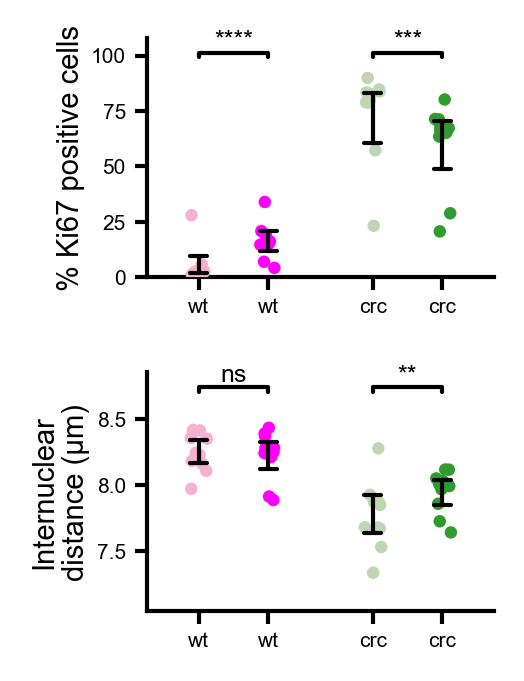

In [2]:
properties["interacting"] = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

summary = properties.groupby(["phenotype_crc_vs_wt", "sample", "interacting"]).agg(
    wt_cells=("phenotype_crc_vs_wt", lambda x: (x == "wt").sum()),
    crc_cells=("phenotype_crc_vs_wt", lambda x: (x == "crc").sum()),
    ki67_positive=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum()),
    ki67_percentage=("phenotype_ki67_vs_dapi", lambda x: (x == "ki67").sum() / len(x) * 100),
    density=("mean_distance_1_KNN", "mean"),
).reset_index()

palettes = {
    "wt":  {False: "#f5b1cf", True: "magenta"},
    "crc": {False: "#bed6b2", True: "#319b31"},
}
ORDER, HUE_ORDER, DODGE = ["wt", "crc"], [False, True], 0.4
offsets = (np.arange(len(HUE_ORDER)) - (len(HUE_ORDER) - 1) / 2) * DODGE
positions = {(p, i): x + offsets[j]
             for x, p in enumerate(ORDER)
             for j, i in enumerate(HUE_ORDER)}
ticks = [positions[(p, i)] for p in ORDER for i in HUE_ORDER]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(38/25.4, 63/25.4),
                         dpi=300, gridspec_kw={"height_ratios": [1, 1], "hspace": 0.4})

from scipy.stats import ttest_rel

def split_panel(ax, value, ylabel, ylim):
    for phenotype, palette in palettes.items():
        sub = summary[summary["phenotype_crc_vs_wt"] == phenotype]
        sns.stripplot(
            data=sub, x="phenotype_crc_vs_wt", y=value,
            order=ORDER, hue="interacting", hue_order=HUE_ORDER,
            palette=palette, size=3, jitter=0.1, dodge=DODGE,
            legend=False, ax=ax,
        )
    sns.pointplot(
        data=summary, x="phenotype_crc_vs_wt", y=value,
        order=ORDER, hue="interacting", hue_order=HUE_ORDER,
        color="black", markersize=0, capsize=0.1, linewidth=0,
        err_kws={"linewidth": 1, "color": "black"},
        zorder=10, dodge=DODGE, legend=False, ax=ax,
    )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticks(ticks)
    ax.set_ylim(*ylim)

    for phenotype in ORDER:
        sub = summary[summary["phenotype_crc_vs_wt"] == phenotype]
        paired = sub.pivot(index="sample", columns="interacting", values=value).dropna()
        if len(paired) < 2:
            continue
        t_stat, p_value = ttest_rel(paired[False], paired[True])
        add_bracket(ax, positions[(phenotype, False)], positions[(phenotype, True)],
                    significance_text(p_value), y=0.92)
        print(f"{value} / {phenotype}: n={len(paired)} pairs, t={t_stat:.3f}, p={p_value:.4g}")

split_panel(axes[0], "ki67_percentage", "% Ki67 positive cells",
            (0, summary["ki67_percentage"].max() * 1.2))
split_panel(axes[1], "density", "Internuclear\ndistance (µm)",
            (summary["density"].min() * 0.96, summary["density"].max() * 1.05))

for ax in axes:
    ax.tick_params(axis="both", which="major", bottom=True, left=True, size=3)
    ax.set_xlabel("")


In [5]:
# print(summary)
# get mean and sd of the ki67_percentage for each group
ki67_stats = summary.groupby(["phenotype_crc_vs_wt"]).agg(
    mean_ki67_percentage=("ki67_percentage", "mean"),
    sd_ki67_percentage=("ki67_percentage", "std"),
    n_samples=("ki67_percentage", "count")
).reset_index()
print(ki67_stats)

  phenotype_crc_vs_wt  mean_ki67_percentage  sd_ki67_percentage  n_samples
0                 crc             67.257205           20.439738         20
1                  wt             10.017332            9.781958         21


In [125]:
print(properties.columns)

Index(['sample', 'label', 'z_pixel', 'y_pixel', 'x_pixel', 'bounding_box',
       'volume', 'z', 'y', 'x', 'dapi_raw_mean_intensity',
       'dapi_background_subtracted_mean_intensity', 'crc_raw_mean_intensity',
       'crc_background_subtracted_mean_intensity', 'wt_raw_mean_intensity',
       'wt_background_subtracted_mean_intensity', 'ki67_raw_mean_intensity',
       'ki67_background_subtracted_mean_intensity', 'timepoint', 'time',
       'ratio_crc_background_subtracted_mean_intensity_wt_background_subtracted_mean_intensity',
       'log_ratio_crc_background_subtracted_mean_intensity_wt_background_subtracted_mean_intensity',
       'phenotype_crc_vs_wt', 'mean_distance_1_KNN', 'neighbours_1_KNN',
       'touching_neighbour_5um_neighbours', 'touching_neighbour_5um_count',
       'mean_distance_touching_neighbour_5um',
       'phenotype_similarity_ratio_touching_neighbour_5um',
       'ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity',
       '

In [130]:
display(summary)

,phenotype_crc_vs_wt,sample,interacting,wt_cells,crc_cells,ki67_positive,ki67_percentage,density
0,crc,RB007_mix_suspension_ki67_F11,False,0,2658,614,23.100075,NaN
1,crc,RB007_mix_suspension_ki67_F11,True,0,2748,565,20.560408,NaN
2,crc,RB007_mix_suspension_ki67_F12,False,0,1024,920,89.843750,NaN
3,crc,RB007_mix_suspension_ki67_F12,True,0,3795,3041,80.131752,NaN
4,crc,RB007_mix_suspension_ki67_F13,False,0,1020,850,83.333333,7.871033
5,crc,RB007_mix_suspension_ki67_F13,True,0,2687,1787,66.505396,7.992795
6,crc,RB007_mix_suspension_ki67_FusionStitcher_F10,False,0,1495,855,57.190635,NaN
7,crc,RB007_mix_suspension_ki67_FusionStitcher_F10,True,0,2256,649,28.767730,NaN
8,crc,RB007_mix_suspension_ki67_FusionStitcher_F15,False,0,2104,1657,78.754753,NaN
9,crc,RB007_mix_suspension_ki67_FusionStitcher_F15,True,0,6045,3938,65.144748,NaN


In [10]:
import pandas as pd
import os
import numpy as np
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
properties = pd.read_csv(os.path.join(input_directory, f"ruth_data.tsv"), sep="\t")
properties = pd.read_csv(os.path.join(input_directory,"microtissues", "RB007_mix_suspension_ki67_F11", f"RB007_mix_suspension_ki67_F11_properties.tsv"), sep="\t")
properties["interacting"] = properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1

threshold = -0.6
properties["log_ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity"] = np.log10(
    properties["ki67_background_subtracted_mean_intensity"] / properties["dapi_background_subtracted_mean_intensity"]
)
properties["phenotype_ki67_vs_dapi"] = np.where(
    properties["log_ratio_ki67_background_subtracted_mean_intensity_dapi_background_subtracted_mean_intensity"] > threshold, "ki67", "dapi"
)
# properties["phenotype_crc_vs_wt"] = properties["phenotype_Dendra_vs_TdT"].map({"Dendra": "crc", "TdT": "wt"})
# properties = properties[properties["sample"] == "RB007_mix_suspension_ki67_FusionStitcher_F11"]

ki67_by_interaction = (
    properties.assign(ki67=properties["phenotype_ki67_vs_dapi"].eq("ki67"))
    .groupby(["phenotype_crc_vs_wt", "interacting", "sample"], as_index=False)
    .agg(n_cells=("ki67", "size"), ki67_positive=("ki67", "sum"))
)
ki67_by_interaction["ki67_percentage"] = (
    ki67_by_interaction["ki67_positive"] / ki67_by_interaction["n_cells"] * 100
)

display(ki67_by_interaction)

,phenotype_crc_vs_wt,interacting,sample,n_cells,ki67_positive,ki67_percentage
0,crc,False,RB007_mix_suspension_ki67_F11,2658,1278,48.081264
1,crc,True,RB007_mix_suspension_ki67_F11,2748,1092,39.737991
2,wt,False,RB007_mix_suspension_ki67_F11,5436,75,1.379691
3,wt,True,RB007_mix_suspension_ki67_F11,3112,411,13.206941


New zebrafish brain data

In [8]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile
from skimage.transform import resize
from scipy import ndimage

input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
names = ["40x WIS zstack DAPI midbrain.TIF"]

scale = (1, 0.1678, 0.1678)  # in micrometers


# load cp-sam foundation model
from cellpose import models
model = models.CellposeModel(model_type="cpsam_v2", gpu=True)
results = []
for name in names:
    image = tifffile.imread(os.path.join(input_directory, name))

    # start_time = time.time()
    # mask = segment(image, model)
    # # tifffile.imwrite(
    # #     os.path.join(input_directory, "2d_segmented_degraded.tif"),
    # #     mask,
    # #     compression="zlib",
    # #     compressionargs={"level": 8},
    # # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented.tif"))
    # segmentation_time = time.time() - start_time
    # start_stitch_time = time.time()
    # nuclogic = stitch_3d(
    #     mask,
    #     image,
    #     image_type_1="wt",
    #     breaking_threshold=3,
    #     scale=scale
    # )
    # end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    # nuclogic_stitch_time = end_time - start_stitch_time

    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_degraded.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    # nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_rescaled.tif"))

    # nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    # print(f"centroid accuracy: {nuclogic_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    # )

    # print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    # print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    # print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    # start_cp4 = time.time()
    # cp4,_,_ = model.eval(
    #                 image,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0,
    #                 min_size=150,
    #                 progress=True,
    #             )
    # end_cp4 = time.time()
    # cp4_time = end_cp4 - start_cp4

    ground_truth = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4.tif"))
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds.")

    start_usegment = time.time()
    usegment = usegment_stitch(mask)
    end_usegment = time.time()
    usegment_time = end_usegment - start_usegment

    print(f"Usegment completed in {usegment_time:.2f} seconds.")

    tifffile.imwrite(
        os.path.join(input_directory, f"3d_segmented_usegment.tif"),
        usegment,
        compression="zlib",
        compressionargs={"level": 8},
    )
    usegment = tifffile.imread(os.path.join(input_directory, f"3d_segmented_usegment.tif")).astype(np.uint16)

    print(ground_truth.shape, usegment.shape)
    usegement_results = centroid_accuracy(ground_truth, usegment)
    print(f"centroid accuracy: {usegement_results}")

    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_cp4_degraded.tif"),
    #     cp4,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # cp4_results = (centroid_accuracy(ground_truth, cp4))
    # print(f"centroid accuracy: {cp4_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    # )
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    # print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # save results of centroid accuracy and amount of cells to a tsv file

    # results_df = pd.DataFrame(
    #     {
    #         "method": ["nuclogic", "cellpose4"],
    #         "f1": [nuclogic_results["f1"], cp4_results["f1"]],
    #         "precision": [nuclogic_results["precision"], cp4_results["precision"]],
    #         "recall": [nuclogic_results["recall"], cp4_results["recall"]],
    #         "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
    #         "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
    #         "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
    #         "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
    #         "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
    #         "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
    #         "total_time": [nuclogic_time, cp4_time],
    #         "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
    #         "stitching_time": [nuclogic_stitch_time, 0],
    #     }
    # )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# results_df.to_csv(os.path.join(output_directory, "emmanuel_results_rescaled.tsv"), sep="\t", index=False)

Automatric binary thresholding:  0.8


100%|██████████| 200/200 [1:09:22<00:00, 20.81s/it]


Usegment completed in 4399.17 seconds.
(101, 2048, 2048) (101, 2048, 2048)
centroid accuracy: {'true_positives': 14697, 'false_negatives': 1218, 'false_positives': 30251, 'merged_cells': 885, 'precision': 0.32697784106078137, 'recall': 0.9234684260131951, 'f1': 0.4829535185580731, 'voxel_dice': 0.9767045356995429, 'tp_list': [32768, 1, 2, 4, 32773, 32772, 32777, 10, 11, 32784, 32788, 22, 23, 32792, 25, 26, 32795, 28, 29, 32797, 32791, 32, 34, 36, 32805, 38, 39, 40, 43, 32813, 47, 32815, 49, 50, 32817, 32821, 54, 55, 32823, 57, 32826, 59, 32825, 32829, 32827, 65, 32834, 67, 68, 69, 32835, 32837, 32840, 74, 32842, 76, 32845, 78, 79, 32848, 81, 86, 87, 88, 32855, 90, 32856, 92, 93, 94, 95, 32863, 32864, 32865, 32861, 100, 101, 32868, 103, 32866, 32867, 32874, 108, 110, 32880, 113, 32881, 116, 117, 118, 119, 120, 121, 32885, 32889, 124, 125, 126, 127, 128, 129, 32898, 131, 132, 32900, 134, 135, 32905, 138, 32906, 32911, 32912, 145, 32913, 32916, 150, 32920, 154, 156, 157, 32926, 32927, 329

In [10]:
print(centroid_accuracy(ground_truth[:, 300:, :], usegment[:, 300:, :]))

{'true_positives': 12952, 'false_negatives': 1012, 'false_positives': 25699, 'merged_cells': 771, 'precision': 0.3351012910403353, 'recall': 0.9275279289601833, 'f1': 0.49233108429155187, 'voxel_dice': 0.9776427197351154, 'tp_list': [32768, 32772, 32773, 32777, 32784, 32788, 32791, 32792, 32795, 32797, 32805, 32813, 32815, 32817, 32821, 32823, 32825, 32826, 32827, 32829, 32834, 32835, 32837, 32840, 32842, 32845, 32848, 32855, 32856, 32857, 32861, 32863, 32864, 32865, 32866, 32867, 32868, 32874, 32880, 32881, 32885, 32887, 32888, 32889, 32898, 32900, 32905, 32906, 32965, 32975, 32980, 32985, 218, 32988, 223, 226, 227, 32996, 229, 32998, 232, 234, 33002, 33004, 241, 242, 243, 33009, 245, 33010, 247, 248, 249, 33011, 33018, 252, 253, 254, 33023, 33022, 257, 258, 262, 263, 264, 33034, 267, 33035, 33038, 272, 273, 33044, 278, 279, 280, 33046, 282, 33051, 284, 288, 290, 33059, 33058, 33061, 33063, 296, 33065, 33066, 33064, 301, 302, 33070, 304, 305, 33072, 307, 33076, 33075, 33071, 33078, 33

In [ ]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile
from skimage.transform import resize
from scipy import ndimage

input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
names = ["40x WIS zstack DAPI midbrain.TIF"]

scale = (1, 0.1678, 0.1678)  # in micrometers
rescale_factor = 0.5

def degrade_image(image, bottom=0.05):
    depth = np.linspace(0.0, 1.0, image.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
    sqrt_part = 1.0 - (1.0 - bottom) * np.sqrt(depth)
    d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
    sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
    factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
    z_profile = (sqrt_part * factor)[:, None, None]
    image_degraded = image * z_profile
    return image_degraded

# model = load_model(
#     os.path.join(input_directory, "model","models", "zebrafish_lightsheet")
# )
# load cp-sam foundation model
from cellpose import models
model = models.CellposeModel(model_type="cpsam_v2", gpu=True)
results = []
for name in names:
    # image = tifffile.imread(os.path.join(input_directory, name))
    # image = resize(image, (int(image.shape[0] * rescale_factor), int(image.shape[1] * rescale_factor), int(image.shape[2] * rescale_factor)), order=1)  # rescale 
    # image = degrade_image(image, bottom=0.05)
    # image = (image / np.percentile(image, 99.8) * 255).astype(np.uint8)
    
    # start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented_degraded.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_degraded.tif"))
    # segmentation_time = time.time() - start_time


    start_stitch_time = time.time()
    nuclogic = stitch_3d(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=3,
        scale=scale
    )
    end_time = time.time()
    nuclogic_time = end_time - start_time
    nuclogic_cellpose_time = start_stitch_time - start_time
    nuclogic_stitch_time = end_time - start_stitch_time

    ground_truth = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4.tif"))
    nuclogic = resize(nuclogic, ground_truth.shape, order=0)  # rescale back to original size
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_degraded.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_degraded.tif"))

    nuclogic_results = (centroid_accuracy(ground_truth[:, 300:, :], nuclogic[:, 300:, :]))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )

    print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")

    

    # start_cp4 = time.time()
    # cp4,_,_ = model.eval(
    #                 image,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0,
    #                 min_size=150,
    #                 progress=True,
    #             )
    # end_cp4 = time.time()
    # cp4_time = end_cp4 - start_cp4
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds.")

    # cp4 = resize(cp4, ground_truth.shape, order=0)  # rescale back to original size
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_cp4_degraded.tif"),
    #     cp4,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # cp4_results = (centroid_accuracy(ground_truth, cp4))
    # print(f"centroid accuracy: {cp4_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    # )
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    # print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # start_usegment = time.time()
    # # usegment = usegment_stitch(segmented_2d)
    # end_usegment = time.time()
    # usegment = tifffile.imread(os.path.join(input_directory, "3d_segmented_usegment_degraded.tif"))
    # usegment_time = end_usegment - start_usegment

    # print(f"Usegment completed in {usegment_time:.2f} seconds.")

    # usegment = resize(usegment, ground_truth.shape, order=0)
    # tifffile.imwrite(
    #     os.path.join(input_directory, f"3d_segmented_usegment_degraded.tif"),
    #     usegment,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    # usegment = tifffile.imread(os.path.join(input_directory, f"3d_segmented_usegment_degraded.tif")).astype(np.uint16)

    # usegment_results = centroid_accuracy(ground_truth[:, 300:, :], usegment[:, 300:, :])
    # print(f"centroid accuracy: {usegment_results}")
    # save results of centroid accuracy and amount of cells to a tsv file

    # results_df = pd.DataFrame(
    #     {
    #         "method": ["nuclogic", "cellpose4"],
    #         "f1": [nuclogic_results["f1"], cp4_results["f1"]],
    #         "precision": [nuclogic_results["precision"], cp4_results["precision"]],
    #         "recall": [nuclogic_results["recall"], cp4_results["recall"]],
    #         "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
    #         "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
    #         "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
    #         "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
    #         "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
    #         "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
    #         "total_time": [nuclogic_time, cp4_time],
    #         "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
    #         "stitching_time": [nuclogic_stitch_time, 0],
    #     }
    # )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# results_df.to_csv(os.path.join(output_directory, "emmanuel_results_rescaled.tsv"), sep="\t", index=False)

centroid accuracy: {'true_positives': 12918, 'false_negatives': 1046, 'false_positives': 437, 'merged_cells': 695, 'precision': 0.9672781729689255, 'recall': 0.9250930965339444, 'f1': 0.9457154361433434, 'voxel_dice': 0.9626750576511153, 'tp_list': [180, 184, 188, 191, 192, 193, 194, 195, 196, 198, 202, 203, 204, 205, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 233, 234, 235, 236, 237, 240, 241, 242, 243, 244, 245, 246, 249, 250, 251, 252, 253, 254, 255, 259, 260, 261, 262, 263, 265, 266, 267, 268, 269, 270, 271, 273, 274, 275, 276, 278, 280, 282, 283, 284, 285, 287, 288, 289, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 313, 314, 315, 316, 317, 318, 320, 321, 322, 323, 324, 325, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 359, 360, 361, 362, 363, 364, 

In [18]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile
from skimage.transform import resize
from scipy import ndimage
from utils.test import stitch_3d_iom

input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
name = "40x WIS zstack DAPI midbrain.TIF"
tests = ["new"]

scale = (1, 0.1678, 0.1678)  # in micrometers
rescale_factor = 0.5

# image = tifffile.imread(os.path.join(input_directory, name))
# image = resize(image, (int(image.shape[0] * rescale_factor), int(image.shape[1] * rescale_factor), int(image.shape[2] * rescale_factor)), order=1)  # rescale 
# image = degrade_image(image, bottom=0.05)
# image = (image / np.percentile(image, 99.8) * 255).astype(np.uint8)

def degrade_image(image, bottom=0.05):
    depth = np.linspace(0.0, 1.0, image.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
    sqrt_part = 1.0 - (1.0 - bottom) * np.sqrt(depth)
    d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
    sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
    factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
    z_profile = (sqrt_part * factor)[:, None, None]
    image_degraded = image * z_profile
    return image_degraded

from cellpose import models
model = models.CellposeModel(model_type="cpsam_v2", gpu=True)
results = []
for test in tests:
    print(f"Running test: {test}")

    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_degraded.tif"))
    start_stitch_time = time.time()
    nuclogic = stitch_3d_iom(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=3,
        scale=scale
    )
    end_time = time.time()
    nuclogic_stitch_time = end_time - start_stitch_time

    ground_truth = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4.tif"))
    nuclogic = resize(nuclogic, ground_truth.shape, order=0)  # rescale back to original size

    nuclogic_results = (centroid_accuracy(ground_truth[:, 300:, :], nuclogic[:, 300:, :]))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")


    

   

Running test: new
Starting 3D stitching process...
Created 72796 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 8184 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 3703 breaks.
    Iteration 2: Made 2523 breaks.
    Iteration 3: Made 1129 breaks.
    Iteration 4: Made 363 breaks.
    Iteration 5: Made 80 breaks.
    Iteration 6: Made 16 breaks.
    Iteration 7: Made 1 breaks.
Finding touching cell pairs...
Found 14647 pairs of touching cells.
Splitted 15456 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 621 small cells, and removed 325 cells without suitable neighbors.
Final stitched mask has 15053 cells.
centroid accuracy: {'true_positives': 12985, 'false_negatives': 979, 'false_positives': 431, 'merged_cells': 645, 'precision': 0.9678741800834824, 'recall': 0.9298911486680035, 'f1': 0.9485025566106647, 'voxel_dice': 0.9638009354667739, 'tp_list': [

In [11]:
print(len(np.unique(nuclogic)) - 1)

15002


In [9]:
import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize
from skimage.transform import resize


input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
names = ["40x WIS zstack DAPI midbrain.TIF"]

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0, 1, 2)  # normalize over all axes
rescale_factor = 0.5

for name in names:
    image = tifffile.imread(os.path.join(input_directory, name))
    gt = tifffile.imread(os.path.join(input_directory, f"3d_segmented_cp4.tif"))
    # time_start = time()
    # img = normalize(image, 1,99.8, axis=axis_norm)
    # stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    # time_end = time()
    # star_time = time_end - time_start
    # tifffile.imwrite(os.path.join(input_directory, f"3d_segmented_stardist.tif"), stardist.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    # print(f"stardist time: {star_time:.2f}s")
    # stardist_results = centroid_accuracy(gt[:, 300:, :], stardist[:, 300:, :])
    # print(f"StarDist3D centroid accuracy: {stardist_results['f1']:.4f}")

    print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

    def degrade_image(image, bottom=0.05):
        depth = np.linspace(0.0, 1.0, image.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
        sqrt_part = 1.0 - (1.0 - bottom) * np.sqrt(depth)
        d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
        sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
        factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
        z_profile = (sqrt_part * factor)[:, None, None]
        image_degraded = image * z_profile
        return image_degraded
    degraded_image = resize(image, (int(image.shape[0] * rescale_factor), int(image.shape[1] * rescale_factor), int(image.shape[2] * rescale_factor)), order=1)  # rescale 
    degraded_image = degrade_image(degraded_image, bottom=0.05)

    time_start = time()
    degraded_image = normalize(degraded_image, 1,99.8, axis=0)
    stardist, details = model.predict_instances(degraded_image, n_tiles=model._guess_n_tiles(degraded_image))
    time_end = time()
    star_time = time_end - time_start
    stardist = resize(stardist, gt.shape, order=0)  # rescale back to original size
    tifffile.imwrite(os.path.join(input_directory, f"3d_segmented_stardist_degraded.tif"), stardist.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt[:, 300:, :], stardist[:, 300:, :])
    print(f"StarDist3D centroid accuracy: {stardist_results['f1']:.4f}")

    print(f"StarDist3D f1 {stardist_results['f1']:.4f}")


Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
StarDist3D f1 0.1889


100%|██████████| 81/81 [00:31<00:00,  2.55it/s]


stardist time: 75.59s
StarDist3D centroid accuracy: 0.2111
StarDist3D f1 0.2111


Mean Z height for: 14.37
Mean Y size for: 62.18


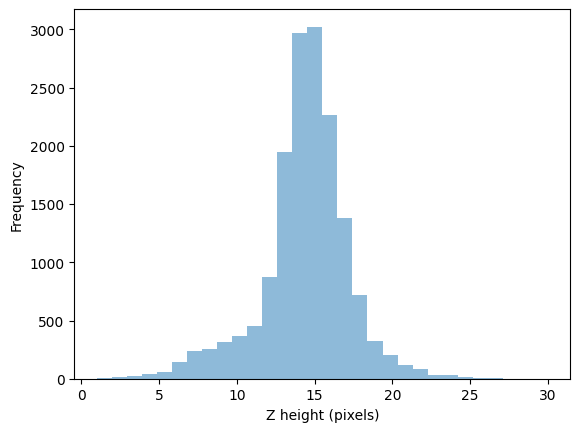

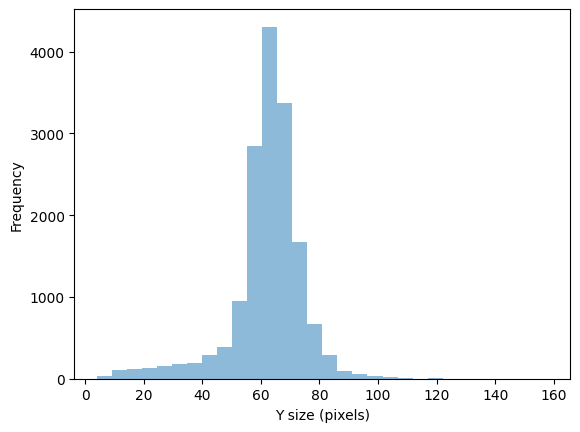

In [13]:
import matplotlib.pyplot as plt

input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
ground_truth = tifffile.imread(os.path.join(input_directory, f"3d_segmented_cp4.tif"))

# get the mean Z height of the ground truth cells
results_z = []
results_y = []
for region in regionprops(ground_truth):
    z_heights = region.bbox[3] - region.bbox[0]
    y_size = region.bbox[4] - region.bbox[1]
    results_z.append(z_heights)
    results_y.append(y_size)
mean_z_height = np.mean(results_z)
mean_y_size = np.mean(results_y)
print(f"Mean Z height for: {mean_z_height:.2f}")
print(f"Mean Y size for: {mean_y_size:.2f}")

plt.hist(results_z, bins=30, alpha=0.5, label="Z height")
plt.ylabel("Frequency")
plt.xlabel("Z height (pixels)")
plt.show()
plt.hist(results_y, bins=30, alpha=0.5, label="Y size")
plt.ylabel("Frequency")
plt.xlabel("Y size (pixels)")
plt.show()


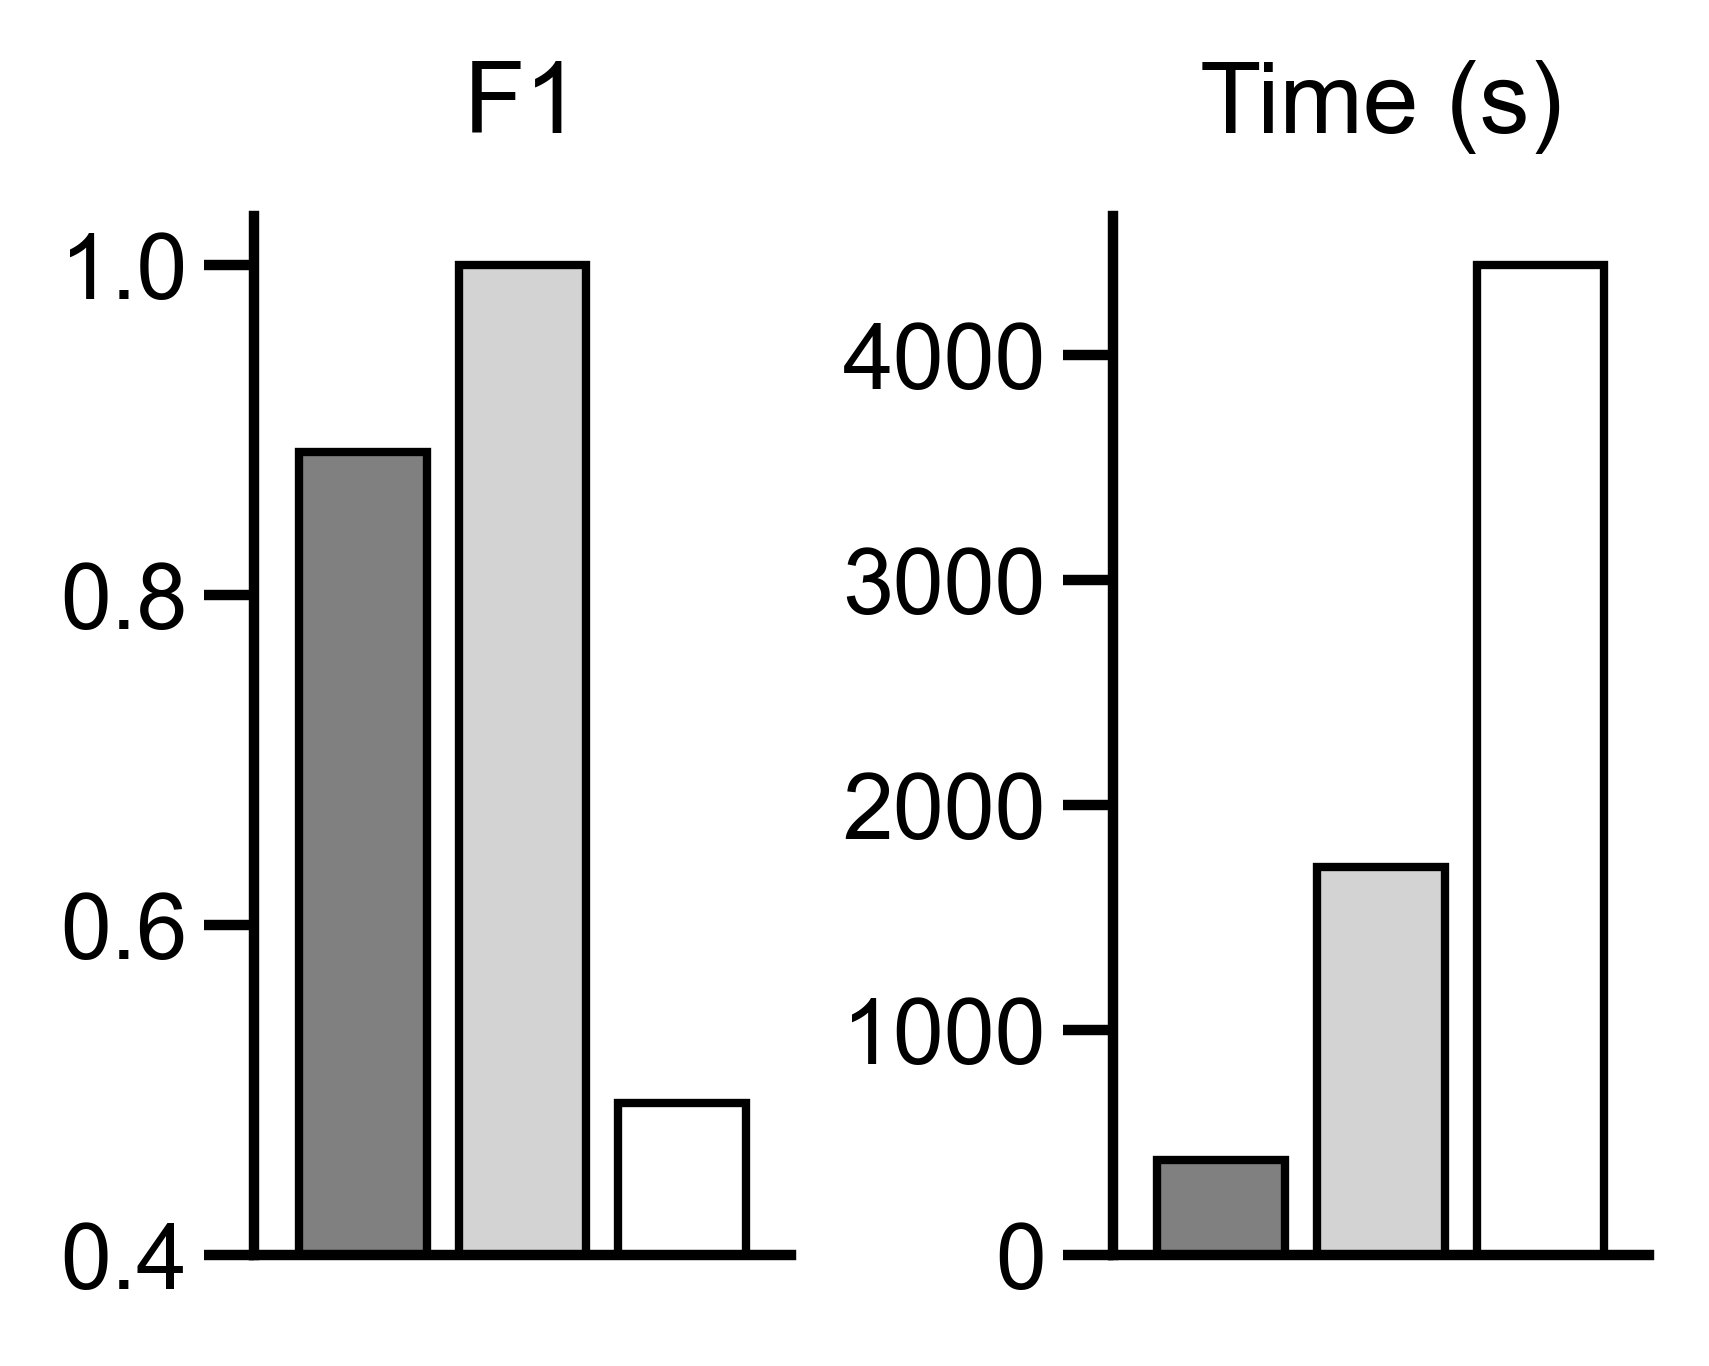

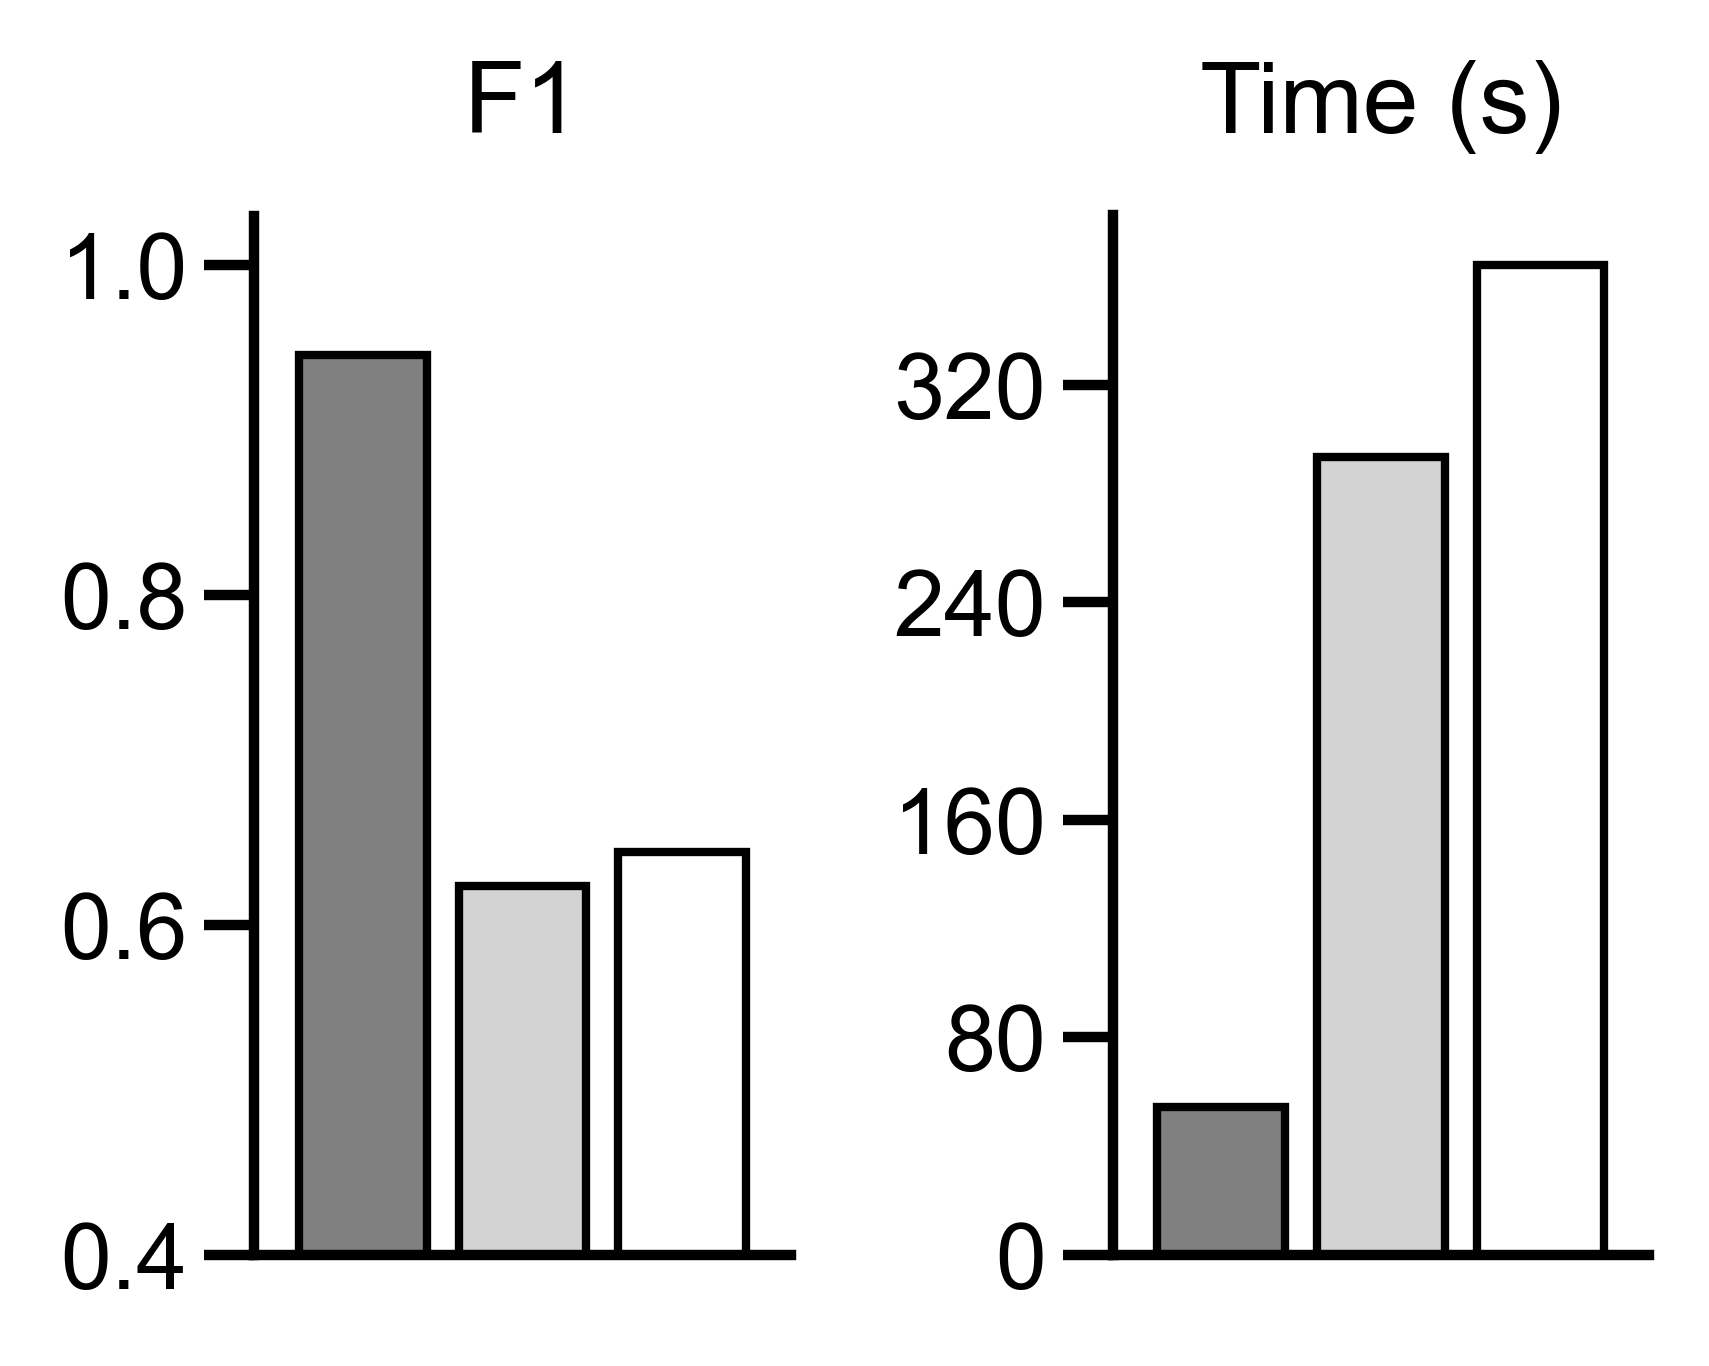

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "emmanuel results new.csv"))
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  
# 
for sample in results["sample"].unique():
    sample_results = results[results["sample"] == sample]                  
    agg = sample_results.groupby("method")[metrics].agg(["mean", "std"])

    x = np.arange(len(methods))          # one group center per method
    color =  "black"

    fig, axes = plt.subplots(
        figsize=(3, 2.25),
        dpi=600,
        ncols=2,
        gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
    )


    for i, metric in enumerate(metrics):
            means = [agg.loc[m, (metric, "mean")] for m in methods]
            sds   = [agg.loc[m, (metric, "std")]  for m in methods]
            axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                    label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars

            axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
            axes[i].set_xticklabels("")
            axes[i].spines["top"].set_visible(False)
            axes[i].spines["right"].set_visible(False)

            axes[i].tick_params(left=True, bottom=False) 
            axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
            axes[i].margins(x=0.1)
            axes[i].set_ylabel("")

        
            if i == 0:
                    axes[i].set_title("F1", pad=10)
                    axes[i].set_ylim(0.4, 1.03)
                    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=4))
            else:
                    axes[i].set_title("Time (s)", pad=10)
                    # axes[i].set_ylim(0, 2500)

    figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
    plt.savefig(os.path.join(figure_folder, f"emmanuel_{sample}.eps"), dpi=600, bbox_inches="tight")
    plt.show()

In [24]:
import napari
import os
import tifffile
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
from skimage.transform import resize
from scipy import ndimage
colormap = cu.label_colormap(num_colors=1024)

# input_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001"
# sample_name = "40x WIS zstack DAPI midbrain"
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"

# image = tifffile.imread(os.path.join(input_directory, sample_name, f"{sample_name}.TIF"))[:, 300:, :]
# cp = tifffile.imread(os.path.join(input_directory, sample_name, f"3d_segmented_cp4.tif"))[:, 300:, :]
# nuclogic = tifffile.imread(os.path.join(input_directory, sample_name, f"3d_segmented_nuclogic.tif"))[:, 300:, :]

# degraded_image = tifffile.imread(os.path.join(input_directory, sample_name, f"{sample_name}_degraded.TIF"))[:, 300:, :]
# degraded_image = resize(degraded_image, image.shape, order=1)  # rescale back to original size
# #renormalize over 255
# degraded_image = (degraded_image / np.percentile(degraded_image, 99.8) * 255).astype(np.uint8)
# cp_degraded = tifffile.imread(os.path.join(input_directory, sample_name, f"3d_segmented_cp4_degraded.tif"))[:, 300:, :]
# nuclogic_degraded = tifffile.imread(os.path.join(input_directory, sample_name, f"3d_segmented_nuclogic_degraded.tif"))[:, 300:, :]

# # calculate window for showing only 1:8th of xy planes
# xy_8 = slice(0, image.shape[1] * 1 // 8)
# xy_8_degraded = slice(0, degraded_image.shape[1] * 1 // 8)
# scale = (0.43, 0.23, 0.23)  # in micrometers
# viewer = napari.Viewer(ndisplay=2)
# # viewer.add_image(image, scale=scale) #contrast_limits=(0, 600) for degraded
# viewer.add_image(image, scale=scale, contrast_limits=(0, 600)) #contrast_limits=(0, 600) for degraded
# viewer.add_labels(gt, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(cp4, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.reset_view()
# # move to z 594
# viewer.dims.set_point(0, 575 * scale[0]) 
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# viewer.grid.enabled = True
# viewer.camera.zoom  = 3
# napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "emmanuel_degraded_slice.png"), size=(2160, 3840), canvas_only=True, scale = 1)

scale = (1, 0.1678, 0.1678)  # in micrometers
viewer = napari.Viewer(ndisplay=3)
# viewer.add_image(image[:, xy_8, :], scale=scale) #contrast_limits=(0, 600) for degraded
# viewer.add_labels(cp[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(nuclogic[:, xy_8, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_image(degraded_image[:, xy_8_degraded, :], scale=scale)
# viewer.add_labels(cp_degraded[:, xy_8_degraded, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# viewer.add_labels(nuclogic_degraded[:, xy_8_degraded, :], scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_image(image, name="Image", scale=scale) #contrast_limits=(0, 600) for degraded
viewer.add_labels(cp, name="CP", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(nuclogic, name="NucLogic", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_image(degraded_image, name="Degraded Image", scale=scale)
viewer.add_labels(cp_degraded, name="CP Degraded", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(nuclogic_degraded, name="NucLogic Degraded", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.grid.enabled = True
viewer.camera.zoom   = 1.5

napari.run()
viewer.screenshot(path=os.path.join(output_directory, "emmanuel_new.png"), size=(2160, 3840), canvas_only=True, scale = 1)

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
# viewer.camera.angles = (180.0, 0.0, 0.0)
viewer.camera.zoom = 4
# adjust brigthness for cp_degraded
limit = np.percentile(degraded_image[50], 99.8)
viewer.layers["Degraded Image"].contrast_limits = [0, limit]
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "emmanuel_new_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1)

# go to XY view and Z 90
viewer.dims.ndisplay = 2
viewer.dims.set_point(0, 90 * scale[0])
viewer.camera.zoom = 7
viewer.screenshot(path=os.path.join(output_directory, "emmanuel_new_slice.png"), size=(2160, 3840), canvas_only=True, scale = 1)



array([[[110, 110, 110, 255],
        [113, 113, 113, 255],
        [113, 113, 113, 255],
        ...,
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255]],

       [[110, 110, 110, 255],
        [113, 113, 113, 255],
        [113, 113, 113, 255],
        ...,
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255]],

       [[110, 110, 110, 255],
        [102, 102, 102, 255],
        [102, 102, 102, 255],
        ...,
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255],
        [ 66, 216, 166, 255]],

       ...,

       [[ 42,  42,  42, 255],
        [ 42,  42,  42, 255],
        [ 42,  42,  42, 255],
        ...,
        [158, 139, 180, 255],
        [158, 139, 180, 255],
        [158, 139, 180, 255]],

       [[ 42,  42,  42, 255],
        [ 42,  42,  42, 255],
        [ 42,  42,  42, 255],
        ...,
        [158, 139, 180, 255],
        [158, 139, 180, 255],
        [158, 139, 180, 255]],

       [[ 42

In [9]:
from imaris_ims_file_reader import ims
import numpy as np
import sys
import os
import tifffile
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import napari
from napari.utils.colormaps import colormap_utils as cu

colormap = cu.label_colormap(num_colors=1024)
number = 75
movie = ims(rf"C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F{number}_cropped.ims")

image = movie[16]
nuclei = np.max(image, axis=0) 
scale = (2.5, 0.64, 0.64)  # in micrometers

model1 = r"C:\Users\6331823\Local SSD\Train model fixed intestinal organoid\models\intestinal_H2B_20260907"
model2 = r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model"
model3 = r"C:\Users\6331823\Local SSD\Train model fixed intestinal organoid\models\2d_high_quality_model"
model4 = r"C:\Users\6331823\Local SSD\Train model fixed intestinal organoid\models\microtissue_dapi"

viewer = napari.Viewer(ndisplay=3)

for model in [model1, model2, model3, model4]:

    # model_loaded = load_model(model)
    # model_name = os.path.basename(model)

    # segment_2d = segment(nuclei, model_loaded)

    # tifffile.imwrite(
    #     rf"C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F{number}_cropped_segmented_2d_{model_name}.tif",
    #     segment_2d,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # segment_3d = stitch_3d(
    #     segment_2d,
    #     nuclei,
    #     image_type_1="wt",
    #     breaking_threshold=3,
    #     scale=scale
    # )
    # tifffile.imwrite(
    #     rf"C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F{number}_cropped_segmented_3d_{model_name}.tif",
    #     segment_3d,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    segment_3d = tifffile.imread(
        rf"C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F{number}_cropped_segmented_3d_{os.path.basename(model)}.tif"
    )
    viewer.add_labels(segment_3d, name=f"{model_name}", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)



viewer.add_image(nuclei, name="nuclei", scale=scale, colormap="gray", blending="additive")

Opening readonly file: C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F75_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\Data_Merel\\MvL_Exp202_TL_F75_cropped.ims 



c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 3, time 21, channel 1. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:134: UserWarning: HistogramMin value is not present for resolution 3, time 21, channel 1.
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)


<Image layer 'nuclei' at 0x2a23c74ecd0>

HUNGARION F1 SCORE CALCULATIONS

In [ ]:
import os
import numpy as np
import pandas as pd
import tifffile
from cellpose.metrics import average_precision
from skimage.segmentation import relabel_sequential

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
nis3d_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
midbrain_directory = r"C:\Users\6331823\Local SSD\exp_009_001_001\40x WIS zstack DAPI midbrain"
results_path = os.path.join(output_directory, "benchmark_hungarian_iou_sweep.tsv")

# IoU thresholds 0.05, 0.10, ..., 1.00 (rounded so they print and group cleanly).
iou_thresholds = np.round(np.linspace(0.05, 1, 20), 2)

# (sample, method) pairs to recompute even if already in the results file,
# e.g. after re-saving a segmentation. Leave empty for a normal run.
recompute = set()
# recompute = {("Zebrafish_1", "nuclogic")}

# Per sample: folder, ground-truth file, and the saved 3D segmentation per method.
# Missing files are skipped with a warning rather than stopping the run.
samples = [
    {
        "sample": "Drosophila_1",
        "folder": os.path.join(nis3d_directory, "Drosophila_1"),
        "ground_truth": "GroundTruth.tif",
        "methods": {
            "nuclogic": "3d_segmented_nuclogic.tif",
            "cellpose4": "3d_segmented_cp4.tif",
            "usegment": "3d_segmented_usegment.tif",
            "stardist": "3d_segmented_stardist.tif",
            "watershed + nuclogic": "3d_segmented_watershed.tif",
        },
    },
    {
        "sample": "Drosophila_2",
        "folder": os.path.join(nis3d_directory, "Drosophila_2"),
        "ground_truth": "GroundTruth.tif",
        "methods": {
            "nuclogic": "3d_segmented_nuclogic.tif",
            "cellpose4": "3d_segmented_cp4.tif",
            "usegment": "3d_segmented_usegment.tif",
            "stardist": "3d_segmented_stardist.tif",
        },
    },
    {
        "sample": "Zebrafish_1",
        "folder": os.path.join(nis3d_directory, "Zebrafish_1"),
        "ground_truth": "GroundTruth.tif",
        "methods": {
            "nuclogic": "3d_segmented_nuclogic.tif",
            "cellpose4": "3d_segmented_cp4.tif",
            "usegment": "3d_segmented_usegment.tif",
            "stardist": "3d_segmented_stardist.tif",
            "watershed + nuclogic": "3d_segmented_watershed.tif",
        },
    },
    {
        "sample": "40x WIS zstack DAPI midbrain",
        "folder": midbrain_directory,
        "ground_truth": "3d_segmented_cp4.tif",
        "methods": {
            "nuclogic": "3d_segmented_nuclogic.tif",
            "cellpose4": "3d_segmented_cp4.tif",
            "usegment": "3d_segmented_usegment.tif",
            "stardist": "3d_segmented_stardist.tif",
        },
    },
    {
        "sample": "40x WIS zstack DAPI midbrain_degraded",
        "folder": midbrain_directory,
        "ground_truth": "3d_segmented_cp4.tif",
        "methods": {
            "nuclogic": "3d_segmented_nuclogic_degraded.tif",
            "cellpose4": "3d_segmented_cp4_degraded.tif",
            "usegment": "3d_segmented_usegment_degraded.tif",
            "stardist": "3d_segmented_stardist_degraded.tif",
        },
    },
]


def load_labels(path):
    # Relabel to 1..N: Cellpose sizes its overlap matrix by the largest label value,
    # so sparse labels (NucLogic after breaking, uSegment's uint32 IDs) would
    # otherwise allocate a huge, mostly empty matrix.
    labels, _, _ = relabel_sequential(tifffile.imread(path))
    return labels


# ── Work out what is already done ─────────────────────────────────────────────
# A pair counts as done only if every current threshold is present, so a pair from
# a run with a different threshold list is recomputed rather than left half-filled.
if os.path.exists(results_path):
    existing = pd.read_csv(results_path, sep="\t")
    existing["iou_threshold"] = existing["iou_threshold"].round(2)
    wanted = set(iou_thresholds.tolist())
    done = {
        pair
        for pair, group in existing.groupby(["sample", "method"])
        if wanted <= set(group["iou_threshold"])
    } - recompute
else:
    existing = pd.DataFrame()
    done = set()

pending = {
    entry["sample"]: [m for m in entry["methods"] if (entry["sample"], m) not in done]
    for entry in samples
}
print("Already done:", sorted(done) or "nothing")
print("To run:", {s: m for s, m in pending.items() if m} or "nothing")

# ── Run only the missing pairs ────────────────────────────────────────────────
results = []
for entry in samples:
    to_run = pending[entry["sample"]]
    if not to_run:
        continue  # nothing new for this sample, so don't load its ground truth

    gt_path = os.path.join(entry["folder"], entry["ground_truth"])
    ground_truth = load_labels(gt_path)
    actual_cells = int(ground_truth.max())

    for method in to_run:
        filename = entry["methods"][method]
        pred_path = os.path.join(entry["folder"], filename)
        if not os.path.exists(pred_path):
            print(f"SKIPPED {entry['sample']} / {method}: {filename} not found")
            continue

        prediction = load_labels(pred_path)
        if prediction.shape != ground_truth.shape:
            raise ValueError(
                f"{entry['sample']}/{method}: shape {prediction.shape} != GT {ground_truth.shape}"
            )

        # One IoU matrix + Hungarian matching, evaluated at every threshold.
        _, tp, fp, fn = average_precision(
            ground_truth,
            prediction,
            threshold=list(iou_thresholds),
        )
        tp, fp, fn = tp.ravel(), fp.ravel(), fn.ravel()
        predicted_cells = int(prediction.max())

        for threshold, t, f, n in zip(iou_thresholds, tp, fp, fn):
            t, f, n = int(t), int(f), int(n)
            precision = t / (t + f) if t + f else 0.0
            recall = t / (t + n) if t + n else 0.0
            f1 = 2 * t / (2 * t + f + n) if t + f + n else 0.0
            results.append({
                "sample": entry["sample"],
                "method": method,
                "iou_threshold": float(threshold),
                "f1": f1,
                "precision": precision,
                "recall": recall,
                "actual_cells": actual_cells,
                "predicted_cells": predicted_cells,
                "true_positives": t,
                "false_positives": f,
                "false_negatives": n,
            })

        f1_at_50 = next(r["f1"] for r in results[::-1] if r["method"] == method and r["iou_threshold"] == 0.5)
        print(f"{entry['sample']} / {method}: done (F1 at IoU 0.5 = {f1_at_50:.3f})")

# ── Merge with the existing file and save ────────────────────────────────────
if results:
    new_df = pd.DataFrame(results)
    if not existing.empty:
        # Drop old rows for any pair just recomputed, so it is never duplicated.
        new_pairs = set(zip(new_df["sample"], new_df["method"]))
        keep = [pair not in new_pairs for pair in zip(existing["sample"], existing["method"])]
        existing = existing[keep]
    results_df = pd.concat([existing, new_df], ignore_index=True)
    results_df.to_csv(results_path, sep="\t", index=False)
    print(f"Saved {len(new_df)} new rows; file now holds {len(results_df)} rows.")
else:
    print("Nothing new to compute; results file unchanged.")


Already done: [('40x WIS zstack DAPI midbrain', 'cellpose4'), ('40x WIS zstack DAPI midbrain', 'nuclogic'), ('40x WIS zstack DAPI midbrain', 'stardist'), ('40x WIS zstack DAPI midbrain', 'usegment'), ('40x WIS zstack DAPI midbrain_degraded', 'cellpose4'), ('40x WIS zstack DAPI midbrain_degraded', 'nuclogic'), ('40x WIS zstack DAPI midbrain_degraded', 'stardist'), ('40x WIS zstack DAPI midbrain_degraded', 'usegment'), ('Drosophila_1', 'cellpose4'), ('Drosophila_1', 'nuclogic'), ('Drosophila_1', 'stardist'), ('Drosophila_1', 'usegment'), ('Drosophila_1', 'watershed + nuclogic'), ('Drosophila_2', 'cellpose4'), ('Drosophila_2', 'nuclogic'), ('Drosophila_2', 'stardist'), ('Drosophila_2', 'usegment'), ('Zebrafish_1', 'cellpose4'), ('Zebrafish_1', 'nuclogic'), ('Zebrafish_1', 'stardist'), ('Zebrafish_1', 'usegment')]
To run: {'Zebrafish_1': ['watershed + nuclogic']}


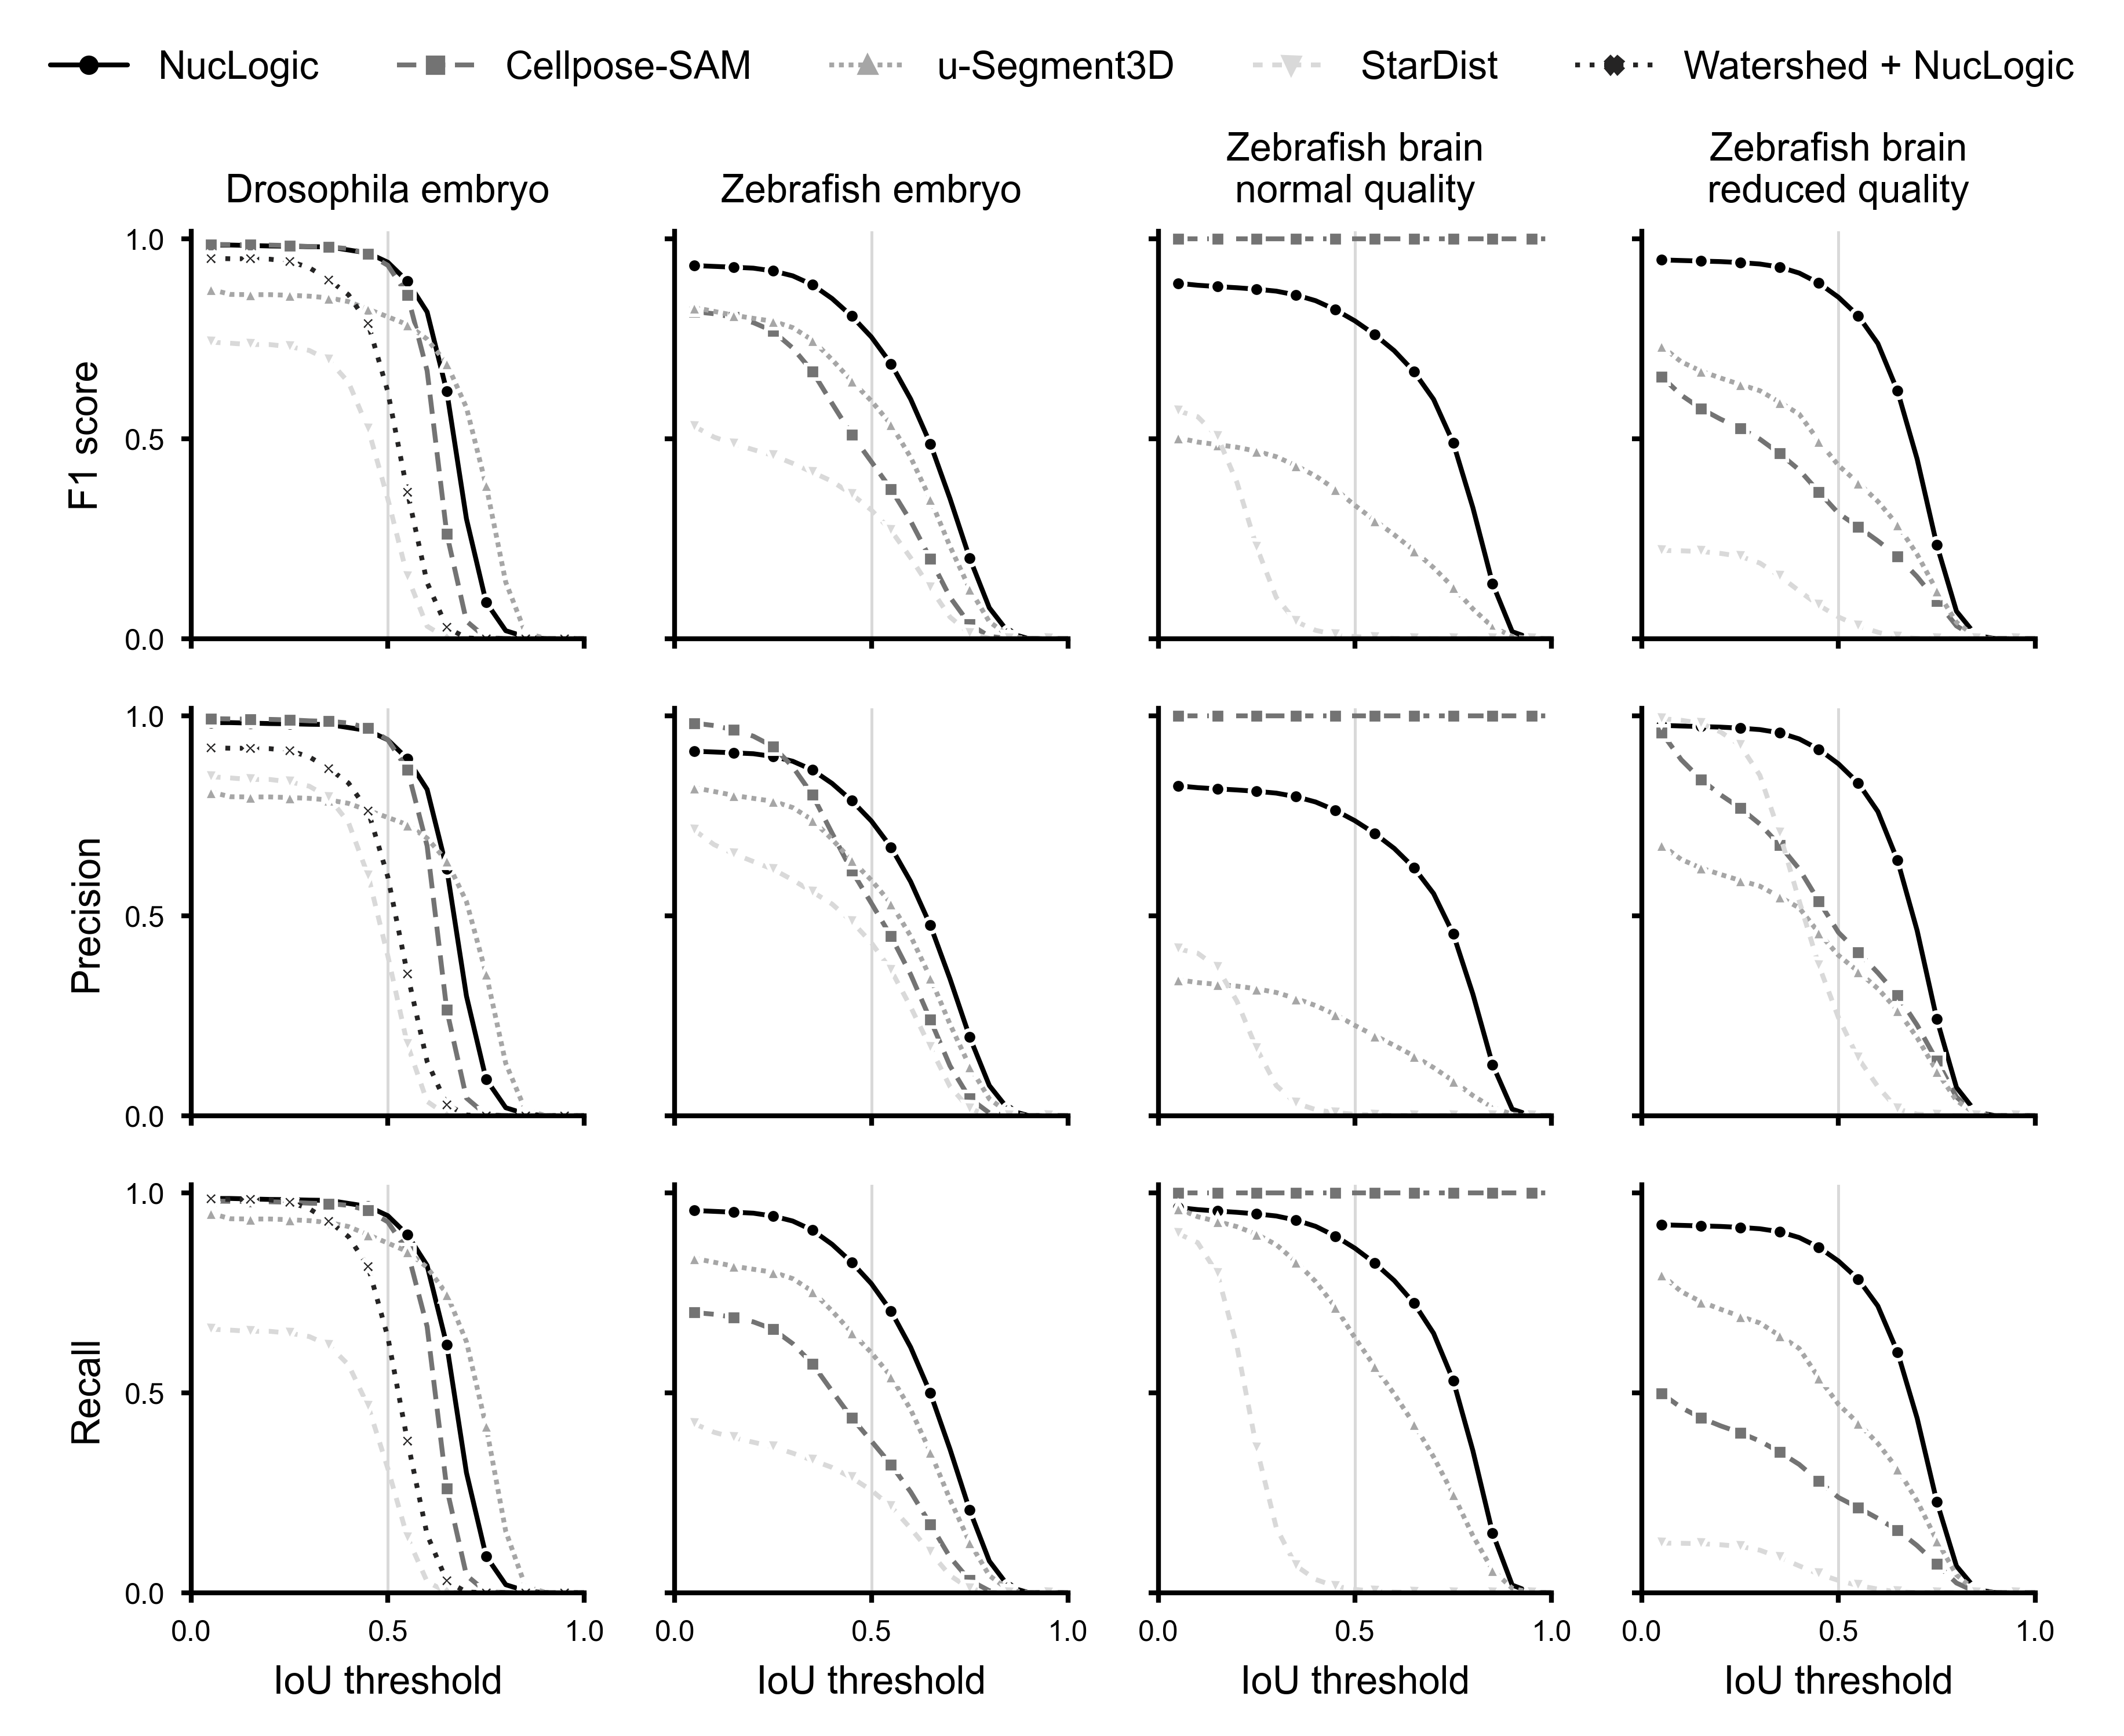

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
results = pd.read_csv(os.path.join(input_directory, "benchmark_hungarian_iou_sweep.tsv"), sep="\t")

# The three main methods, in legend order, with the display names used in the other figures.
method_names = {"nuclogic": "NucLogic", "cellpose4": "Cellpose-SAM", "usegment": "u-Segment3D", "stardist": "StarDist", "watershed + nuclogic": "Watershed + NucLogic"}
methods = list(method_names.values())
results = results[results["method"].isin(method_names)].copy()
results["method"] = results["method"].map(method_names)

# Shade, line style and marker all carry identity, so the figure survives grayscale print.
method_styles = {
    "NucLogic":    {"color": "black",   "dashes": "",     "marker": "o"},
    "Cellpose-SAM":  {"color": "#737373", "dashes": (4, 2), "marker": "s"},
    "u-Segment3D": {"color": "#a6a6a6", "dashes": (1, 1), "marker": "^"},
    "StarDist":    {"color": "#d9d9d9", "dashes": (2, 2), "marker": "v"},
    "Watershed + NucLogic": {"color": "#252424", "dashes": (1, 2), "marker": "X"},
}

sample_titles = {
    "Drosophila_1": "Drosophila embryo",
    # "Drosophila_2": "Drosophila 2",
    "Zebrafish_1": "Zebrafish embryo",
    "40x WIS zstack DAPI midbrain": "Zebrafish brain\nnormal quality",
    "40x WIS zstack DAPI midbrain_degraded": "Zebrafish brain\nreduced quality",
}
samples = list(dict.fromkeys(results["sample"]))  # keep the order the benchmark ran in
samples = [s for s in samples if s in sample_titles]  # filter out any extra samples that may have been added to the CSV

metrics = {"f1": "F1 score", "precision": "Precision", "recall": "Recall"}

sns.set_theme(context="paper", style="ticks", rc={
    "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
    "xtick.color": "black", "ytick.color": "black", "axes.edgecolor": "black",
})

# Built from the styles rather than read off a panel, so a method missing from one
# sample (e.g. a skipped file) still appears in the legend.
legend_handles = [
    Line2D([0], [0], color=s["color"], marker=s["marker"], markersize=3, linewidth=1,
           dashes=s["dashes"] or (None, None), label=m)
    for m, s in method_styles.items()
]

fig, axes = plt.subplots(
    len(metrics), len(samples),
    figsize=(1.5 * len(samples), 1.6 * len(metrics)),
    dpi=600,
    sharex=True,
    sharey=True,
    squeeze=False,
)

for row, (metric, label) in enumerate(metrics.items()):
    for col, sample in enumerate(samples):
        ax = axes[row, col]
        sns.lineplot(
            data=results[results["sample"] == sample].sort_values("iou_threshold"),
            x="iou_threshold",
            y=metric,
            hue="method",
            style="method",
            hue_order=methods,
            style_order=methods,
            palette={m: s["color"] for m, s in method_styles.items()},
            dashes={m: s["dashes"] for m, s in method_styles.items()},
            markers={m: s["marker"] for m, s in method_styles.items()},
            markersize=3,
            markevery=2,
            linewidth=1,
            errorbar=None,
            legend=False,
            ax=ax,
        )
        # Reference line at the conventional reporting threshold.
        ax.axvline(0.5, color="#d9d9d9", linewidth=0.6, zorder=0)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([0, 0.5, 1])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(labelsize=6, length=2)
        sns.despine(ax=ax)

        if row == 0:
            ax.set_title(sample_titles.get(sample, sample), fontsize=8)
        if row == len(metrics) - 1:
            ax.set_xlabel("IoU threshold", fontsize=8)

    axes[row, 0].set_ylabel(label, fontsize=8)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=len(methods),
    frameon=False,
    fontsize=8,
)
fig.tight_layout()

for ext in ("png", "eps"):
    fig.savefig(
        os.path.join(output_directory, f"benchmark_iou_sweep_combined.{ext}"),
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()



In [ ]:
import os
import numpy as np
import pandas as pd
import tifffile
from cellpose.metrics import average_precision
from skimage.segmentation import relabel_sequential

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
synthetic_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"
results_path = os.path.join(output_directory, "synthetic_hungarian_iou_sweep_l014.tsv")

iou_thresholds = np.round(np.linspace(0.05, 1, 20), 2)
n_organoids = 20

# Method name -> folder/file group. Each organoid i lives in synthetic_<group>_<i>/synthetic_<group>_<i>.tif
method_groups = {
    "nuclogic": "segmented_nuclogic",
    "cellpose4": "segmented_cp4",
    "usegment": "segmented_usegment",
    "stardist": "segmented_stardist",
}

# (sample, method) pairs to recompute even if already in the results file.
recompute = set()


def synthetic_path(group, i):
    name = f"synthetic_{group}_{i}"
    return os.path.join(synthetic_directory, name, f"{name}.tif")


def load_labels(path):
    # Relabel to 1..N so Cellpose's overlap matrix is sized by object count, not max label.
    labels, _, _ = relabel_sequential(tifffile.imread(path))
    return labels


# ── Work out what is already done ─────────────────────────────────────────────
if os.path.exists(results_path):
    existing = pd.read_csv(results_path, sep="\t")
    existing["iou_threshold"] = existing["iou_threshold"].round(2)
    wanted = set(iou_thresholds.tolist())
    done = {
        pair
        for pair, group in existing.groupby(["sample", "method"])
        if wanted <= set(group["iou_threshold"])
    } - recompute
else:
    existing = pd.DataFrame()
    done = set()

pending = {
    f"synthetic_{i}": [m for m in method_groups if (f"synthetic_{i}", m) not in done]
    for i in range(n_organoids)
}
n_pending = sum(len(m) for m in pending.values())
print(f"Already done: {len(done)} pairs. To run: {n_pending} pairs.")

# ── Run only the missing pairs ────────────────────────────────────────────────
results = []
for i in range(n_organoids):
    sample = f"synthetic_{i}"
    to_run = pending[sample]
    if not to_run:
        continue

    ground_truth = load_labels(synthetic_path("organoid_gt_l014", i))
    actual_cells = int(ground_truth.max())

    for method in to_run:
        pred_path = synthetic_path(method_groups[method], i)
        if not os.path.exists(pred_path):
            print(f"SKIPPED {sample} / {method}: file not found")
            continue

        prediction = load_labels(pred_path)
        if prediction.shape != ground_truth.shape:
            raise ValueError(f"{sample}/{method}: shape {prediction.shape} != GT {ground_truth.shape}")

        _, tp, fp, fn = average_precision(ground_truth, prediction, threshold=list(iou_thresholds))
        tp, fp, fn = tp.ravel(), fp.ravel(), fn.ravel()
        predicted_cells = int(prediction.max())

        for threshold, t, f, n in zip(iou_thresholds, tp, fp, fn):
            t, f, n = int(t), int(f), int(n)
            precision = t / (t + f) if t + f else 0.0
            recall = t / (t + n) if t + n else 0.0
            f1 = 2 * t / (2 * t + f + n) if t + f + n else 0.0
            results.append({
                "sample": sample,
                "method": method,
                "iou_threshold": float(threshold),
                "f1": f1,
                "precision": precision,
                "recall": recall,
                "actual_cells": actual_cells,
                "predicted_cells": predicted_cells,
                "true_positives": t,
                "false_positives": f,
                "false_negatives": n,
            })

    print(f"{sample}: done ({', '.join(to_run)})")

# ── Merge with the existing file and save ────────────────────────────────────
if results:
    new_df = pd.DataFrame(results)
    if not existing.empty:
        new_pairs = set(zip(new_df["sample"], new_df["method"]))
        keep = [pair not in new_pairs for pair in zip(existing["sample"], existing["method"])]
        existing = existing[keep]
    results_df = pd.concat([existing, new_df], ignore_index=True)
    results_df.to_csv(results_path, sep="\t", index=False)
    print(f"Saved {len(new_df)} new rows; file now holds {len(results_df)} rows.")
else:
    print("Nothing new to compute; results file unchanged.")


Already done: 0 pairs. To run: 80 pairs.
synthetic_0: done (nuclogic, cellpose4, usegment, stardist)
synthetic_1: done (nuclogic, cellpose4, usegment, stardist)
synthetic_2: done (nuclogic, cellpose4, usegment, stardist)
synthetic_3: done (nuclogic, cellpose4, usegment, stardist)
synthetic_4: done (nuclogic, cellpose4, usegment, stardist)
synthetic_5: done (nuclogic, cellpose4, usegment, stardist)
synthetic_6: done (nuclogic, cellpose4, usegment, stardist)
synthetic_7: done (nuclogic, cellpose4, usegment, stardist)
synthetic_8: done (nuclogic, cellpose4, usegment, stardist)
synthetic_9: done (nuclogic, cellpose4, usegment, stardist)
synthetic_10: done (nuclogic, cellpose4, usegment, stardist)
synthetic_11: done (nuclogic, cellpose4, usegment, stardist)
synthetic_12: done (nuclogic, cellpose4, usegment, stardist)
synthetic_13: done (nuclogic, cellpose4, usegment, stardist)
synthetic_14: done (nuclogic, cellpose4, usegment, stardist)
synthetic_15: done (nuclogic, cellpose4, usegment, sta

Organoids per method: {'Cellpose-SAM': 20, 'NucLogic': 20, 'StarDist': 20, 'u-Segment3D': 20}
WARNING f1: below 0.7 in the zoom window -> {'Cellpose-SAM': 0.552, 'NucLogic': 0.535, 'StarDist': 0.0, 'u-Segment3D': 0.48}
WARNING precision: below 0.7 in the zoom window -> {'Cellpose-SAM': 0.555, 'NucLogic': 0.525, 'StarDist': 0.0, 'u-Segment3D': 0.481}
WARNING recall: below 0.7 in the zoom window -> {'Cellpose-SAM': 0.549, 'NucLogic': 0.544, 'StarDist': 0.0, 'u-Segment3D': 0.48}


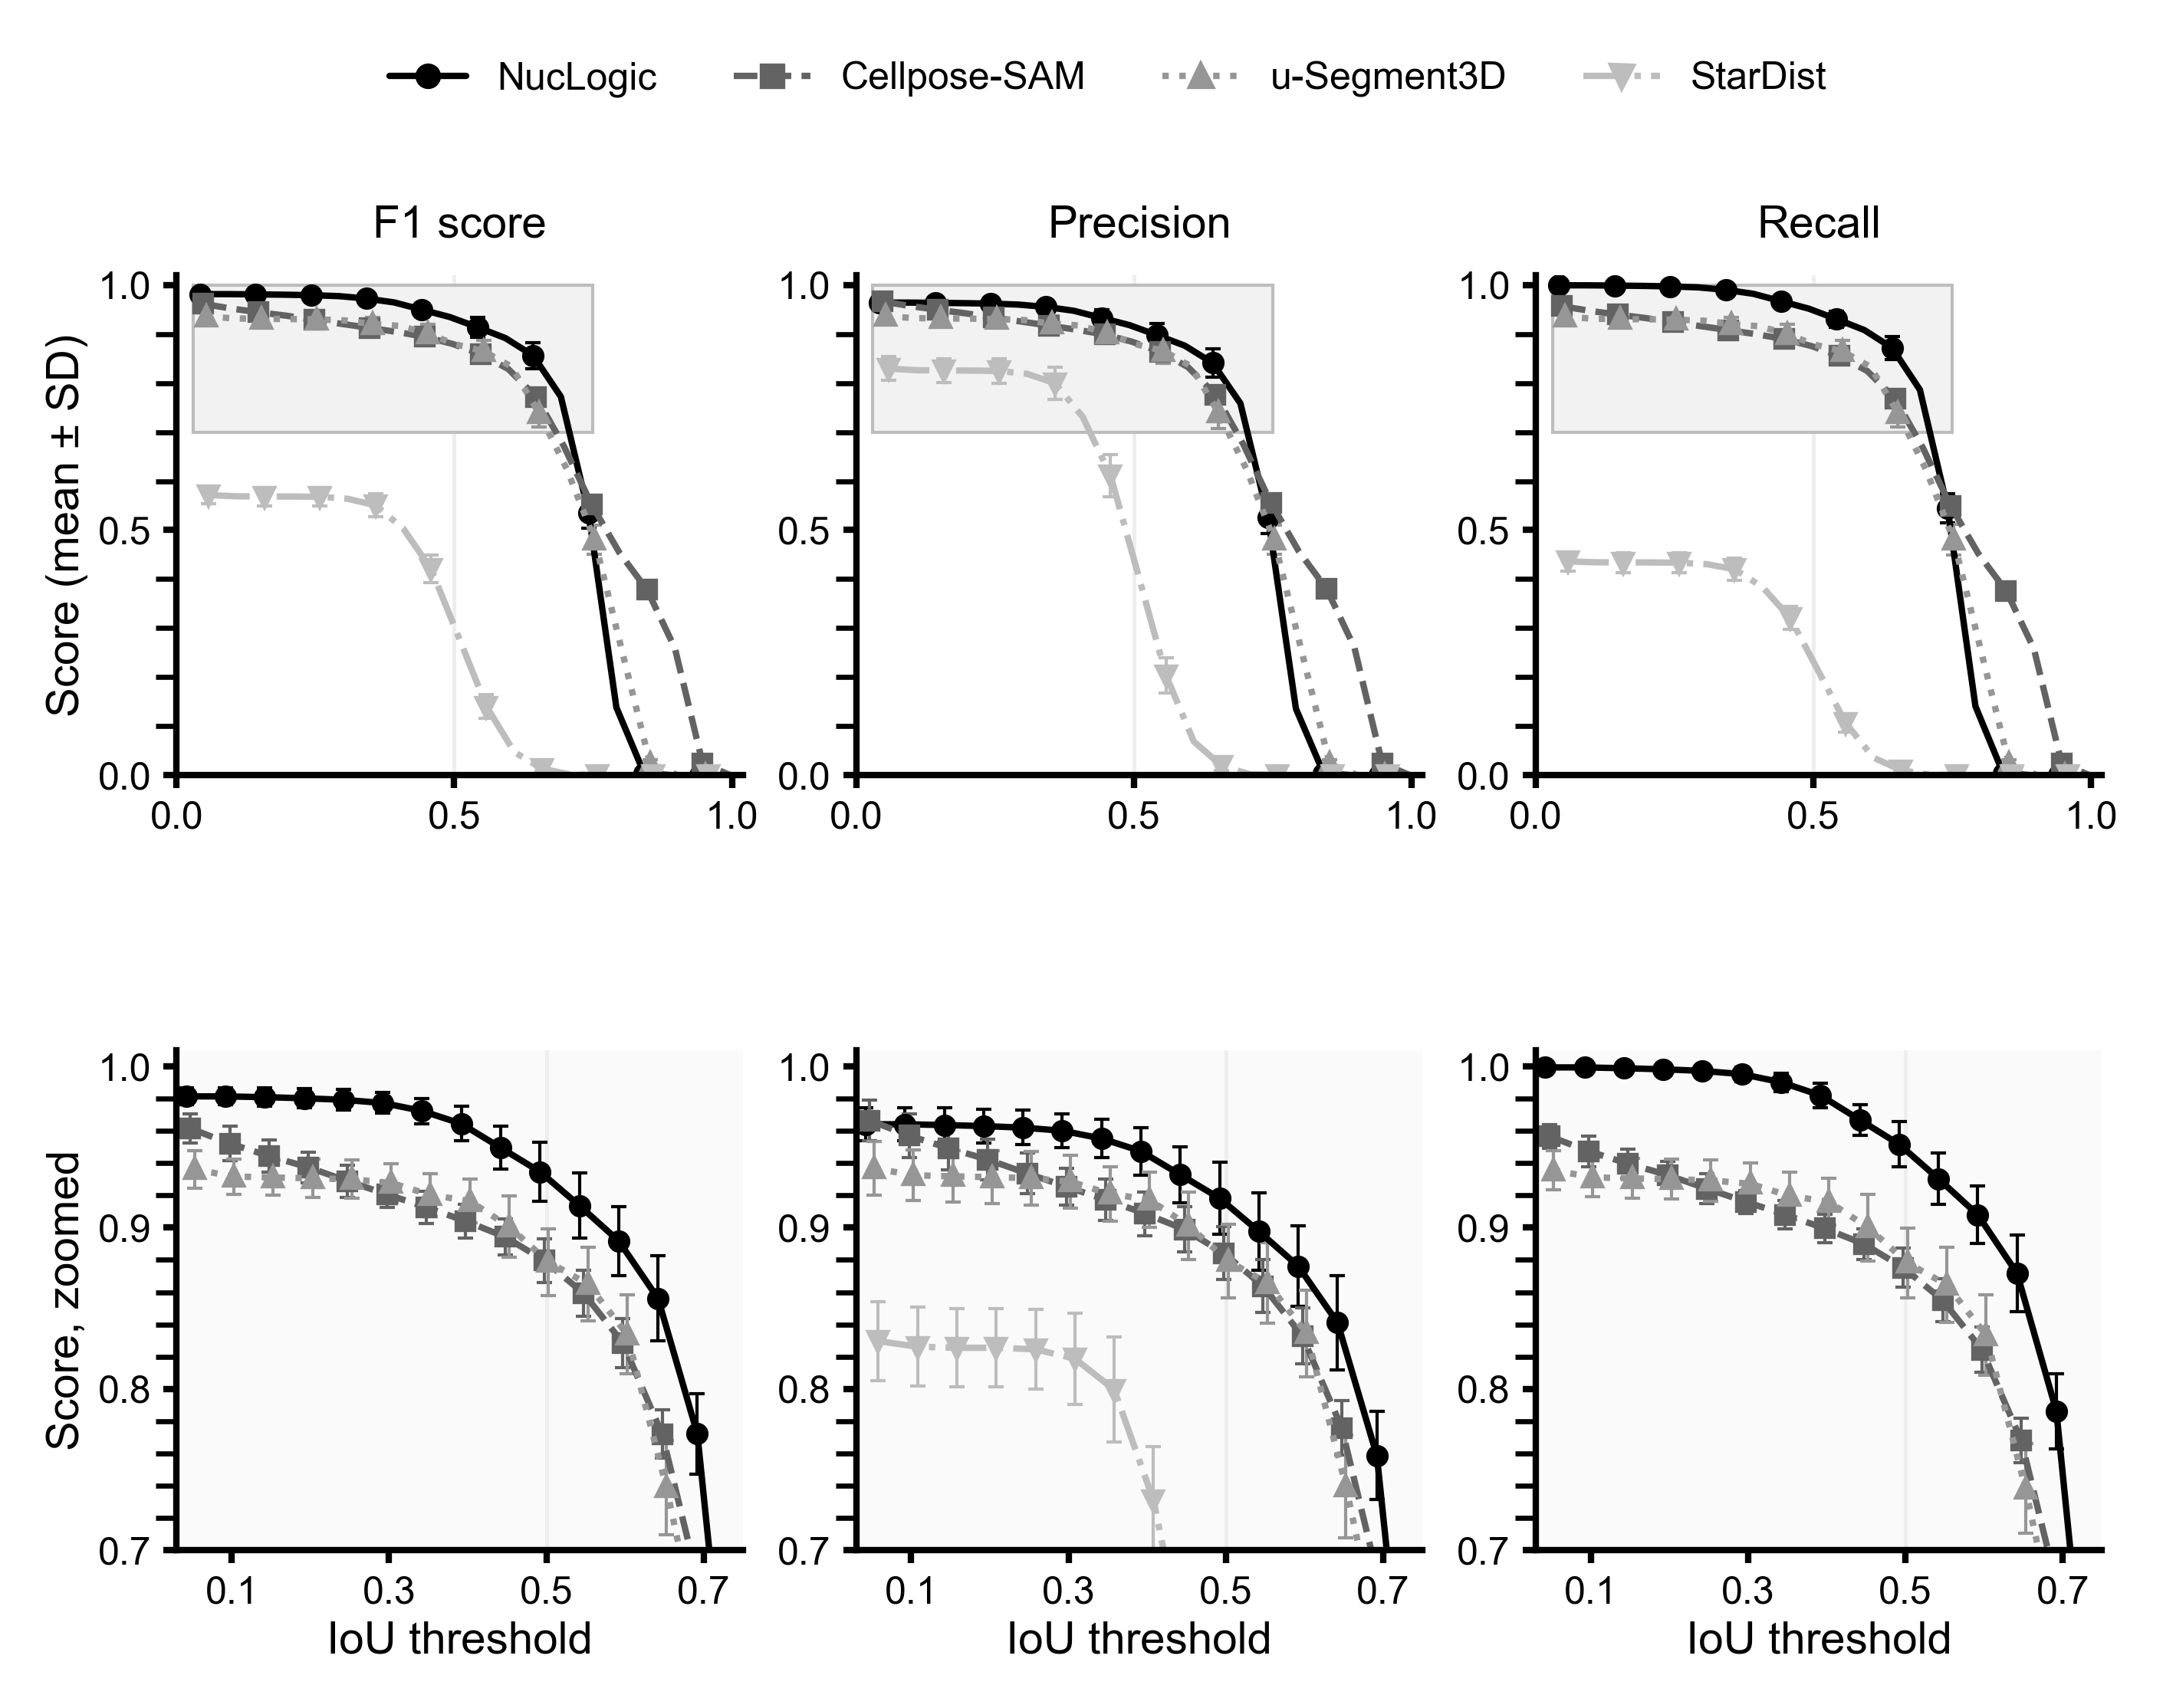

In [114]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
results = pd.read_csv(os.path.join(input_directory, "synthetic_hungarian_iou_sweep_l014.tsv"), sep="\t")

method_names = {"nuclogic": "NucLogic", "cellpose4": "Cellpose-SAM", "usegment": "u-Segment3D", "stardist": "StarDist"}
methods = list(method_names.values())
results = results[results["method"].isin(method_names)].copy()
results["method"] = results["method"].map(method_names)

# Shades spread evenly so the lightest line stays visible against the reference line.
method_styles = {
    "NucLogic":    {"color": "black",   "linestyle": "-",  "marker": "o"},
    "Cellpose-SAM":  {"color": "#636363", "linestyle": "--", "marker": "s"},
    "u-Segment3D": {"color": "#969696", "linestyle": ":",  "marker": "^"},
    "StarDist":    {"color": "#bdbdbd", "linestyle": "-.", "marker": "v"},
}
metrics = {"f1": "F1 score", "precision": "Precision", "recall": "Recall"}

# Region shown in the zoomed row.
zoom_x = (0.03, 0.75)
zoom_y = (0.7, 1.0)

summary = (
    results.groupby(["method", "iou_threshold"])[list(metrics)]
    .agg(["mean", "std", "count"])
)
n_per_method = results.groupby("method")["sample"].nunique()
print("Organoids per method:", n_per_method.to_dict())

# Never let a method silently fall off the zoomed axis.
in_zoom = summary[summary.index.get_level_values("iou_threshold") <= zoom_x[1]]
for metric in metrics:
    low = in_zoom[(metric, "mean")].groupby("method").min()
    below = low[low < zoom_y[0]]
    if not below.empty:
        print(f"WARNING {metric}: below {zoom_y[0]} in the zoom window -> {below.round(3).to_dict()}")

sns.set_theme(context="paper", style="ticks", rc={
    "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
    "xtick.color": "black", "ytick.color": "black", "axes.edgecolor": "black",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "savefig.edgecolor": "white",
})

offsets = dict(zip(methods, np.linspace(-0.008, 0.008, len(methods))))


def draw(ax, metric, every):
    for method in methods:
        if method not in summary.index.get_level_values("method"):
            continue
        s = summary.loc[method]
        style = method_styles[method]
        ax.errorbar(
            s.index + offsets[method],
            s[(metric, "mean")],
            yerr=s[(metric, "std")],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=2.5,
            markevery=every,
            linewidth=1,
            elinewidth=0.5,
            capsize=1.2,
            capthick=0.5,
            errorevery=every,
        )
    ax.axvline(0.5, color="#eeeeee", linewidth=0.6, zorder=0)
    ax.tick_params(labelsize=6, length=2)
    sns.despine(ax=ax)


fig, axes = plt.subplots(2, len(metrics), figsize=(5.4, 3.6), dpi=600,
                         gridspec_kw={"hspace": 0.55})

for col, (metric, label) in enumerate(metrics.items()):
    # Top row: the full sweep, with the zoomed region marked.
    top = axes[0, col]
    draw(top, metric, every=2)
    top.add_patch(Rectangle(
        (zoom_x[0], zoom_y[0]), zoom_x[1] - zoom_x[0], zoom_y[1] - zoom_y[0],
        facecolor="#f2f2f2", edgecolor="#bdbdbd", linewidth=0.5, zorder=0,
    ))
    top.set_title(label, fontsize=7)
    top.set_xlim(0, 1.02)
    top.set_ylim(0, 1.02)
    top.set_xticks([0, 0.5, 1])
    top.set_yticks([0, 0.5, 1])

    # Bottom row: the region where the methods differ. Every point shown, since
    # there are only ~12 thresholds in view.
    bottom = axes[1, col]
    draw(bottom, metric, every=1)
    bottom.set_xlim(*zoom_x)
    bottom.set_ylim(zoom_y[0], zoom_y[1] + 0.01)
    bottom.set_xticks([0.1, 0.3, 0.5, 0.7])
    bottom.set_yticks([0.7, 0.8, 0.9, 1.0])
    bottom.set_facecolor("#fafafa")
    bottom.set_xlabel("IoU threshold", fontsize=7)

axes[0, 0].set_ylabel("Score (mean ± SD)", fontsize=7)
axes[1, 0].set_ylabel("Score, zoomed", fontsize=7)

legend_handles = [
    Line2D([0], [0], color=s["color"], linestyle=s["linestyle"], marker=s["marker"],
           markersize=3, linewidth=1, label=m)
    for m, s in method_styles.items()
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.03),
           ncol=len(methods), frameon=False, fontsize=6)

for ext in ("png", "eps"):
    fig.savefig(os.path.join(output_directory, f"synthetic_iou_sweep.{ext}"), bbox_inches="tight", dpi=600)
plt.show()


2D segmentation test

In [ ]:
# make 2D stardist segmentation for synthethic organoid 0 
import os
import tifffile
import numpy as np
import stardist
from stardist.models import StarDist2D
from csbdeep.utils import normalize

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"


image = tifffile.imread(os.path.join(input_directory, "synthetic_organoid_0", "synthetic_organoid_0.tif"))

model = StarDist2D.from_pretrained('2D_versatile_fluo')

segmentation = []
for z in range(image.shape[0]):
    print(f"Processing slice {z+1}/{image.shape[0]}")
    img = image[z]
    img_norm = normalize(img)
    labels, _ = model.predict_instances(img_norm)
    segmentation.append(labels)
segmentation = np.array(segmentation)

os.mkdir(os.path.join(input_directory, "synthetic_organoid_stardist_2d_0"))
tifffile.imwrite(os.path.join(input_directory, "synthetic_organoid_stardist_2d_0", f"synthetic_organoid_stardist_2d_0.tif"), segmentation.astype(np.uint16), compression="zlib", compressionargs={"level": 8})


In [1]:
# add 2 cp3 segmentation
import os
from cellpose import models
import tifffile
import numpy as np

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"

image = tifffile.imread(os.path.join(input_directory, "synthetic_organoid_0", "synthetic_organoid_0.tif"))
models_names = ["cyto3", "nuclei"]

for model_type in models_names:
    print(f"Running Cellpose 3D segmentation with model type: {model_type}")
    model_loaded = models.Cellpose(model_type=model_type, gpu=True)   
    segmentation = []
    for z in range(image.shape[0]):
        print(f"Processing slice {z+1}/{image.shape[0]}")
        img = image[z]
        labels, flows, styles, diams= model_loaded.eval(img, diameter=30, channels=[0, 0])
        segmentation.append(labels)
    segmentation = np.array(segmentation)

    os.mkdir(os.path.join(input_directory, f"synthetic_organoid_cp3_{model_type}_0"))
    tifffile.imwrite(os.path.join(input_directory, f"synthetic_organoid_cp3_{model_type}_0", f"synthetic_organoid_cp3_{model_type}_0.tif"), segmentation.astype(np.uint16), compression="zlib", compressionargs={"level": 8})


Running Cellpose 3D segmentation with model type: cyto3


100%|██████████| 25.3M/25.3M [00:03<00:00, 7.40MB/s]
100%|██████████| 3.54k/3.54k [00:00<?, ?B/s]


Processing slice 1/108
Processing slice 2/108
Processing slice 3/108


c:\Users\6331823\AppData\Local\anaconda3\envs\cellpose3\Lib\site-packages\cellpose\dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


Processing slice 4/108
Processing slice 5/108
Processing slice 6/108
Processing slice 7/108
Processing slice 8/108
Processing slice 9/108
Processing slice 10/108
Processing slice 11/108
Processing slice 12/108
Processing slice 13/108
Processing slice 14/108
Processing slice 15/108
Processing slice 16/108
Processing slice 17/108
Processing slice 18/108
Processing slice 19/108
Processing slice 20/108
Processing slice 21/108
Processing slice 22/108
Processing slice 23/108
Processing slice 24/108
Processing slice 25/108
Processing slice 26/108
Processing slice 27/108
Processing slice 28/108
Processing slice 29/108
Processing slice 30/108
Processing slice 31/108
Processing slice 32/108
Processing slice 33/108
Processing slice 34/108
Processing slice 35/108
Processing slice 36/108
Processing slice 37/108
Processing slice 38/108
Processing slice 39/108
Processing slice 40/108
Processing slice 41/108
Processing slice 42/108
Processing slice 43/108
Processing slice 44/108
Processing slice 45/10

In [11]:
# add cp4 untrained
import os
from cellpose import models
import tifffile
import numpy as np

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"

image = tifffile.imread(os.path.join(input_directory, "synthetic_organoid_0", "synthetic_organoid_0.tif"))

try_3d_runs = ["False", "True"]

# load default Cellpose model (untrained) for 3D segmentation
model_loaded = models.CellposeModel(gpu=True)

for try_3d in try_3d_runs:
    print(f"Running Cellpose 3D segmentation with try_3d: {try_3d}")

    segmentation = []
    if try_3d == "True":
        segmentation, _, _ = model_loaded.eval(
                image,
                diameter=None,
                normalize=True,
                flow3D_smooth=0.4,
                resample=True,
                do_3D=True,
                progress=None,
                z_axis=0
            )
    else:
        for z in range(image.shape[0]):
            print(f"Processing slice {z+1}/{image.shape[0]}")
            img = image[z]
            labels, _, _ = model_loaded.eval(
                    img,
                    diameter=None,
                    normalize=True,
                    flow_threshold=0.4,
                    resample=True,
                    do_3D=False,
                    progress=None,
                )
            segmentation.append(labels)
        segmentation = np.array(segmentation)

    os.makedirs(os.path.join(input_directory, f"synthetic_organoid_cp4_untrained_3D_{try_3d}_0"), exist_ok=True)
    tifffile.imwrite(os.path.join(input_directory, f"synthetic_organoid_cp4_untrained_3D_{try_3d}_0", f"synthetic_organoid_cp4_untrained_3D_{try_3d}_0.tif"), segmentation.astype(np.uint16), compression="zlib", compressionargs={"level": 8})


Running Cellpose 3D segmentation with try_3d: False
Processing slice 1/108
Processing slice 2/108
Processing slice 3/108
Processing slice 4/108
Processing slice 5/108
Processing slice 6/108
Processing slice 7/108
Processing slice 8/108
Processing slice 9/108
Processing slice 10/108
Processing slice 11/108
Processing slice 12/108
Processing slice 13/108
Processing slice 14/108
Processing slice 15/108
Processing slice 16/108
Processing slice 17/108
Processing slice 18/108
Processing slice 19/108
Processing slice 20/108
Processing slice 21/108
Processing slice 22/108
Processing slice 23/108
Processing slice 24/108
Processing slice 25/108
Processing slice 26/108
Processing slice 27/108
Processing slice 28/108
Processing slice 29/108
Processing slice 30/108
Processing slice 31/108
Processing slice 32/108
Processing slice 33/108
Processing slice 34/108
Processing slice 35/108
Processing slice 36/108
Processing slice 37/108
Processing slice 38/108
Processing slice 39/108
Processing slice 40/1

In [2]:
import os
import tifffile
import numpy as np

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"
organoid = 0
scale = (2.5, 0.64, 0.64)  # in micrometers (z, y, x)
z_layers = [8, 51, 99]

def load(folder, filename=None):
    filename = filename or f"{folder}.tif"
    return tifffile.imread(os.path.join(input_directory, folder, filename))

image        = load(f"synthetic_organoid_{organoid}")
gt           = load(f"synthetic_organoid_{organoid}", "manual GT.tif")
cp3_cyto3    = load(f"synthetic_organoid_cp3_cyto3_{organoid}")
cp3_nuclei   = load(f"synthetic_organoid_cp3_nuclei_{organoid}")
cp4_2d       = load(f"synthetic_segmented_2d_{organoid}")
cp4_3d       = load(f"synthetic_segmented_cp4_{organoid}")
stardist_2d  = load(f"synthetic_organoid_stardist_2d_{organoid}")
stardist_3d  = load(f"synthetic_segmented_stardist_{organoid}")
cp4_untrained_2d = load(f"synthetic_organoid_cp4_untrained_3D_False_{organoid}")
cp4_untrained_3d = load(f"synthetic_organoid_cp4_untrained_3D_True_{organoid}")


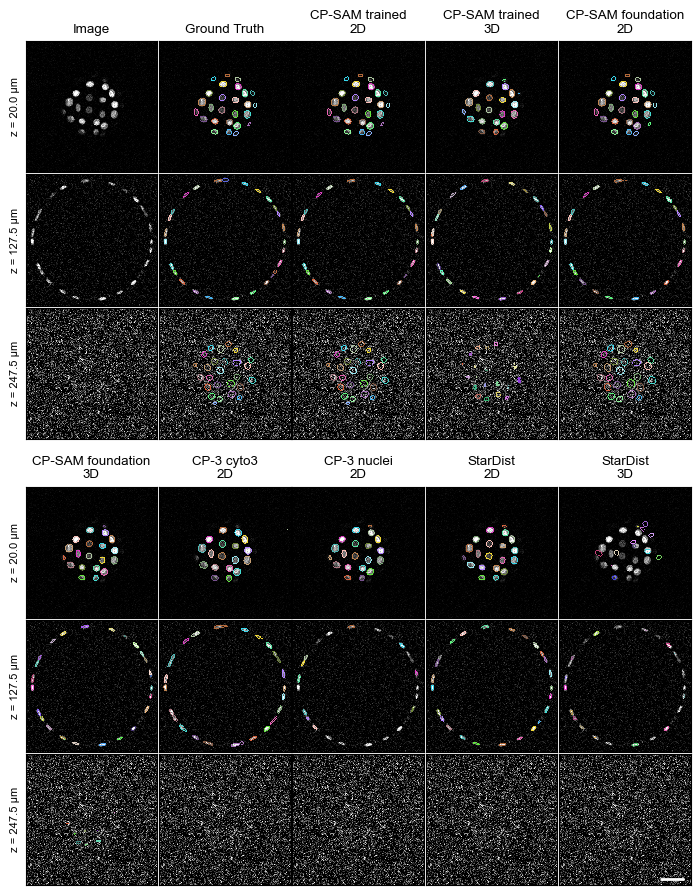

In [20]:
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
from skimage.morphology import binary_dilation, disk

segmentations = {
    "Ground Truth": gt,
    "CP-SAM trained\n2D": cp4_2d,
    "CP-SAM trained\n3D": cp4_3d,
    "CP-SAM foundation\n2D": cp4_untrained_2d,
    "CP-SAM foundation\n3D": cp4_untrained_3d,
    "CP-3 cyto3\n2D": cp3_cyto3,
    "CP-3 nuclei\n2D": cp3_nuclei,
    "StarDist\n2D": stardist_2d,
    "StarDist\n3D": stardist_3d,
}

contour_width = 3      # contour thickness in pixels, grows inward only
scale_bar_um = 50      # scale bar length in micrometers
plt.rcParams["svg.fonttype"] = "none"        # SVG: keep text as editable text
plt.rcParams["pdf.fonttype"] = 42            # PDF: embed TrueType, text stays editable
plt.rcParams["image.composite_image"] = False  # keep grayscale image and contour overlay as separate objects
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

mm = 1 / 25.4
fig_width_mm = 174
panels_per_row = 5

# first panel is the raw image, the rest are segmentations
panels = [("Image", None)] + list(segmentations.items())
n_blocks = int(np.ceil(len(panels) / panels_per_row))
n_z = len(z_layers)

h, w = image.shape[1:]
top_mm, left_mm, gap_mm = 5, 5, 0.5   # room for titles / z labels, and spacing between panels

# panel size follows from the width, so the height fits the images with no empty space
panel_w = (fig_width_mm - left_mm - gap_mm * (panels_per_row - 1)) / panels_per_row
panel_h = panel_w * h / w
block_h_mm = top_mm + n_z * panel_h + gap_mm * (n_z - 1)
block_gap_mm = 7   # extra space above every block except the first
fig_height_mm = n_blocks * block_h_mm + (n_blocks - 1) * block_gap_mm


# one random colour per label ID (label 0 = transparent)
rng = np.random.default_rng(0)
max_label = max(int(s.max()) for s in segmentations.values())
lut = np.concatenate([np.zeros((1, 3)), rng.uniform(0.2, 1, (max_label, 3))])

def contour_rgba(labels, width=1):
    edges = find_boundaries(labels, mode="inner")
    if width > 1:
        # thicken the edge, then drop everything that spilled into the background;
        # pixels that spill into a touching object take that object's colour below
        edges = binary_dilation(edges, disk(width - 1)) & (labels > 0)
    rgba = np.zeros(labels.shape + (4,))
    rgba[..., :3] = lut[labels]
    rgba[..., 3] = edges
    return rgba

fig = plt.figure(figsize=(fig_width_mm * mm, fig_height_mm * mm))

# one grid per block, stacked vertically; each block reserves top_mm for its titles
block_axes = []
for b in range(n_blocks):
    offset_mm = b * (block_h_mm + block_gap_mm)   # distance from the top of the figure to this block
    gs = fig.add_gridspec(
        n_z, panels_per_row,
        left=left_mm / fig_width_mm, right=1,
        top=1 - (offset_mm + top_mm) / fig_height_mm,
        bottom=1 - (offset_mm + block_h_mm) / fig_height_mm,
        wspace=gap_mm / panel_w, hspace=gap_mm / panel_h,
    )
    block_axes.append(gs.subplots(squeeze=False))


for r, z in enumerate(z_layers):
    vmin = np.median(image[z])             # normalize per z layer
    vmax = np.percentile(image[z], 99.8)
    for p, (name, seg) in enumerate(panels):
        b, c = divmod(p, panels_per_row)
        ax = block_axes[b][r, c]
        ax.imshow(image[z], cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
        if seg is not None:
            ax.imshow(contour_rgba(seg[z], width=contour_width), interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(name)
        if c == 0:
            ax.set_ylabel(f"z = {z * scale[0]:.1f} µm")

# hide unused panels if the number of panels doesn't fill the last block
for p in range(len(panels), n_blocks * panels_per_row):
    b, c = divmod(p, panels_per_row)
    for r in range(n_z):
        block_axes[b][r, c].axis("off")

# scale bar in the bottom right panel of the last block
ax = block_axes[-1][-1, (len(panels) - 1) % panels_per_row]
bar_px = scale_bar_um / scale[2]
margin = 0.05 * w
x1, y = w - margin, h - margin
ax.plot([x1 - bar_px, x1], [y, y], color="white", lw=2, solid_capstyle="butt")

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
fig.savefig(os.path.join(output_directory, "2d segmentation comparison.svg"), dpi=1200)
plt.show()


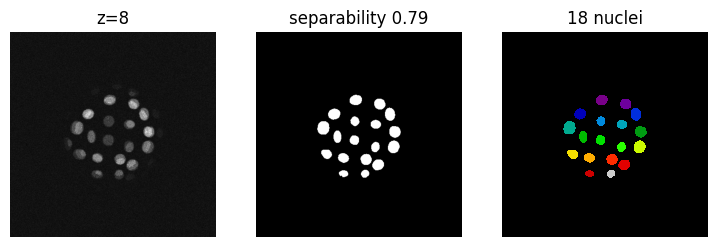

z=8: 18 nuclei, typical radius 9.4 px


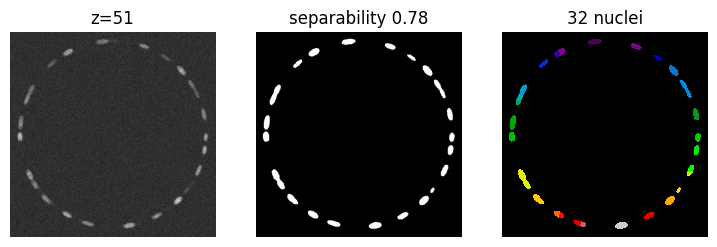

z=51: 32 nuclei, typical radius 5.8 px


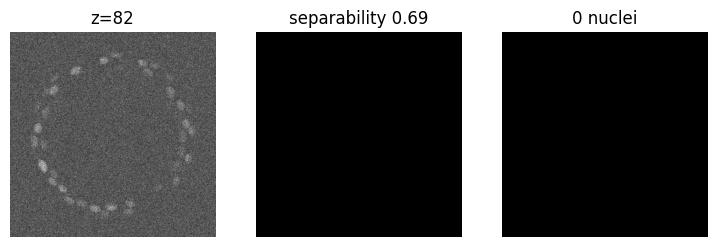

z=82: 0 nuclei, typical radius 0.0 px


In [4]:
# Try with watershed
import os
import tifffile
import numpy as np
from scipy import ndimage as ndi
from skimage import filters, measure, morphology, segmentation
from matplotlib import pyplot as plt

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"
organoid = 0
z_layers = [8, 51, 82]


def load(folder, filename=None):
    filename = filename or f"{folder}.tif"
    return tifffile.imread(os.path.join(input_directory, folder, filename))


class WatershedModel:
    """CPU 2D nuclear segmentation with Cellpose's eval() interface.

    No nucleus size or threshold to set: each XY plane is normalised, the
    threshold comes from Otsu on a strongly blurred copy, and the seed spacing
    is estimated from the objects found in that plane.
    """

    # Otsu's separability for pure Gaussian noise is 2/pi = 0.64; planes with real
    # nuclei score higher (0.70-0.79 on the synthetic data).
    MIN_SEPARABILITY = 0.70

    def __init__(self, small_sigma=1.5, large_sigma=4.0, percentiles=(1, 99.8)):
        self.small_sigma = small_sigma   # suppresses shot noise that fragments nuclei
        self.large_sigma = large_sigma   # smooths texture so Otsu sees two populations
        self.percentiles = percentiles
        self.last = {}                   # diagnostics of the latest plane

    def eval(self, plane, **_):
        empty = np.zeros(plane.shape, np.uint16)
        self.last = {}

        # 1. Normalise this XY plane to 0..1 on robust percentiles.
        plane = plane.astype(np.float32)
        low, high = np.percentile(plane, self.percentiles)
        if high <= low:
            return empty, None, None
        normalised = np.clip((plane - low) / (high - low), 0, 1)

        # 2. Small blur: the image we segment.
        fine = filters.gaussian(normalised, sigma=self.small_sigma)

        # 3. Big blur: only used to find the Otsu threshold.
        coarse = filters.gaussian(normalised, sigma=self.large_sigma)
        threshold = filters.threshold_otsu(coarse)

        # Normalising a plane without nuclei stretches pure noise, and Otsu still
        # finds a threshold in it. Check how well the threshold actually separates
        # two populations, and skip planes that look like noise.
        below, above = coarse[coarse <= threshold], coarse[coarse > threshold]
        separability = (below.size * above.size / coarse.size**2) * (below.mean() - above.mean()) ** 2 / coarse.var()
        self.last = {"threshold": threshold, "separability": separability}
        if separability < self.MIN_SEPARABILITY:
            return empty, None, None

        # 4. Apply that threshold to the small-blur image.
        foreground = ndi.binary_fill_holes(fine > threshold)
        objects = measure.label(foreground)
        if objects.max() == 0:
            return empty, None, None

        # Typical nucleus radius from the plane itself: each object's deepest point
        # in the distance map, median over objects.
        distance = ndi.distance_transform_edt(foreground)
        radius = float(np.median(ndi.maximum(distance, objects, np.arange(1, objects.max() + 1))))
        min_area = max(4, int(np.pi * (radius / 2) ** 2))
        sizes = np.bincount(objects.ravel())
        keep = sizes >= min_area
        keep[0] = False  # background
        foreground = keep[objects]

        # 5. Watershed from one seed per nucleus centre.
        distance = ndi.distance_transform_edt(foreground)
        seeds = measure.label(morphology.h_maxima(distance, max(1.0, 0.5 * radius)))
        labels = segmentation.watershed(-distance, seeds, mask=foreground)

        self.last.update(radius_px=radius, foreground=foreground)
        return labels.astype(np.uint16), None, None


image = load(f"synthetic_organoid_{organoid}")
model = WatershedModel()

for z in z_layers:
    labels, _, _ = model.eval(image[z])
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(image[z], cmap="gray")
    axes[0].set_title(f"z={z}")
    axes[1].imshow(model.last.get("foreground", labels > 0), cmap="gray")
    axes[1].set_title(f"separability {model.last.get('separability', 0):.2f}")
    axes[2].imshow(labels, cmap="nipy_spectral", interpolation="nearest")
    axes[2].set_title(f"{labels.max()} nuclei")
    for ax in axes:
        ax.axis("off")
    plt.show()
    print(f"z={z}: {labels.max()} nuclei, typical radius {model.last.get('radius_px', 0):.1f} px")


Segmenting planes |████████████████████████████████████████| 108/108 [100%] in 9.0s (12.04/s) 
new: 10.1 s, mean F1 0.789 | old: 4.1 s, mean F1 0.483
calibration planes [7 8 9], R = 9.7 px


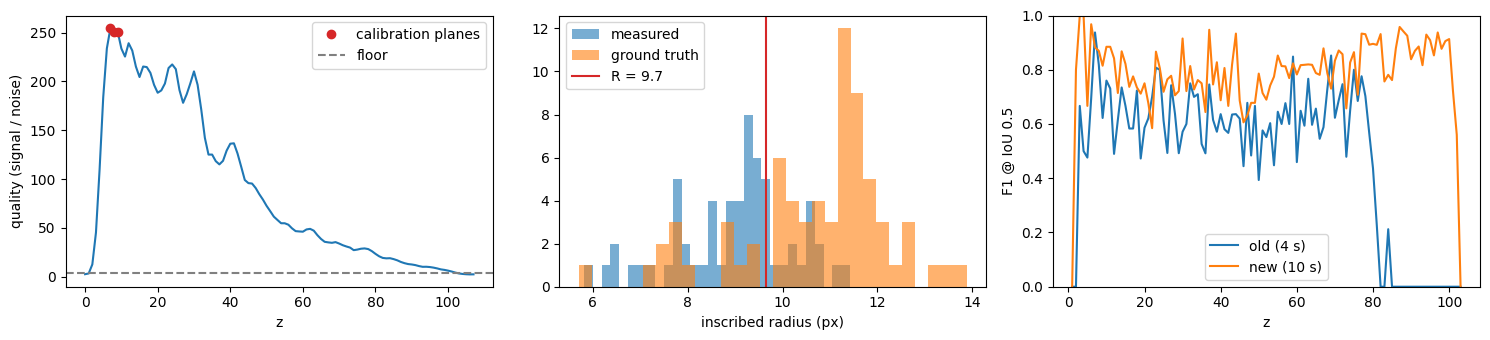

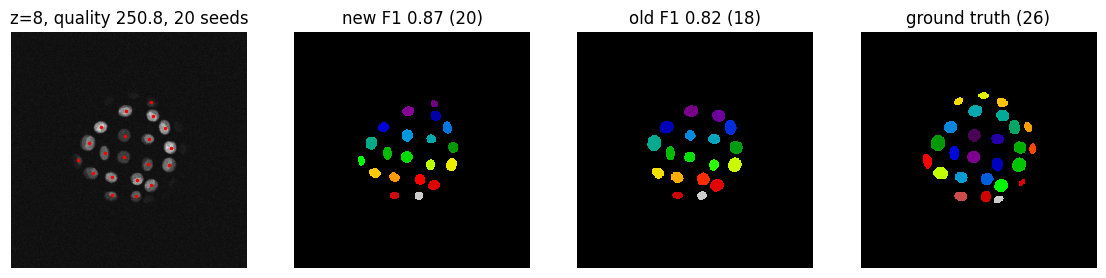

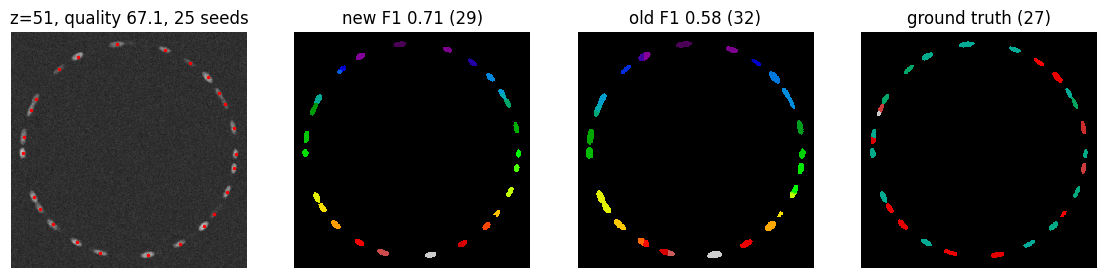

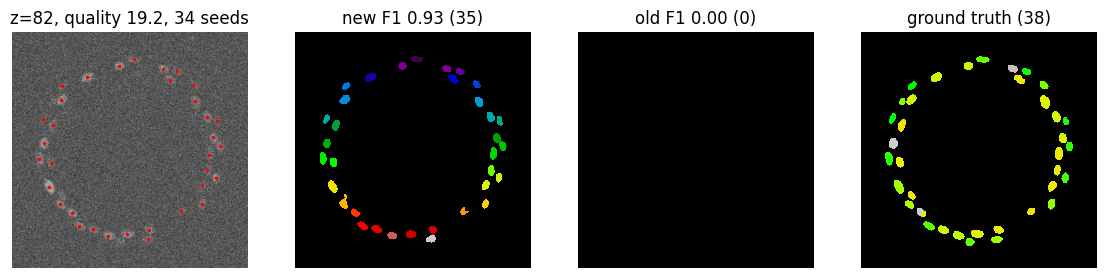

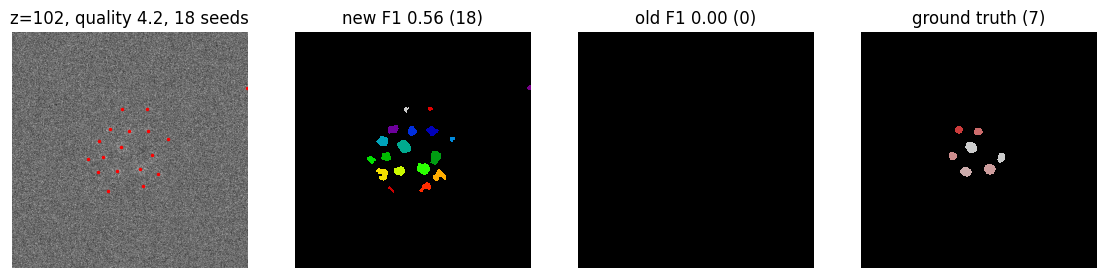

In [44]:
# Watershed v2: nucleus size measured on the best planes, reused on every plane
import time
import numpy as np
from scipy import ndimage as ndi
from skimage import filters, segmentation
from skimage.feature import peak_local_max
from matplotlib import pyplot as plt
from skimage import filters, morphology, segmentation
from alive_progress import alive_bar


# Linear filters, used to work out how much each one scales white-noise sigma
FILTERS = {
    "residual": lambda x, s: x - ndi.gaussian_filter(x, s),
    "gauss": ndi.gaussian_filter,
    "log": ndi.gaussian_laplace,
}


class WatershedSegmenter:
    """CPU 2D nuclear segmentation of a 3D stack, one label image per Z plane.

    The nucleus radius R is measured once on the highest-quality planes and then
    sets the blur, the seed detector and the seed spacing on every plane.
    Thresholds are in units of each plane's own noise, so planes without signal
    come out empty instead of segmenting stretched noise.
    """

    def __init__(self, diameter=None, z_sigma=1.0, k_fg=3.0, rel_fg=0.25, k_seed=3.0,
                    top_k=3, quality_floor=4.0, radius_percentile=75, compactness=0.0,
                    edge_frac=0.5, neck_depth=0.2, calibration_passes=3, min_rel_contrast=0.25):
        self.diameter = diameter            # px; None = measure it on the best planes
        self.z_sigma = z_sigma              # blur along Z, in planes; 0 = off
        self.k_fg = k_fg                    # foreground threshold in noise sigmas...
        self.rel_fg = rel_fg                # ...or as a fraction of the bright-nucleus level
        self.k_seed = k_seed                # seed (LoG peak) threshold in noise sigmas
        self.top_k = top_k                  # planes used for the size calibration
        self.quality_floor = quality_floor  # pure noise scores about 2.3
        self.edge_frac = edge_frac          # per-object edge at this fraction of its height (0.5 = half max)
        self.neck_depth = neck_depth        # split if the neck is this much narrower than the lobes, in units of R
        self.radius_percentile = radius_percentile
        self.compactness = compactness
        self.radius = None
        self.last = {}
        self._norms = {}
        self.calibration_passes = calibration_passes  # segment-and-remeasure rounds for R
        self.min_rel_contrast = min_rel_contrast  # drop objects whose signal is mostly a local pedestal (0 = off)

    def _norm(self, kind, sigma):
        """L2 norm of a filter kernel: noise sigma after filtering = sigma_n * norm."""
        key = (kind, round(float(sigma), 3))
        if key not in self._norms:
            size = 2 * int(4 * sigma + 2) + 1
            delta = np.zeros((size, size), np.float32)
            delta[size // 2, size // 2] = 1
            self._norms[key] = float(np.sqrt(np.sum(FILTERS[kind](delta, sigma) ** 2)))
        return self._norms[key]

    # -- per-plane measurements -------------------------------------------------
    def noise_sigma(self, plane, valid):
        """Robust noise sigma from the high-frequency residual (MAD), on valid pixels only."""
        inner = ndi.binary_erosion(valid, iterations=2)
        if inner.sum() < 100:
            return 0.0
        residual = FILTERS["residual"](plane, 1.0)[inner]
        mad = np.median(np.abs(residual - np.median(residual)))
        return 1.4826 * mad / self._norm("residual", 1.0)

    def quality(self, plane, sigma_n, valid):
        """Bright-structure contrast in noise sigmas; size-free so it works before calibration."""
        if sigma_n <= 0 or not valid.any():
            return 0.0
        smooth = ndi.gaussian_filter(plane, 2.0)
        p50, p99 = np.percentile(smooth[valid], [50, 99])
        return (p99 - p50) / (sigma_n * self._norm("gauss", 2.0))

    @staticmethod
    def measure_radius(plane):
        """Inscribed radius of every object on a good plane, without a size prior.

        No watershed needed: two merged nuclei still have an inscribed radius of
        about R, so connected components are enough.
        """
        fine = ndi.gaussian_filter(plane, 1.5)
        foreground = ndi.binary_fill_holes(fine > filters.threshold_otsu(fine))
        objects, n = ndi.label(foreground)
        if n == 0:
            return np.empty(0)
        distance = ndi.distance_transform_edt(foreground)
        radii = np.asarray(ndi.maximum(distance, objects, np.arange(1, n + 1)))
        return radii[radii >= 2]

    # -- segmentation -------------------------------------------------------------
    def segment_plane(self, plane, sigma_n, valid):
        R = self.radius
        no_seeds = np.empty((0, 2), int)

        # 1. Foreground: blur at R/3, threshold relative to this plane's noise and
        #    its bright-nucleus level, whichever is stricter.
        s_smooth = max(1.0, R / 3)
        smooth = ndi.gaussian_filter(plane, s_smooth)
        noise_smooth = sigma_n * self._norm("gauss", s_smooth)
        background = np.percentile(smooth[valid], 10) + 1.28 * noise_smooth
        bright = np.percentile(smooth[valid], 99)
        threshold = background + max(self.k_fg * noise_smooth, self.rel_fg * (bright - background))
        foreground = ndi.binary_fill_holes(smooth > threshold)

        min_area = max(4, int(0.15 * np.pi * R**2))  # small cross-sections are real
        objects, n = ndi.label(foreground)
        keep = np.bincount(objects.ravel()) >= min_area
        keep[0] = False
        foreground = keep[objects]
        if not foreground.any():
            return np.zeros(plane.shape, np.uint16), no_seeds
        objects, n = ndi.label(foreground)

        # 2. Seeds: Laplacian of Gaussian matched to radius R, peaks above k_seed sigmas.
        s_log = R / np.sqrt(2)
        blob = -ndi.gaussian_laplace(plane, s_log) / (sigma_n * self._norm("log", s_log))
        seeds = peak_local_max(blob, min_distance=max(1, int(round(0.7 * R))),
                               threshold_abs=self.k_seed, labels=foreground.astype(np.int32),
                               exclude_border=False)

        # Every foreground object gets at least one seed (its brightest pixel).
        seeded = np.zeros(n + 1, bool)
        seeded[objects[tuple(seeds.T)]] = True
        missing = np.flatnonzero(~seeded[1:]) + 1
        if missing.size:
            extra = np.array(ndi.maximum_position(smooth, objects, missing), int).reshape(-1, 2)
            seeds = np.vstack([seeds, extra])

        # 3. Watershed on the smoothed intensity inside the foreground.
        markers = np.zeros(plane.shape, np.int32)
        markers[tuple(seeds.T)] = np.arange(1, len(seeds) + 1)
        labels = segmentation.watershed(-smooth, markers, mask=foreground,
                                        compactness=self.compactness)

        labels = self.refine_edges(labels, smooth, background)
        labels = self.split_by_shape(labels)
        labels = self.reject_flat_objects(labels, smooth, background)

        # Drop fragments the split left behind.
        small = np.bincount(labels.ravel()) < min_area
        small[0] = False
        labels[small[labels]] = 0
        labels = segmentation.relabel_sequential(labels)[0]
        return labels.astype(np.uint16), seeds

    def refine_edges(self, labels, smooth, background):
        """Cut every object at edge_frac of its own height above its local background."""
        n = labels.max()
        if n == 0:
            return labels
        ids = np.arange(1, n + 1)
        peak = np.zeros(n + 1, np.float32)
        peak[1:] = ndi.maximum(smooth, labels, ids)
        # Local background: darkest smoothed value in a ring of R/2 around each object
        ring = segmentation.expand_labels(labels, distance=max(1.0, self.radius / 2))
        local_bg = np.zeros(n + 1, np.float32)
        local_bg[1:] = np.maximum(background, ndi.minimum(smooth, ring, ids))
        level = local_bg + self.edge_frac * (peak - local_bg)
        return np.where(smooth >= level[labels], labels, 0)

    def split_by_shape(self, labels):
        """Split objects whose mask has two lobes joined by a neck (distance-transform h-maxima)."""
        if labels.max() == 0:
            return labels
        inside = (labels > 0) & ~segmentation.find_boundaries(labels, mode="inner")
        distance = ndi.gaussian_filter(ndi.distance_transform_edt(inside).astype(np.float32), 1)
        h = max(1.0, self.neck_depth * self.radius)
        # h_maxima on a quantised map (0.25 px steps) is much faster than on floats
        peaks = morphology.h_maxima(np.round(distance * 4).astype(np.uint16), int(round(h * 4)))
        split = segmentation.watershed(-distance, ndi.label(peaks)[0], mask=labels > 0)
        # Thin objects with no interior get no marker: keep their original label
        missing = (split == 0) & (labels > 0)
        split[missing] = labels[missing] + split.max()
        return segmentation.relabel_sequential(split)[0]

    def reject_flat_objects(self, labels, smooth, background):
        """Drop objects that barely stand out from their own surroundings.

        rel = (object - ring around it) / (object - plane background): the fraction
        of an object's signal that is local. Nuclei score ~0.4-0.6; diffuse haze
        (cytoplasm, yolk, out-of-focus light) sits on a pedestal and scores ~0.1-0.2.
        Scale-free, so it does not depend on the SNR of the plane.
        """
        n = int(labels.max())
        if n == 0 or self.min_rel_contrast <= 0:
            return labels
        ids = np.arange(1, n + 1)
        ring = segmentation.expand_labels(labels, distance=max(1.0, self.radius / 2))
        ring[labels > 0] = 0
        with np.errstate(invalid="ignore", divide="ignore"):
            inside = np.asarray(ndi.mean(smooth, labels, ids))
            around = np.asarray(ndi.mean(smooth, ring, ids))
        around = np.where(np.isfinite(around), around, background)  # fully enclosed: no evidence against
        rel = (inside - around) / np.maximum(inside - background, 1e-6)
        keep = np.r_[False, rel > self.min_rel_contrast]
        return np.where(keep[labels], labels, 0)


    @staticmethod
    def block_mean(plane, f):
        """Downsample by an integer factor by averaging f x f blocks (drops the remainder)."""
        if f == 1:
            return plane
        h, w = (plane.shape[0] // f) * f, (plane.shape[1] // f) * f
        return plane[:h, :w].reshape(h // f, f, w // f, f).mean((1, 3), dtype=np.float32)

    @staticmethod
    def _resize(m, shape):
        """Bilinear resize of a response map onto `shape`."""
        out = ndi.zoom(m, np.array(shape) / np.array(m.shape), order=1, grid_mode=True, mode="nearest")
        out = out[: shape[0], : shape[1]]
        return np.pad(out, [(0, shape[0] - out.shape[0]), (0, shape[1] - out.shape[1])], mode="edge")

    def pyramid_radius(self, plane, k=5.0, octaves=(1, 2, 3, 4), per_octave=6):
        """First guess of the nucleus radius, without any intensity threshold.

        Scale-normalised LoG over an image pyramid: octave o works on 2^o x 2^o block
        means with sigma in [1.2, 2.4), i.e. radius 2^o * sqrt(2) * sigma in
        full-resolution pixels. Block averaging suppresses pixel noise, and the LoG is
        band-pass, so neither noise specks nor tissue haze win. Every significant blob
        votes with the scale where it responds most strongly. Range: about 3.5-50 px.
        """
        ref_shape = self.block_mean(plane, 2 ** octaves[0]).shape
        resp, zsc, radius_of = [], [], []
        for o in octaves:
            f = 2 ** o
            small = self.block_mean(plane, f)
            if min(small.shape) < 16:
                break
            valid = small > 0
            if valid.mean() > 0.99:
                valid[:] = True
            sigma_n = self.noise_sigma(small, valid)
            if sigma_n <= 0:
                continue
            for sg in 1.2 * 2 ** (np.arange(per_octave) / per_octave):
                log = -ndi.gaussian_laplace(small, sg)
                maps = [log * sg**2, log / (sigma_n * self._norm("log", sg))]
                if small.shape != ref_shape:
                    maps = [self._resize(m, ref_shape) for m in maps]
                resp.append(maps[0])
                zsc.append(maps[1])
                radius_of.append(f * np.sqrt(2) * sg)
        if len(radius_of) < 3:
            return np.nan
        resp, zsc, radius_of = np.stack(resp), np.stack(zsc), np.array(radius_of)
        best = resp.argmax(0)
        best_z = np.take_along_axis(zsc, best[None], 0)[0]
        # Only significant pixels can hold a peak (also keeps flat zero regions out: fast)
        peaks = peak_local_max(resp.max(0), min_distance=2, exclude_border=False,
                               labels=(best_z > k).astype(np.int32))
        b = best[tuple(peaks.T)]
        peaks = peaks[(b > 0) & (b < len(radius_of) - 1)]  # not stuck at the scale-range edges
        if len(peaks) == 0:
            return np.nan
        z = best_z[tuple(peaks.T)]
        strong = peaks[z >= np.median(z)]  # most significant half
        return float(np.median(radius_of[best[tuple(strong.T)]]))

    @staticmethod
    def isolated_radii(labels):
        """Equivalent radius sqrt(area/pi) of objects that touch no other object.

        Fragments of an over-split nucleus always touch their siblings, so they
        cannot drag the radius estimate down.
        """
        n = int(labels.max())
        if n == 0:
            return np.empty(0)
        grown = ndi.grey_dilation(labels, size=3)                                  # larger neighbour label
        shrunk = ndi.grey_erosion(np.where(labels > 0, labels, n + 1), size=3)    # smaller neighbour label
        contact = (labels > 0) & ((grown != labels) | (shrunk != labels))
        touching = np.zeros(n + 1, bool)
        touching[labels[contact]] = True
        keep = np.flatnonzero(~touching[1:]) + 1
        return np.sqrt(np.bincount(labels.ravel(), minlength=n + 1)[keep] / np.pi)

    def calibrate_radius(self, planes, noises, valids):
        """Pyramid first guess, then segment and re-measure on isolated objects until stable."""
        guesses = [self.pyramid_radius(p) for p in planes]
        guess = np.nanmedian(guesses) if np.isfinite(guesses).any() else 5.0
        self.radius = float(np.clip(guess, 2, 50))
        history, radii = [self.radius], np.empty(0)
        for _ in range(self.calibration_passes):
            radii = np.concatenate([self.isolated_radii(self.segment_plane(p, n, v)[0])
                                    for p, n, v in zip(planes, noises, valids)])
            if radii.size < 10:
                break
            new = float(np.clip(np.percentile(radii, self.radius_percentile), 2, 50))
            history.append(new)
            converged = abs(new - self.radius) < 0.05 * self.radius
            self.radius = new
            if converged:
                break
        return radii, history

    def segment_stack(self, image):
        stack = image.astype(np.float32)
        if self.z_sigma > 0:  # borrow signal from neighbouring planes
            stack = ndi.gaussian_filter1d(stack, self.z_sigma, axis=0)

        valid = stack > 0
        if valid.mean() > 0.99:   # no clipped background: use every pixel
            valid[:] = True

        noise = np.array([self.noise_sigma(p, v) for p, v in zip(stack, valid)])
        quality = np.array([self.quality(p, s, v) for p, s, v in zip(stack, noise, valid)])
        best = np.argsort(quality)[::-1][: self.top_k]

        if self.diameter:
            radii, history = np.empty(0), []
            self.radius = self.diameter / 2
        else:
            radii, history = self.calibrate_radius(stack[best], noise[best], valid[best])

        labels = np.zeros(stack.shape, np.uint16)
        seeds = []
        with alive_bar(stack.shape[0], title="Segmenting planes") as bar:
            for z, plane in enumerate(stack):
                bar()
                if quality[z] < self.quality_floor:
                    seeds.append(np.empty((0, 2), int))
                    continue
                labels[z], s = self.segment_plane(plane, noise[z], valid[z])
                seeds.append(s)
                

        self.last = dict(noise=noise, quality=quality, calibration_planes=best, radii=radii, radius=self.radius, radius_history=history, seeds=seeds)
        return labels



def f1_at_iou(gt, pred, threshold=0.5):
    """2D instance F1: a prediction matches a GT object when IoU > threshold."""
    g, p = gt.ravel().astype(np.int64), pred.ravel().astype(np.int64)
    n_gt, n_pred = len(np.unique(g[g > 0])), len(np.unique(p[p > 0]))
    if n_gt + n_pred == 0:
        return np.nan
    both = (g > 0) & (p > 0)
    if not both.any():
        return 0.0
    pairs, inter = np.unique(np.stack([g[both], p[both]]), axis=1, return_counts=True)
    union = np.bincount(g)[pairs[0]] + np.bincount(p)[pairs[1]] - inter
    return 2 * np.sum(inter / union > threshold) / (n_gt + n_pred)


# -- run ------------------------------------------------------------------------
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"
image = load(f"synthetic_organoid_{organoid}")
gt = load(f"synthetic_segmented_nuclogic_{organoid}")

new = WatershedSegmenter()
t0 = time.perf_counter()
labels_new = new.segment_stack(image)
t_new = time.perf_counter() - t0

old = WatershedModel()  # from the cell above
t0 = time.perf_counter()
labels_old = np.stack([old.eval(plane)[0] for plane in image])
t_old = time.perf_counter() - t0

zs = np.arange(len(image))
f1_new = np.array([f1_at_iou(gt[z], labels_new[z]) for z in zs])
f1_old = np.array([f1_at_iou(gt[z], labels_old[z]) for z in zs])
print(f"new: {t_new:.1f} s, mean F1 {np.nanmean(f1_new):.3f} | old: {t_old:.1f} s, mean F1 {np.nanmean(f1_old):.3f}")
print(f"calibration planes {new.last['calibration_planes']}, R = {new.radius:.1f} px")

# GT radii on the same planes, for checking R (boundaries split touching GT nuclei)
gt_radii = []
for z in new.last["calibration_planes"]:
    inside = (gt[z] > 0) & ~segmentation.find_boundaries(gt[z])
    ids = np.unique(gt[z][gt[z] > 0])
    gt_radii.append(np.asarray(ndi.maximum(ndi.distance_transform_edt(inside), gt[z], ids)))
gt_radii = np.concatenate([np.sqrt(np.bincount(gt[z].ravel())[np.unique(gt[z][gt[z] > 0])] / np.pi)
                           for z in new.last["calibration_planes"]])


# -- diagnostics ----------------------------------------------------------------
quality, cal = new.last["quality"], new.last["calibration_planes"]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 3.5))
ax1.plot(zs, quality)
ax1.plot(cal, quality[cal], "o", c="C3", label="calibration planes")
ax1.axhline(new.quality_floor, ls="--", c="gray", label="floor")
ax1.set(xlabel="z", ylabel="quality (signal / noise)")
ax1.legend()
ax2.hist(new.last["radii"], bins=30, alpha=0.6, label="measured")
ax2.hist(gt_radii, bins=30, alpha=0.6, label="ground truth")
ax2.axvline(new.radius, c="C3", label=f"R = {new.radius:.1f}")
ax2.set(xlabel="inscribed radius (px)")
ax2.legend()
ax3.plot(zs, f1_old, label=f"old ({t_old:.0f} s)")
ax3.plot(zs, f1_new, label=f"new ({t_new:.0f} s)")
ax3.set(xlabel="z", ylabel="F1 @ IoU 0.5", ylim=(0, 1))
ax3.legend()
plt.tight_layout()
plt.show()

z_layers = [8, 51, 82, 102]

for z in z_layers:
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    axes[0].imshow(image[z], cmap="gray")
    seeds = new.last["seeds"][z]
    axes[0].plot(seeds[:, 1], seeds[:, 0], "r.", ms=3)
    axes[0].set_title(f"z={z}, quality {quality[z]:.1f}, {len(seeds)} seeds")
    for ax, lab, name in zip(axes[1:], [labels_new[z], labels_old[z], gt[z]],
                             [f"new F1 {f1_new[z]:.2f}", f"old F1 {f1_old[z]:.2f}", "ground truth"]):
        ax.imshow(lab, cmap="nipy_spectral", interpolation="nearest")
        ax.set_title(f"{name} ({len(np.unique(lab)) - 1})")
    for ax in axes:
        ax.axis("off")
    plt.show()


In [ ]:
# Test on other samples
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
import napari

input_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"

samples = ["Zebrafish_1"]
scale = (2.5,0.64,0.64)
viewer = napari.Viewer(ndisplay=3)

for sample in samples:
    image = tifffile.imread(os.path.join(input_directory, sample, f"data.tif"))
    gt = tifffile.imread(os.path.join(input_directory, sample, f"GroundTruth.tif"))
    viewer.add_image(image, name="raw image", scale=scale)
    viewer.add_labels(gt, name="ground truth", scale=scale)
   
    print(f"Sample {sample} has {gt.max()} ground truth objects")

    t0 = time.perf_counter()
    segmenter = WatershedSegmenter()
    labels_2d = segmenter.segment_stack(image)
    viewer.add_labels(labels_2d, name=f"{sample} segmentation", scale=scale)
    print(f"Sample {sample} has {len(np.unique(labels_2d))-1} segmented objects")
    segmentation_3d = stitch_3d(labels_2d, image, scale = scale)
    t_new = time.perf_counter() - t0
    print(f"Sample {sample}: {t_new:.1f} s")
    viewer.add_labels(segmentation_3d, name=f"{sample} stitched segmentation", scale=scale)
    results = centroid_accuracy(gt, segmentation_3d)
    tifffile.imwrite(os.path.join(input_directory, sample, f"3d_segmented_watershed.tif"), segmentation_3d.astype(np.uint16), compression="zlib", compressionargs={"level": 8})
    print(results)



Sample Zebrafish_1 has 12793 ground truth objects
Segmenting planes |████████████████████████████████████████| 170/170 [100%] in 7:14.0 (0.39/s) 
Sample Zebrafish_1 has 3383 segmented objects
Starting 3D stitching process...
Created 96346 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 26877 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 3641 breaks.
    Iteration 2: Made 1373 breaks.
    Iteration 3: Made 272 breaks.
    Iteration 4: Made 37 breaks.
Finding touching cell pairs...
Found 18343 pairs of touching cells.
Splitted 7978 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 679 small cells, and removed 9052 cells without suitable neighbors.
Final stitched mask has 22469 cells.
Sample Zebrafish_1: 515.3 s
{'true_positives': 10423, 'false_negatives': 2370, 'false_positives': 12046, 'merged_cells': 853, 'precision': 0.4638835729226935, 'recall': 0.814

Presentation figures

In [35]:
# movie intro
import os
from imaris_ims_file_reader.ims import ims
import napari
from napari_animation import Animation
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
movie = ims(os.path.join(input_directory, "MvL_Exp202_TL_F01_cropped.ims"))[:]
segmentation = tifffile.imread(os.path.join(input_directory, "MvL_Exp202_TL_F01_segmented.tif"))
mcherry = movie[:, 0]
irfp = movie[:, 1]

movie_max = np.max(movie, axis = 1)

model_loaded = models.CellposeModel(gpu=True)

segmentation_cp = []
for frame in range(movie_max.shape[0]):
    print(f"Processing frame {frame+1}/{movie_max.shape[0]}")
    mask, _, _ = model_loaded.eval(
            movie_max[frame],
            diameter=None,
            normalize=True,
            flow3D_smooth=0.4,
            resample=True,
            do_3D=True,
            z_axis=0
        )
    segmentation_cp.append(mask)
segmentation_cp = np.array(segmentation_cp)

tifffile.imwrite(os.path.join(input_directory, "MvL_Exp202_TL_F01_segmented_cp4.tif"), segmentation_cp.astype(np.uint16), compression="zlib", compressionargs={"level": 8})



scale = (2.5, 0.64, 0.64)  # in micrometers (z, y, x)
contrast_mcherry = (np.median(mcherry[0]) + np.std(mcherry[0])*4, np.percentile(mcherry[0], 99.99))
contrast_irfp = (np.median(irfp[0])*1.5 + np.std(irfp[0])*5, np.percentile(irfp[0], 99.995))
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(mcherry, name="mCherry", scale=scale, colormap="green", contrast_limits=contrast_mcherry, blending="additive")
viewer.add_image(irfp, name="iRFP", scale=scale, colormap="magenta", contrast_limits=contrast_irfp, blending="additive")
viewer.add_labels(segmentation_cp, name="Segmentation", scale=scale, opacity=1, colormap=colormap, iso_gradient_mode="smooth")

viewer.layers["mCherry"].visible = False
viewer.layers["iRFP"].visible = False

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
# viewer.grid.enabled = True
# viewer.camera.zoom   = 2.5

# --- time-lapse animation ---
animation = Animation(viewer)
output_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
n_timepoints = mcherry.shape[0]
frames_per_timepoint = 4          # higher = slower playback
fps = 12
hours_per_frame = 2

# optional time stamp that follows the time slider
viewer.text_overlay.visible = True
viewer.text_overlay.color = "white"
viewer.text_overlay.font_size = 24
viewer.text_overlay.position = "bottom_center"

def update_time_label(event=None):
    t = viewer.dims.current_step[0]
    total_hours = t * hours_per_frame
    viewer.text_overlay.text = f"{total_hours} h"

viewer.dims.events.current_step.connect(update_time_label)

# keep the camera fixed, only time changes
viewer.camera.angles = viewing_angle

# first keyframe at t = 0
viewer.dims.current_step = (0,) + viewer.dims.current_step[1:]
update_time_label()
animation.capture_keyframe(steps=1)

# one keyframe per timepoint
for t in range(1, n_timepoints):
    viewer.dims.current_step = (t,) + viewer.dims.current_step[1:]
    animation.capture_keyframe(steps=frames_per_timepoint)

animation.animate(
    os.path.join(output_directory, "Growing organoid segmented cp timelapse.mp4"),
    canvas_only=True,
    fps=fps,
    quality=9,
    # scale_factor=2,  # higher-resolution render
)


Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\MvL_Exp202_TL_F01_cropped.ims 



c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 2, time 23, channel 1. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:134: UserWarning: HistogramMin value is not present for resolution 2, time 23, channel 1.
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)


Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\MvL_Exp202_TL_F01_cropped.ims 

Processing frame 1/24
Processing frame 2/24
Processing frame 3/24
Processing frame 4/24
Processing frame 5/24
Processing frame 6/24
Processing frame 7/24
Processing frame 8/24
Processing frame 9/24
Processing frame 10/24
Processing frame 11/24
Processing frame 12/24
Processing frame 13/24
Processing frame 14/24
Processing frame 15/24
Processing frame 16/24
Processing frame 17/24
Processing frame 18/24
Processing frame 19/24
Processing frame 20/24
Processing frame 21/24
Processing frame 22/24
Processing frame 23/24
Processing frame 24/24
Rendering frames...


100%|██████████| 93/93 [00:09<00:00, 10.17it/s]


In [3]:
# Movie interacting cells

#B overview of touching cells
import os
import tifffile
import napari
from napari.utils.colormaps import colormap_utils as cu
from napari.components._viewer_constants import CanvasPosition
import numpy as np
import pandas as pd
from napari_animation import Animation
colormap = cu.label_colormap(num_colors=1024)
input_directory = r"E:\Data Hussein\E-133_S-61_O-1"

movie = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_cropped.tif"))[:-2]
segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented.tif"))[:-2]
dilated_segmentation = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_segmented_touching_neighbour_5um.tif"))[:-2]
wt_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_wt_mask.tif"))[:-2]
crc_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_crc_mask.tif"))[:-2]
properties = pd.read_csv(os.path.join(input_directory, "E-133_S-61_O-1_properties.tsv"), sep="\t")
combined_mask = []
for timepoint in range(segmentation.shape[0]):
    segmentation_timepoint = segmentation[timepoint]
    timepoint_properties = properties[properties["timepoint"] == timepoint]
    wt_properties = timepoint_properties[timepoint_properties["phenotype_crc_vs_wt"].str.lower() == "wt"]
    wt_touching_ids = wt_properties[wt_properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1]["label"].values
    wt_non_touching_ids = wt_properties[wt_properties["phenotype_similarity_ratio_touching_neighbour_5um"] == 1]["label"].values
    crc_properties = timepoint_properties[timepoint_properties["phenotype_crc_vs_wt"].str.lower() == "crc"]
    crc_touching_ids = crc_properties[crc_properties["phenotype_similarity_ratio_touching_neighbour_5um"] < 1]["label"].values
    crc_non_touching_ids = crc_properties[crc_properties["phenotype_similarity_ratio_touching_neighbour_5um"] == 1]["label"].values

    combined_mask.append(np.select(
        [
            np.isin(segmentation_timepoint, wt_touching_ids),
            np.isin(segmentation_timepoint, wt_non_touching_ids),
            np.isin(segmentation_timepoint, crc_touching_ids),
            np.isin(segmentation_timepoint, crc_non_touching_ids),
        ],
        [1, 2, 3, 4],
        default=0,
    ).astype(np.uint8))
combined_mask = np.stack(combined_mask, axis=0)
# tifffile.imwrite(os.path.join(input_directory, "E-133_S-61_O-1_combined_mask_dilated.tif"), combined_mask, compression="zlib", compressionargs={"level": 8})
# combined_mask = tifffile.imread(os.path.join(input_directory, "E-133_S-61_O-1_combined_mask_dilated.tif"))
colormap_mixed = {2: "#f1a7c4", 1: "magenta", 4: "#a7eaa7", 3: "#319b31"}
colormap_touching = {1: "magenta", 3: "#319b31"}
colormap_phenotype = {1: "magenta", 2: "magenta", 3: "#319b31", 4: "#319b31"}

viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)

dapi = movie[:, :, 0]
d2 = movie[:, :, 1]
mtmg = movie[:, :, 2]
dapi_contrast = (np.median(dapi[0]) + np.std(dapi[0])*4, np.percentile(dapi[0], 99.99))
d2_contrast = (np.median(d2[0]) + np.std(d2[0])*6, np.percentile(d2[0], 99.99))
mtmg_contrast = (np.median(mtmg[0]) + np.std(mtmg[0])*4, np.percentile(mtmg[0], 99.99))
viewer.add_image(dapi, name="DAPI", scale=scale, colormap="blue", contrast_limits=dapi_contrast, blending="additive")
viewer.add_image(d2, name="D2", scale=scale, colormap="green", contrast_limits=d2_contrast, blending="additive")
viewer.add_image(mtmg, name="MTMG", scale=scale, colormap="magenta", contrast_limits=mtmg_contrast, blending="additive")
viewer.add_labels(segmentation, name = "Segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="additive")
# viewer.add_labels(dilated_segmentation, name = "Dilated Segmentation", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap, blending="additive")
# viewer.add_labels(crc_mask, name = "CRC mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"green"}, blending="translucent")
# viewer.add_labels(wt_mask, name = "WT mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap={1:"magenta"}, blending="translucent")
viewer.add_labels(combined_mask, name = "Combined Mask all", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap_phenotype, blending="translucent")
# viewer.add_labels(combined_mask, name = "Combined Mask", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap_mixed, blending="translucent")
viewer.add_labels(combined_mask, name = "Combined Mask touching", scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap_touching, blending="translucent")


viewer.reset_view()
def update_slider(event):
    time = viewer.dims.current_step[0]
    viewer.text_overlay.text = f"{time*5} h"

viewer.text_overlay.visible = True
viewer.text_overlay.position = CanvasPosition.BOTTOM_CENTER
viewer.text_overlay.color = "white"
viewer.text_overlay.font_size = 32
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
viewer.dims.events.current_step.connect(update_slider)
viewer.grid.enabled = True
viewer.camera.angles = (180, 0, 0)
viewer.dims.set_point(0, 12)  # move to timepoint 12

# viewer.camera.center = (255.82705268500638, 48.530579166199146, 251.23925045414418)
viewer.camera.angles = (148.75832664972222, -29.25266749741341, 47.47202111488936)
viewer.camera.zoom = 1.8
# # # Reset view to the data bounds, then set a side-view camera angle (XZ view)
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# viewer.screenshot(path=os.path.join(output_directory, "anna_interaction.png"), size=(2160, 3840), canvas_only=True, scale = 1)

# keep the camera fixed, only time changes
import imageio.v2 as imageio

frames_per_timepoint = 4          # higher = slower playback
fps = 12

# with imageio.get_writer(
#     os.path.join(output_directory, "phenotype and interaction timelapse_2.mp4"),
#     fps=fps, quality=9,
# ) as writer:
#     for t in range(dapi.shape[0]):
#         viewer.dims.current_step = (t,) + viewer.dims.current_step[1:]   # triggers update_slider -> text overlay
#         frame = viewer.screenshot(canvas_only=True, scale=2)             # RGBA
#         for _ in range(frames_per_timepoint):
#             writer.append_data(frame[..., :3])

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [12]:
import imageio.v2 as imageio

# ---------------- settings ----------------
FPS = 30
OUT_SIZE = (1080, 1920)                     # (height, width) -> 16:9; (2160, 3840) for 4K
ZOOM = 1.3 * 3                              # zoom at T_START
ZOOM_END = ZOOM * 0.6                       # zoom at the last timepoint (lower = more zoomed out)
quality = 6                                # 0-10, higher = better quality, larger file
OUT = os.path.join(output_directory, "NucLogic_story_medium_quality.mp4")
H_PER_TP = 5
T_START = 20 // H_PER_TP                    # 20 h -> timepoint 4
T_SWITCH = 60 // H_PER_TP                   # 60 h -> timepoint 12
PLAY2 = (0, T_SWITCH)                # 2nd playback range; e.g. (T_SWITCH, segmentation.shape[0]-1) to continue instead
SEC_PER_TP = 0.6                            # playback speed
TOP_IS_HIGH_Z = True                        # flip if the wipe runs the wrong way on screen
DEG_PER_SEC = 4                             # rotation speed around the z axis (0 = no rotation)
SEC = lambda s: max(1, int(round(s * FPS)))

viewer.grid.enabled = False                 # grid mode would tile all layers side by side
L = viewer.layers
Z_SCALE = scale[0]
z_extent = dapi.shape[1] * Z_SCALE          # clipping planes live in world units (µm)
occupied = np.flatnonzero(segmentation[T_START].any(axis=(1, 2)))
z_lo = (occupied[0] - 1) * Z_SCALE          # sample bottom, world units
z_hi = (occupied[-1] + 1) * Z_SCALE         # sample top


base_opacity = {l.name: l.opacity for l in L}

from PIL import Image, ImageDraw, ImageFont, ImageColor

BLUE, GREEN, MAGENTA, WHITE = (ImageColor.getrgb(c) for c in ("#4d8cff", "#33dd33", "#ff33ff", "#ffffff"))
CAPTIONS = {                                # layer name -> list of (text, colour); order = left to right
    "DAPI": [("DAPI", BLUE)],
    "D2": [("Dendra2", GREEN)],
    "MTMG": [("mTmG", MAGENTA)],
    "Segmentation": [("Segmentation", WHITE)],
    "Combined Mask all": [("WT", MAGENTA), (" vs ", WHITE), ("Cancer", GREEN)],
    "Combined Mask touching": [("Interacting cells", WHITE)],
}
CAPTION_SEP = "     "
try:
    FONT = ImageFont.truetype("arialbd.ttf", int(OUT_SIZE[0] * 0.045))
except OSError:
    FONT = ImageFont.load_default(size=int(OUT_SIZE[0] * 0.045))
caption_alpha = {}                          # per-layer override, used during wipes
caption_hidden = set()                      # captions switched off immediately (layer swaps)
caption_x = {}                              # layer name -> fixed x position while on screen
CAPTION_ORDER = list(CAPTIONS)
_measure = ImageDraw.Draw(Image.new("RGB", (1, 1)))
SEP_W = _measure.textlength(CAPTION_SEP, font=FONT)

def item_width(name):
    return sum(_measure.textlength(text, font=FONT) for text, _ in CAPTIONS[name])

def caption_alpha_of(name):
    if name in caption_hidden:
        return 0
    l = L[name]
    return caption_alpha.get(name, l.opacity / base_opacity[name] if l.visible else 0)

def layout_captions(active, width):
    """Keep existing captions where they are; place only newcomers."""
    for name in list(caption_x):
        if name not in active:
            del caption_x[name]
    new = [n for n in active if n not in caption_x]
    if not new:
        return
    block = sum(item_width(n) for n in new) + SEP_W * (len(new) - 1)
    if not caption_x:                                            # empty screen -> centre
        x = (width - block) / 2
    elif CAPTION_ORDER.index(new[0]) > max(CAPTION_ORDER.index(n) for n in caption_x):
        last = max(caption_x, key=caption_x.get)                 # append to the right
        x = caption_x[last] + item_width(last) + SEP_W
    else:                                                        # insert to the left
        x = min(caption_x.values()) - SEP_W - block
    for n in new:
        caption_x[n] = x
        x += item_width(n) + SEP_W

def draw_caption(frame):
    alphas = {n: caption_alpha_of(n) for n in CAPTIONS}
    active = [n for n in CAPTION_ORDER if alphas[n] > 0.01]
    layout_captions(active, frame.shape[1])
    if not active:
        return frame
    img = Image.fromarray(frame).convert("RGBA")
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    d = ImageDraw.Draw(overlay)
    y = int(img.height * 0.04)
    for n in active:
        x = caption_x[n]
        for text, col in CAPTIONS[n]:
            d.text((x, y), text, font=FONT, fill=col + (int(255 * alphas[n]),))
            x += d.textlength(text, font=FONT)
    return np.asarray(Image.alpha_composite(img, overlay).convert("RGB"))

# ---------------- camera rotation ----------------
T_LAST = segmentation.shape[0] - 1
view0 = np.array(viewer.camera.view_direction)
up0 = np.array(viewer.camera.up_direction)
frame_idx = 0
current_zoom = ZOOM

def zoom_at(t):
    """Geometric zoom-out from ZOOM at T_START to ZOOM_END at T_LAST (t may be fractional)."""
    frac = np.clip((t - T_START) / max(T_LAST - T_START, 1), 0, 1)
    return ZOOM * (ZOOM_END / ZOOM) ** frac

def rotate_about_z(v, deg):
    a = np.deg2rad(deg)
    z, y, x = v
    return np.array([z, y * np.cos(a) - x * np.sin(a), y * np.sin(a) + x * np.cos(a)])

def update_camera():
    deg = DEG_PER_SEC * frame_idx / FPS
    viewer.camera.set_view_direction(rotate_about_z(view0, deg), rotate_about_z(up0, deg))
    viewer.camera.zoom = current_zoom


# ---------------- helpers ----------------
def smoothstep(n):
    x = np.linspace(0, 1, n)
    return x * x * (3 - 2 * x)

def set_cut(layer, cut):
    """Show only the part of the volume *below* `cut` (world units, 0..z_extent)."""
    if TOP_IS_HIGH_Z:
        plane = {"position": (cut, 0, 0), "normal": (-1, 0, 0), "enabled": True}
    else:
        plane = {"position": (z_extent - cut, 0, 0), "normal": (1, 0, 0), "enabled": True}
    layer.experimental_clipping_planes = [plane]

def clear_cut(layer):
    layer.experimental_clipping_planes = []

def snap(writer, n=1):
    """Render n frames; the camera keeps rotating during holds."""
    global frame_idx
    for _ in range(n):
        update_camera()
        frame = viewer.screenshot(canvas_only=True, size=OUT_SIZE, flash=False)[..., :3]
        h, w = frame.shape[:2]
        frame = frame[: h // 2 * 2, : w // 2 * 2]
        writer.append_data(draw_caption(np.ascontiguousarray(frame)))
        frame_idx += 1

def wipe(writer, layers, mode, seconds):
    for l in layers:
        l.visible = True
    for x in smoothstep(SEC(seconds)):
        frac = 1 - x if mode == "off" else x
        cut = z_lo + frac * (z_hi - z_lo)
        for l in layers:
            set_cut(l, cut)
            caption_alpha[l.name] = frac
        snap(writer)
    for l in layers:
        clear_cut(l)
        caption_alpha.pop(l.name, None)
        if mode == "off":
            l.visible = False

def fade(writer, fade_in=(), fade_out=(), seconds=0.8):
    if fade_in:                                                  # swap: old caption off at once
        caption_hidden.update(l.name for l in fade_out)
    for l in fade_in:
        l.opacity, l.visible = 0, True
    for x in smoothstep(SEC(seconds)):
        for l in fade_in:
            l.opacity = x * base_opacity[l.name]
        for l in fade_out:
            l.opacity = (1 - x) * base_opacity[l.name]
        snap(writer)
    for l in fade_out:
        l.visible, l.opacity = False, base_opacity[l.name]
        caption_hidden.discard(l.name)

def go_to(t):
    viewer.dims.current_step = (t,) + viewer.dims.current_step[1:]   # triggers update_slider

def play(writer, t0, t1):
    """Step through timepoints; zoom eases out smoothly per frame, not per timepoint."""
    global current_zoom
    n = SEC(SEC_PER_TP)
    for t in range(t0, t1 + 1):
        go_to(t)
        for i in range(n):
            current_zoom = zoom_at(t + i / n)
            snap(writer)

def rewind(writer, t_from, t_to, seconds=1.5):
    """Fast, eased reverse through time; zoom follows the same curve back in."""
    global current_zoom
    for x in smoothstep(SEC(seconds)):
        t = t_from + x * (t_to - t_from)
        go_to(int(round(t)))
        current_zoom = zoom_at(t)
        snap(writer)

# ---------------- initial state ----------------
for l in L:
    l.visible = False
    l.opacity = base_opacity[l.name]
    clear_cut(l)
for name in ("DAPI", "D2", "MTMG"):
    L[name].visible = True
go_to(T_START)
update_slider(None)
viewer.text_overlay.visible = True
viewer.scale_bar.visible = True
caption_alpha.clear(); caption_hidden.clear(); caption_x.clear()


# ---------------- the story ----------------
with imageio.get_writer(OUT, fps=FPS, quality=quality, macro_block_size=1) as w:
    snap(w, SEC(2))                                              # 1. raw 3-channel overview at 20 h
    wipe(w, [L["D2"], L["MTMG"]], "off", 2.5)                    # 2. D2 + MTMG off, top -> bottom
    snap(w, SEC(0.1))
    wipe(w, [L["DAPI"]], "off", 2.5)                             # 3. DAPI off, top -> bottom
    # snap(w, SEC(0.1))
    wipe(w, [L["DAPI"], L["Segmentation"]], "on", 3)             # 4. DAPI + segmentation on, bottom -> top
    snap(w, SEC(1.5))
    fade(w, fade_out=[L["DAPI"]],                                 # 5. DAPI off in one go, D2 + MTMG on
         fade_in=[L["D2"], L["MTMG"]], seconds=1.0)
    fade(w, fade_out=[L["Segmentation"]], seconds=2.0)
    snap(w, SEC(1.0))
    fade(w, fade_out=[L["D2"], L["MTMG"]],    # 6. -> phenotyped masks
         fade_in=[L["Combined Mask all"]], seconds=1.0)
    snap(w, SEC(1.5))
    play(w, T_START, T_SWITCH)                                   # 7. timelapse 20 h -> 60 h
    snap(w, SEC(1))
    fade(w, fade_out=[L["Combined Mask all"]],                   # 8. only touching cells
         fade_in=[L["Combined Mask touching"]], seconds=1.0)
    snap(w, SEC(1.5))
    snap(w, SEC(1.5))
    rewind(w, T_SWITCH, PLAY2[0], seconds=1.5)                   # 9. fast rewind 60 h -> 0 h
    snap(w, SEC(0.5))
    play(w, *PLAY2)                                              # 10. timelapse again, 0 h -> 60 h
    snap(w, SEC(2))
print("saved", OUT)


saved C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures\NucLogic_story_medium_quality.mp4


NucLogic
  TP 3632, FP 440, FN 435 (of which merged 180), F1 0.892
  slices 10-15: TP 648, FP 77, FN 56 (of which merged 22), F1 0.907
Cellpose-SAM
  TP 2655, FP 322, FN 1412 (of which merged 1162), F1 0.754
  slices 10-15: TP 760, FP 65, FN 286 (of which merged 240), F1 0.812
u-Segment3D
  TP 3163, FP 1219, FN 904 (of which merged 653), F1 0.749
  slices 10-15: TP 626, FP 182, FN 164 (of which merged 122), F1 0.783
StarDist
  TP 1291, FP 576, FN 2776 (of which merged 20), F1 0.435
  slices 10-15: TP 261, FP 105, FN 566 (of which merged 4), F1 0.438


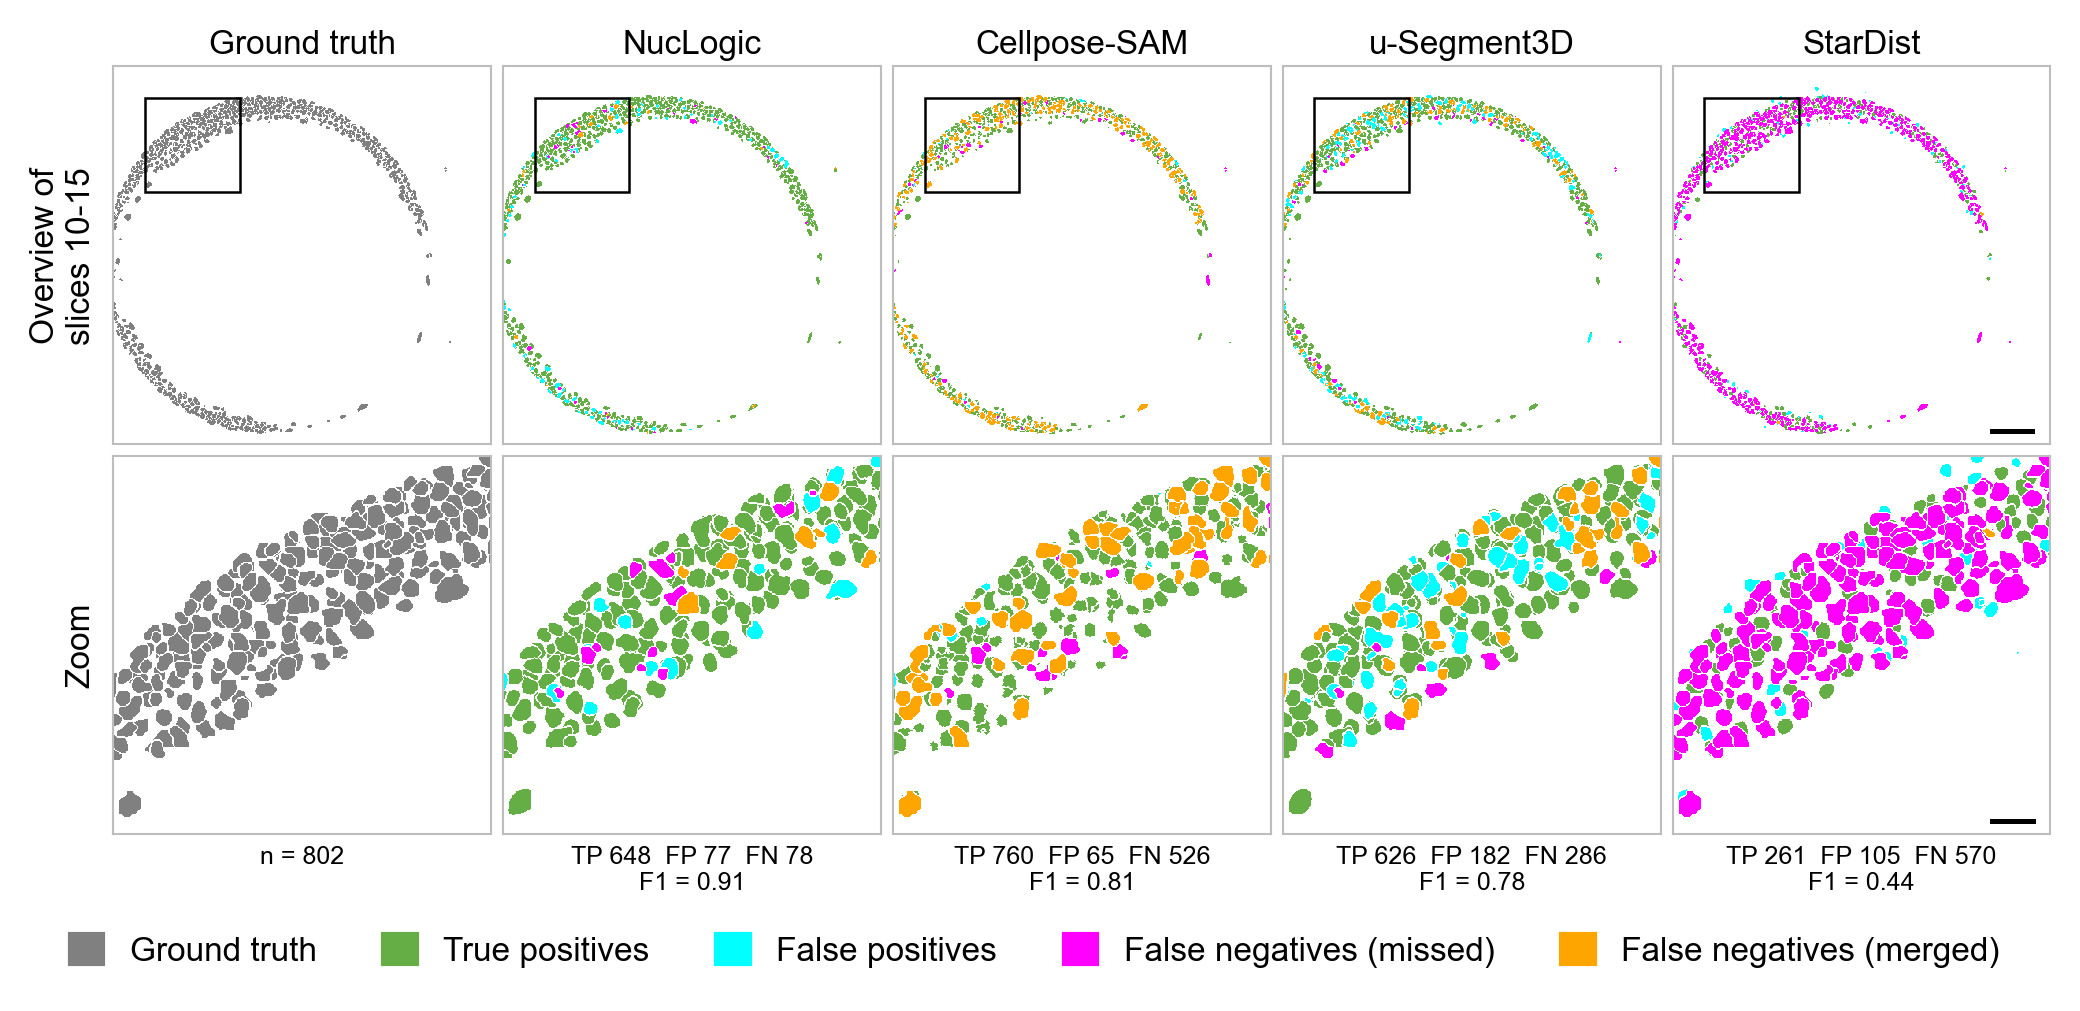

In [110]:
import os
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle, Patch
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries
from utils.centroid_accuracy import centroid_accuracy

base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
names = ["Zebrafish_1"]
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"

zoom_center = (400, 400)             # (y, x)
zoom_size   = (480, 480)             # (height, width); keep it square so panels stay equal size
pixel_size = 0.43                    # µm in XY
classification_slab = range(0, 50)   # deeper crop just for the scan
projected_slab = slice(10, 16)       # slices shown and counted (end exclusive)
window_size = 6                      # same thickness as the slab you'd show
window_starts = range(0, 50 - window_size - 5 + 1, 2)   # stop 5 slices before the crop edge

methods = {
    "NucLogic":     "3d_segmented_nuclogic.tif",
    "Cellpose-SAM": "3d_segmented_cp4.tif",
    "u-Segment3D":  "3d_segmented_usegment.tif",
    "StarDist":     "3d_segmented_stardist.tif",
}
# 0 = background, 1 = TP, 2 = FP, 3 = FN (missed), 4 = GT (GT column only), 5 = FN (merged into another prediction)
class_colors = {1: "#65ae45", 2: "cyan", 3: "magenta", 4: "#808080", 5: "orange"}
class_cmap = ListedColormap(["white"] + [class_colors[k] for k in (1, 2, 3, 4, 5)])

# figure layout, in mm
mm = 1 / 25.4
fig_width = 174
font_main, font_small = 8, 6
margin_left, margin_right = 9, 1      # room for the row labels
margin_top, margin_bottom = 5, 13     # room for the titles / for the scores + legend
panel_gap = 1


def gt_centroid_points(gt):
    """GT label -> voxel used for matching, chosen exactly as centroid_accuracy does (same regionprops order)."""
    points = []
    for prop in regionprops(gt):
        local = np.rint(prop.local_centroid).astype(int)
        local = np.clip(local, 0, np.array(prop.image.shape) - 1)
        offset = np.asarray(prop.bbox[:gt.ndim])
        if not prop.image[tuple(local)]:
            coords = np.argwhere(prop.image)
            local = coords[np.argmin(((coords - prop.local_centroid) ** 2).sum(axis=1))]
        points.append((prop.label, tuple(local + offset)))
    return points


def merged_gt_labels(mask, points):
    """GT labels whose centroid falls in a prediction already claimed by an earlier GT label (counted as FN, but not in fn_list)."""
    hit, merged = set(), []
    for label, point in points:
        pred_label = int(mask[point])
        if pred_label > 0:
            if pred_label in hit:
                merged.append(label)
            else:
                hit.add(pred_label)
    return merged


def classify(mask, gt, points):
    """TP/FP/FN/merged class per voxel plus the id of the object that owns it (pred label, or GT label for FN/merged)."""
    results = centroid_accuracy(gt, mask)
    merged_list = merged_gt_labels(mask, points)
    assert len(merged_list) == results["merged_cells"]
    print(f"  TP {results['true_positives']}, FP {results['false_positives']}, "
          f"FN {results['false_negatives']} (of which merged {results['merged_cells']}), F1 {results['f1']:.3f}")
    lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
    lut[np.asarray(results["tp_list"], dtype=int)] = 1
    lut[np.asarray(results["fp_list"], dtype=int)] = 2
    classes = lut[mask]
    ids = mask.astype(np.int64)

    gt_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
    gt_lut[np.asarray(results["fn_list"], dtype=int)] = 3
    gt_lut[np.asarray(merged_list, dtype=int)] = 5
    gt_class = gt_lut[gt]
    painted = gt_class > 0
    classes[painted] = gt_class[painted]
    ids[painted] = gt[painted].astype(np.int64) + int(mask.max()) + 1   # keep GT ids distinct from pred ids
    return classes, ids


def project(classes, ids):
    """Max projection of the class (merged > FN > FP > TP); the object id is taken from that same voxel."""
    z = classes.argmax(axis=0)[None]
    return (np.take_along_axis(classes, z, axis=0)[0],
            np.take_along_axis(ids, z, axis=0)[0])


def count_objects(classes, ids):
    """Distinct objects per class with at least one voxel in the given slab; merged GT nuclei count as FN."""
    tp, fp, missed, merged = (len(np.unique(ids[classes == k])) for k in (1, 2, 3, 5))
    fn = missed + merged
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return tp, fp, fn, merged, f1


def add_scale_bar(ax, length_um, image_width_px):
    length_px = length_um / pixel_size
    margin = 0.04 * image_width_px
    ax.add_patch(Rectangle((image_width_px - margin - length_px, ax.get_ylim()[0] - margin),
                           length_px, 0.012 * image_width_px, color="black", lw=0))


for sample in names:
    sample_directory = os.path.join(base_directory, sample)
    read = lambda f: tifffile.imread(os.path.join(sample_directory, f), key=classification_slab)

    gt = read("GroundTruth.tif")
    points = gt_centroid_points(gt)
    gt_slab = gt[projected_slab]
    projections = {"Ground truth": project((gt_slab > 0).astype(np.uint8) * 4, gt_slab)}
    slab_counts = {"Ground truth": len(np.unique(gt_slab[gt_slab > 0]))}
    window_f1 = {}
    for name, filename in methods.items():
        print(name)
        classes, ids = classify(read(filename), gt, points)
        projections[name] = project(classes[projected_slab], ids[projected_slab])
        slab_counts[name] = count_objects(classes[projected_slab], ids[projected_slab])
        window_f1[name] = [count_objects(classes[s:s + window_size], ids[s:s + window_size])[-1]
                           for s in window_starts]
        tp, fp, fn, merged, f1 = slab_counts[name]
        print(f"  slices {projected_slab.start}-{projected_slab.stop - 1}: TP {tp}, FP {fp}, "
              f"FN {fn} (of which merged {merged}), F1 {f1:.3f}")
    del gt, gt_slab, classes, ids

    # zoom window: set the centre (y, x) in pixels of the full image, and the size
    H, W = projections["Ground truth"][0].shape
    zh, zw = zoom_size
    y0 = int(np.clip(zoom_center[0] - zh // 2, 0, H - zh))   # clip so the box never leaves the image
    x0 = int(np.clip(zoom_center[1] - zw // 2, 0, W - zw))
    zoom = (slice(y0, y0 + zh), slice(x0, x0 + zw))

    plt.rcdefaults()
    plt.rcParams.update({
        "font.family": "Arial",
        "svg.fonttype": "none",    # keep text editable in Illustrator / Inkscape
        "pdf.fonttype": 42,
    })

    # square panels: height follows from the fixed width
    n_cols = len(projections)
    panel = (fig_width - margin_left - margin_right - (n_cols - 1) * panel_gap) / n_cols
    fig_height = margin_top + 2 * panel + panel_gap + margin_bottom
    fig, axes = plt.subplots(2, n_cols, figsize=(fig_width * mm, fig_height * mm), dpi=300)
    fig.subplots_adjust(
        left=margin_left / fig_width, right=1 - margin_right / fig_width,
        top=1 - margin_top / fig_height, bottom=margin_bottom / fig_height,
        wspace=panel_gap / panel, hspace=panel_gap / panel,
    )
    fig.patch.set_facecolor("white")

    for col, (name, (classes, ids)) in enumerate(projections.items()):
        for row, region in enumerate([(slice(None), slice(None)), zoom]):
            ax = axes[row, col]
            img = class_cmap(classes[region])          # RGBA
            img[find_boundaries(ids[region], mode="inner") & (classes[region] > 0)] = (1, 1, 1, 1)
            ax.imshow(img, interpolation="none")
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor("#bdbdbd")
                spine.set_linewidth(0.5)
        axes[0, col].set_title(name, fontsize=font_main, pad=3)
        axes[0, col].add_patch(Rectangle((x0, y0), zw, zh, fill=False, edgecolor="black", lw=0.6))

        # counts over the full field of the projected slices, shown under the zoom
        if name == "Ground truth":
            stats_text = f"n = {slab_counts[name]}"
        else:
            tp, fp, fn, merged, f1 = slab_counts[name]
            stats_text = f"TP {tp}  FP {fp}  FN {fn+merged}\nF1 = {f1:.2f}"
        axes[1, col].text(0.5, -0.03, stats_text, transform=axes[1, col].transAxes,
                          ha="center", va="top", fontsize=font_small, linespacing=1.2)

    axes[0, 0].set_ylabel(f"Overview of\nslices {projected_slab.start}-{projected_slab.stop - 1}", fontsize=font_main)
    axes[1, 0].set_ylabel("Zoom", fontsize=font_main)

    add_scale_bar(axes[0, -1], 100, W)    # 100 µm on the full field
    add_scale_bar(axes[1, -1], 25, zw)    # 25 µm on the zoom

    fig.legend(handles=[Patch(color=class_colors[k], label=l)
                        for k, l in [(4, "Ground truth"), (1, "True positives"), (2, "False positives"),
                                     (3, "False negatives (missed)"), (5, "False negatives (merged)")]],
               loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=5, frameon=False,
               fontsize=font_main, handlelength=1, handleheight=1, borderaxespad=0.2)

    # no bbox_inches="tight": that would crop the figure and change the 174 mm width
    for ext in ("png", "eps"):
        fig.savefig(os.path.join(output_directory, f"{sample}_tp_fp_fn_projection.{ext}"),
                    dpi=600, facecolor="white")
    plt.show()


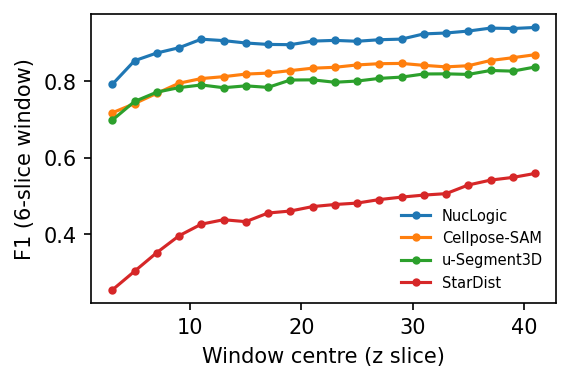

In [108]:
plt.rcdefaults()
fig, ax = plt.subplots(figsize=(4, 2.5), dpi=150)
for name, f1s in window_f1.items():
    ax.plot([s + window_size / 2 for s in window_starts], f1s, marker="o", ms=3, label=name)
ax.set_xlabel("Window centre (z slice)")
ax.set_ylabel(f"F1 ({window_size}-slice window)")
ax.legend(fontsize=7, frameon=False)
plt.show()